# DME Express — Operations Summary Dashboard

**Version v1.3.0 — 2026-08-14**

Produces, for the **company**, each **VP**, each **metro** and each **warehouse**:
technician productivity, **overtime**, **lost equipment**, redeliveries and
**stock outs** — the last three newly populated in this version.

**Changelog v1.3.0**

*Sections populated*
- **LOST EQUIPMENT — source was dead, now rebuilt.** `SERP_ACTIVE_TAGGED_INV.Lost`
  is NULL on **all 583,530 rows**, so `WHERE ATI.Lost IS NOT NULL` could never
  return anything and the panel had been structurally empty. v1.0.1's probe found
  the zero and blamed the feed, but the register had moved. Audited every
  candidate: `ATI_HISTORY` froze 2025-03-30; `SERP_LOST_EQUIPMENT_MANUAL` stops in
  2025; `Quarterly_Lost_Equipment` holds one month, one warehouse and one asset
  repeated 3,047 times. The live source is **`SERP_LOST_EQUIPMENT`** (91,023 rows,
  2025-01 → 2026-05, warehouse names matching the master 71 of 72), and it adds
  Lost Reason, Resolution, Resolved Date and Unit Cost.
  Two traps handled: `[Lost Date]` is not a date but an HTML fragment
  (`01/02/2025<br/>(147)` — `TRY_CONVERT` fails on **100%** of rows, which is how a
  naive port would silently produce the same empty panel), and `[Unit Cost]` is a
  currency string. The parse failure rate is now **asserted**, not printed.
  **The feed ends 2026-05, so every page and sheet carries a staleness banner** and
  a >45-day freshness warning: a final-month decline is missing data, not recovery.
  The **2025-08-01 bulk event (30,902 rows, $3.06M, 99.9% of it in the virtual
  buckets `Z Equipment Collections` / `Z CS`) is excluded from every metric and
  trend** per the analyst's instruction, and reported in `Lost_Bulk_Events`. New
  spikes are surveilled and warned about but never auto-excluded — a date has to be
  added to `LOST_BULK_EVENT_DATES` deliberately. `recovery_rate_pct` is computed
  only over cohorts ≥90 days old, because a raw rate falls every month by
  construction when recent losses have had no time to be found.
- **STOCK OUTS — reframed from "open backlog" to incidence + outcome + time-to-fulfil.**
  `Status='EnRoute'` is not an open backlog: 19,891 of those 21,438 orders carry a
  completion date, so rows are retained after fulfilment and v1.1.0's caveat that
  fulfilled stock-outs *"disappear from this query entirely"* was wrong. Every other
  status value is frozen at a single 2026-01-20 load, so "oldest open 1,021 days" was a
  stale row rather than an aging crisis. EnRoute by creation month is therefore **true
  incidence**.
  Orders resolve **three** ways, and the middle one is the find: **fulfilled 13,856
  (64.7%)**, **canceled/abandoned 6,035 (28.2%)** — where the only completion evidence
  sits on a *canceled* ticket — and **genuinely open 1,518 (7.1%)**, median 115 days old.
  Counting canceled tickets as deliveries inflates fulfilment by ~28 points to a false
  93%, so the three outcomes are reported separately and the open and abandoned sets get
  their own sheets: chasing an open order and explaining a dropped one are different
  jobs. Time-to-fulfil is P25 3 / median 6 / P75 9 / P90 17 days — a distribution, not a
  mean. Stock-out events are now bounded by the dashboard window like every other panel
  (27 pre-2025 orders excluded and reported).
- **STOCK OUTS — warehouse and metro pages now carry numbers.** v1.1.0 asserted no
  physical warehouse exists on stock-out rows and printed an n/a notice. It does:
  5,726 EnRoute rows carry one of 65 real warehouses, and the order join (via the new
  shared `order_wh_map`, then widened to tickets under any reason) resolves **76.0% of
  orders** to a real site.
- **OVERTIME — new section.** v1.0.0 skipped payroll on purpose; this needs it. Four
  landmines in `PLC_EMPLOYEE_HOURS`, all load-bearing:
  (a) **the feed re-loads overlapping windows, so rows accumulate** — Jun-2026 holds
  13,697 Patient-Care-Technician rows for only 5,729 distinct employee-days, one
  employee-day appearing 30 times. Un-deduplicated, inferred June OT is 77,957 hours
  on 118,747 (**66% OT**); after dedup, 7,383 on 46,694.
  (b) **the recorded OT columns are unusable** — `Reg_Hrs`/`OT1_Hrs`/`OT2_Hrs`/
  `Paid_Hrs`/`Est_*` are pay-period values repeated on every daily row (~14× daily
  `Hours`), `OT1_Hrs` is 0 for every month from 2026-02 on and `OT2_Hrs` is 0
  throughout. OT is inferred FLSA-style from daily `Hours`; a diagnostic re-proves
  this on live data every run so it is not re-litigated.
  (c) 709 rows carry NULL department/employee and 2,600–3,100 hours each (1.05M
  hours, more than every real row combined) — explicitly guarded.
  (d) the feed holds **future-dated rows** (to 2026-08-19 against an as-of of
  2026-08-13) — dropped by a half-open bound.
  **`Pay_Type` separates PTO and Holiday, so paid leave no longer inflates the
  40-hour threshold** — this retires the standing v1.34.0 caveat and is worth 18%
  (Jul-2026: 10,264 hours including leave vs 8,384 excluding). Both are emitted.
  Scope: warehouse/metro/VP panels cover Patient Care Technicians only, so overtime
  and productivity share one population; company pages add an all-departments line.
  Payroll has no usable warehouse key (**2 of 139** `Location_Name` values match the
  master), so hours reach a site through the technician name match and are then
  apportioned by ticket share — the same rule Cell 13 uses for active days.
- **NEW Cell 11.3 — `order_wh_map`**, one shared order → physical warehouse (+ VP,
  state, metro, completion date) map, used by both stock outs and lost equipment
  instead of each inventing its own attribution.
- Renderer went **2×2 → 2×3**: productivity, overtime, lost equipment,
  redeliveries, stock outs, top/bottom. Excel grows to ~42 sheets.

*Audit fixes (see `insights/code-audit-ops-dashboard-2026-08-14.md`)*
- `Redel_Unlinked_Monthly` is now actually written. Cell 11.2 has been printing
  *"exported to Redel_Unlinked_Monthly"* since v1.0.0 for a sheet that never
  existed, leaving 10,476 excluded redelivery events undocumented.
- The two conflicting redelivery denominators are unified on **attributed**
  tickets, and the column is renamed to state its basis.
- Key Vault login no longer discards the working server string — the bare hostname
  it substituted produced `[08001] TCP Provider: Timeout error [258]`;
  `tcp:{host},1433` connects first try.
- `display(df_tx.head(3))` removed: it rendered `record_id` and `order_num` into
  notebook output, against rule 2. Replaced with a shape/dtype/null summary.
- `plt.show()` now fires only for the company and VP pages. It previously ran for
  all ~85, embedding 110 figures and inflating the saved notebook to 33 MB.
- `run_query` **enforces read-only in-process** (SELECT/WITH only), which rule 4
  describes but nothing implemented.
- The H3 unparseable-date probe is windowed instead of scanning the whole table.
- `resolve_state_series`'s docstring no longer claims to be vectorized.
- Dead weight removed: `df_master`, and the unused `OUTLIER_Z_THRESH`,
  `DATA_FRESHNESS_THRESHOLD`, `MIN_HOURS_MONTH`, `STATE_PREFIX_LEN` constants plus
  the `scipy.stats` / `statsmodels` imports. `df_inventory_total` and `df_adc` were
  extracted and abandoned — they are now live as lost-equipment denominators.
  `DASH_MIN_ACTIVE_DAYS` is derived from `MIN_ACTIVE_DAYS_RANK` rather than
  duplicating the number. The Cell 0 claim that payroll and census "are
  deliberately NOT pulled" is gone — both are pulled and used.
- Still standing, deliberately: Cell 10's visit-deduplication output remains unused
  by this notebook (it is lifted from `tech_workload`, where it is used). Left in
  place rather than removed so the two notebooks stay comparable, but it is not a
  dependency of anything here.

*Known limits carried into this version*
- Lost equipment ends 2026-05; company/VP/state stock-out figures are sound while
  warehouse-level ones rest on the 76% that the order join resolves; overtime site
  rows sum to less than the company row by the unattributable payroll share; and
  `tech_workload` v1.35.0 still carries the v1.1.0 Z-warehouse exclusion and
  whole-day denominator, so it will not reconcile to this notebook until re-synced.

**Version v1.2.0 — 2026-08-14**

**Changelog v1.2.0**
- **ROOT CAUSE FOUND for the "July productivity drop": it is a measurement
  artifact, not an operations slowdown.** From 2026-06 a virtual warehouse
  (`Z CS`) began carrying ordinary completed field tickets — Additional
  Equipment (D), New Admit (D), Hospital Discharge (D), Respiratory Distress (D).
  v1.1.0's extraction filter `Tech_Warehouse NOT LIKE 'Z%'` deleted those tickets
  from the **numerator** while the technician's calendar day still counted in full
  in the **denominator**. Virtual-warehouse share of eligible weekday tickets:
  0.7% (May-2026) → 9.3% (Jun) → **24.3% (Jul)**. Company tickets per active
  tech-day, Jun→Jul: **−13.2% as reported vs −2.1% corrected**. Raw ticket volume
  actually *rose* 6.4% in July and census (ADC) hit an all-time high of 23,356 —
  there was no work slowdown.
- EXTRACTION (Cell 7.1): the blanket `Z%` exclusion is removed. Virtual-warehouse
  rows now arrive tagged (`_is_virtual_wh`, `_wh_ticket_stamped`).
- NEW Cell 8.1b — VIRTUAL WAREHOUSE RESOLUTION: re-attributes a virtual-warehouse
  ticket to the physical warehouse the same technician actually worked that
  **day**, else that **week**, else that **month**; anything left becomes
  `Virtual - Unresolved` (never silently dropped). Jul-2026 resolution: 4,019
  same-day + 1,885 same-week + 53 same-month, **2 unresolved**. Runs before the
  matcher, so state, VP, metro, redelivery linking and Excel all see a physical
  warehouse. Config-gated by `INCLUDE_VIRTUAL_WH_IN_PRODUCTIVITY` (False
  reproduces v1.1.0 exactly).
- **SECOND, INDEPENDENT DEFECT — warehouse-grain active days were double-counted.**
  A technician whose day spanned several warehouses contributed a *whole* active
  day to *each* of them while their tickets were split, deflating every site's
  ratio by the fragmentation factor. Warehouses per technician per month: 1.29
  (May-2026) → 2.22 (Jun) → **2.86 (Jul)**, so per-warehouse active-day sums ran
  **34.9% above** the honest company total in July (≈3% historically). Cell 13 now
  apportions each technician-day across warehouses by that day's ticket share
  (`active_day_equiv`), reconciling exactly to distinct (tech, date). Jun→Jul
  warehouse median: **−14.2% as reported → −4.3% corrected**; warehouses declining
  43/50 → 35/50. Config-gated by `APPORTION_TECH_DAYS`.
- NEW Cell 13.0 — ROUTING-BREAK DIAGNOSTIC (D1–D5): monthly filter funnel,
  virtual-warehouse volume by code, the mechanism with as-reported vs corrected
  ratios, warehouse-grain denominator health, and entity churn. Re-run whenever a
  series steps: it separates "the feed moved" from "operations moved". Adds four
  `Diag_*` Excel sheets.
- Rankings (Cell 17) rank on the apportioned ratio; the eligibility floor stays on
  whole active weekdays (a presence test, not a productivity one).
- Weekly panels mark `ROUTING_CHANGE_DATE` with a structural-break line and plot
  the virtual-warehouse ticket share, so future numerator leakage shows up on the
  page instead of reading as a productivity decline.
- STILL OPEN (`insights/questions-for-cfo.md`): what `Z CS` is and who owns it,
  and whether the five warehouses that went silent after Jun-2026 (R14 San Antonio
  WH 2, R14 Harlingen, Mailouts - Texas, R01 Walker, R15 T Storage) closed or were
  renamed. Until answered, treat Jun-2026-onward **warehouse-level** comparisons as
  provisional; company/VP/state levels are sound.
- Outputs stripped from this file (never committed — CLAUDE.md rule 3).

**Version v1.1.0 — 2026-08-14**

**Changelog v1.1.0**
- STOCK OUTS WIRED: `SERP_ORDER_MANAGEMENT_STOCK_OUTS`, Status='EnRoute' (source
  confirmed by owner). PII-minimized select (no patient/caregiver columns; address
  reduced to state code and dropped). Creation Date parsed Python-side (MM/DD/YYYY
  VARCHAR — locked lesson). Trend = OPEN BACKLOG by creation month (aging view),
  not historical incidence — the table is a snapshot of unfulfilled orders.
- ATTRIBUTION: company / state / VP only. Every stock-out row sits in the virtual
  warehouse 'Z Equipment Needed', so no physical warehouse/metro exists on the
  data; those pages show a notice instead of fabricated numbers. States served by
  multiple VPs are flagged shared_state and appear on each matching VP page.
- New Excel sheets: Co/State/VP_Stockout_Monthly, StockOut_Product_Backlog,
  StockOut_Aging_Detail. Renderer overlay now aligns stock-out points to the
  redelivery month axis by period (was positional).

**Version v1.0.1 — 2026-08-14**

**Changelog v1.0.1**
- FIX (live-run KeyError 'tx_metro'): Cell 15 rewritten against the FINAL redel_linked
  schema — the lifted linking cell renames tx_* columns back to plain names and drops
  the prefixed versions at its tail; v1.0.0 referenced the mid-cell names. Rates now
  key numerator and denominator on identical plain-name grains.
- NEW: ATI diagnostic probe in Cell 14 — fires only when the lost-equipment window is
  empty (as on the 2026-08-14 run) and reports whether lost-flagged rows exist at all,
  how many have unparseable Lost_Date, and the parseable date range, to separate a dead
  feed from a raw-string date-filter miss (the H3 pattern).
- Base: the user's executed v1.0.0 upload (their USER_ROOT=aenew edit preserved).

**Version v1.0.0 — 2026-08-14** | companion to `tech_workload` v1.35.0

Produces, for the **company**, each **VP**, each **metro**, and each **warehouse**:
technician productivity over time (weekly, rolling 4-week average), lost equipment
over time (monthly), redeliveries over time (monthly, with per-100-ticket rates),
stock outs over time (**pending source table — config-gated**), and disjoint
top/bottom technician lists with statistics.

**Outputs:** `OpsDashboard_Pages_{date}.pdf` (one page per entity, board reading
order: company → VPs → metros → warehouses, ~85 pages), per-VP/company PNGs, and
`OpsDashboard_Report_{date}.xlsx` (17+ sheets).

**Architecture (decided 2026-08-14):** self-contained — re-queries Azure SQL via the
Key Vault login and duplicates the v1.35.0 extraction/matching machinery. Duplicated
cells are marked LIFTED VERBATIM; when the main notebook's matching changes, re-sync
them or the two reports will diverge. _(v1.3.0: payroll and census ARE now pulled — see the v1.3.0 overtime and
lost-equipment notes above. The original v1.0.0 claim that they were deliberately
omitted no longer holds.)_

## Cell 1 — INSTALL DEPENDENCIES

In [1]:
%pip install rapidfuzz matplotlib python-dotenv pypyodbc openpyxl python-dateutil azure-identity azure-keyvault-secrets

Note: you may need to restart the kernel to use updated packages.


## Cell 2 — IMPORTS *(LIFTED VERBATIM from tech_workload v1.35.0 — re-sync if the main notebook changes)*

In [2]:
# Standard library + analysis stack. azure.identity/azure.keyvault power the Key
# Vault login in Cell 4. rapidfuzz is optional: the _RAPIDFUZZ_OK flag
# lets later cells degrade gracefully instead of crashing on import.
import os, re, time, warnings, calendar as _cal
from datetime import datetime, date, timedelta
from collections import defaultdict
from functools import reduce
from dateutil.relativedelta import relativedelta
import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import matplotlib.dates as mdates
from dotenv import load_dotenv
import pypyodbc as odbc
from azure.identity import DefaultAzureCredential
from azure.keyvault.secrets import SecretClient

try:
    from rapidfuzz.distance import DamerauLevenshtein as _DL
    _RAPIDFUZZ_OK = True
except ImportError:
    _RAPIDFUZZ_OK = False
    print('rapidfuzz not installed — falling back to pure-Python Levenshtein.')
# v1.3.0: scipy.stats and statsmodels were imported behind a _SM_OK guard and never
# called anywhere in this notebook — removed. Re-add if a model is actually fitted.
warnings.filterwarnings('ignore', category=UserWarning, module='matplotlib')
warnings.filterwarnings('ignore', category=UserWarning, module='openpyxl')
CHART_DPI = 150
matplotlib.rcParams['figure.dpi'] = CHART_DPI
print(f'pandas {pd.__version__}  |  numpy {np.__version__}  |  rapidfuzz: {_RAPIDFUZZ_OK}')

pandas 2.3.3  |  numpy 2.3.4  |  rapidfuzz: True


## Cell 3.1 — RUN WINDOW, PATHS & THRESHOLDS *(LIFTED VERBATIM from tech_workload v1.35.0 — re-sync if the main notebook changes)*

In [3]:
RUN_DATE     = datetime.now().strftime('%Y-%m-%d')
FILTER_START = '2025-01-01'
AS_OF_DATE   = datetime.now().date() - timedelta(days=1)
FILTER_END   = AS_OF_DATE.strftime('%Y-%m-%d')
print(f'AS_OF_DATE (last full day of data): {AS_OF_DATE.isoformat()}')
EXCLUDE_CURRENT_MONTH = False
if EXCLUDE_CURRENT_MONTH:
    _last = datetime.now().replace(day=1) - relativedelta(days=1)
    FILTER_END = _last.strftime('%Y-%m-%d')

USER_ROOT = '/./Users/aenew'
#USER_ROOT = '/./Users/AlexNewton'
REPORT_ROOT = f'{USER_ROOT}/OneDrive - DME Express/Reports/TechWorkload'
ENV_FILE = f'{USER_ROOT}/OneDrive - DME Express/Documents/IT/Python/MSAIKey.env'  # _LEGACY v1.35.0: login now via Key Vault (Cell 4); delete with the commented .env login after 2026-Q4
DRIVER_NAME = 'ODBC Driver 18 for SQL Server'
SERVER_NAME = 'tcp:dmeexpress.database.windows.net,1433'
DATABASE_NAME = 'DMEEXPRESS'

FUZZY_EDIT_DIST  = 1
# v1.3.0: OUTLIER_Z_THRESH, DATA_FRESHNESS_THRESHOLD and MIN_HOURS_MONTH were lifted
# from tech_workload and never read by this notebook — removed rather than left to look
# load-bearing. OT_* below DO go live in v1.3.0 (Cell 15.5).

# ── v1.33.0 (N1): Overtime configuration ────────────────────────────────────
# FLSA-style inference from PLC daily hours: any hours over OT_WEEKLY_THRESHOLD
# in a Sun–Sat workweek count as overtime. Computed on RAW per-person hours
# (before any warehouse pro-rating) because the threshold applies to the
# employee, not the warehouse. CAVEAT: if PLC 'Hours' includes PTO/holiday pay,
# OT is overstated (PTO does not count toward the 40-hr threshold). Confirm the
# feed with payroll; if an earnings-code column exists, prefer it over inference.
OT_WEEKLY_THRESHOLD = 40.0   # hours per workweek before OT begins
MIN_HOURS_FOR_OT_RATE = 80.0 # total-hours floor before a tech appears in OT-rate rankings
MIN_ACTIVE_DAYS_RANK  = 30   # active-day floor for tech top/bottom ranking (M1)
PCT_DEPT = 'Patient Care Technician'


AS_OF_DATE (last full day of data): 2026-08-13


## Cell 3.2 — ROLE CLASSIFICATION & INCLUDED REASONS *(LIFTED VERBATIM from tech_workload v1.35.0 — re-sync if the main notebook changes)*

In [4]:
# Role classification vocabularies: a matched employee whose title/dept hits the
# FIELD_TECH sets is countable workload; INTERNAL_OPS hits (dispatchers, CSRs) are
# excluded from productivity and reported separately. INCLUDED_REASONS is the
# locked ticket-reason whitelist — SQL filters on it, so adding a reason code
# upstream requires adding it here or those tickets silently never arrive.
FIELD_TECH_TITLES = {'patient care technician','service technician','lead technician','lead tech',
                     'warehouse technician','warehouse tech','warehouse manager','site manager','area manager',}
FIELD_TECH_DEPTS = {'field operations','warehouse'}
INTERNAL_OPS_TITLES = {'customer service','csr','dispatcher','dispatch','routing','call center','intake','scheduler','scheduling'}
INTERNAL_OPS_DEPTS = {'customer service','dispatch','routing','call center','intake','scheduling'}

INCLUDED_REASONS = [
    'Priority 1 - Hospital Discharge (D)',
    'Priority 1 - Respiratory Distress (D)',
    'Priority 1 - Respiratory Service/Exchange (D)',
    'Priority 1 - Respiratory Service/Exchange (P)',
    'Priority 1 - Respiratory Service/Exchange (S)',
    'Priority 1 - Service Correction (D)',
    'Priority 1 - Service Correction (P)',
    'Priority 2 - Exchange (S)',
    'Priority 2 - New Admit (D)',
    'Priority 2 - Respiratory Equipment (D)',
    'Priority 2 - Service/Exchange (D)',
    'Priority 2 - Service/Exchange (P)',
    'Priority 2 - Service/Repair (S)',
    'Priority 2 - Swap Out (Equipment Provider)',
    'Priority 3 - Additional Equipment (D)',
    'Priority 3 - Change Address (D)',
    'Priority 3 - Change Address (P)',
    'Priority 3 - Customer/Patient Request (P)',
    'Priority 3 - Exchange (S)',
    'Priority 3 - Inservice (S)',
    'Priority 3 - Live Discharge (P)',
    'Priority 3 - O2 Refill (D)',
    'Priority 3 - O2 Refill (P)',
    'Priority 3 - Patient Expired (P)',
    'Priority 3 - Respite Stay (D)',
    'Priority 3 - Respite Stay (P)',
    'Priority 3 - Service/Exchange (D)',
    'Priority 3 - Service/Exchange (P)',
    'Priority 3 - Swap Out (Equipment Provider)',
    'Split Order',
]


## Cell 3.3 — GEOGRAPHY: METROS, PALETTE, OUTPUT FOLDER *(LIFTED VERBATIM from tech_workload v1.35.0 — re-sync if the main notebook changes)*

In [5]:
METRO_GROUPS = {
    'DFW':         ['irving','garland','fort worth','txs garland'],
    'Houston':     ['houston','league city','south houston'],
    'San Antonio': ['san antonio'],
}

PALETTE = {
    'attributed'   : '#1f77b4',
    'dark_unattrib': '#d62728',
    'unmatched'    : '#ff7f0e',
    'blank'        : '#9467bd',
    'redelivery'   : '#e377c2',
    'internal_ops' : '#8c564b',
    'company_avg'  : '#000000',
}

OUT_DIR = os.path.join(REPORT_ROOT, RUN_DATE)
os.makedirs(OUT_DIR, exist_ok=True)
print(f'Output: {OUT_DIR}')
print(f'Window: {FILTER_START} -> {FILTER_END}')
print(f'Metro groups: {list(METRO_GROUPS.keys())}')

Output: /./Users/aenew/OneDrive - DME Express/Reports/TechWorkload\2026-08-14
Window: 2025-01-01 -> 2026-08-13
Metro groups: ['DFW', 'Houston', 'San Antonio']


## Cell 3.4 — WAREHOUSE → STATE OVERRIDES *(LIFTED VERBATIM from tech_workload v1.35.0 — re-sync if the main notebook changes)*

In [6]:
# ─────────────────────────────────────────────────────────────────────────────
# WAREHOUSE_STATE_OVERRIDES
# Manual state mapping for warehouses where SERP_WAREHOUSES.[State Province]
# is NULL AND no sibling warehouse (same city, different region prefix) has a
# populated state. The resolution pipeline in Cell 9 tries (1) master,
# (2) sibling-city lookup from df_hier, (3) this override map, (4) 'Unknown'.
# Add new entries here as new orphan warehouses appear.
# ─────────────────────────────────────────────────────────────────────────────

# Manual state map for warehouses whose SERP_WAREHOUSES.[State Province] is NULL
# and that have no sibling-city row to borrow from. Layer 3 of the resolution
# pipeline in Cell 9.4 — add new orphan warehouses here as they appear.
WAREHOUSE_STATE_OVERRIDES = {
    'Distribution Center - Alabama':   'AL',
    'Distribution Center - Louisiana': 'LA',
    'R03 Hot Springs':       'AR',
    'R04 Camden':            'AR',
    'R04 Fort Smith':        'AR',
    'R05 Natchez Storage':   'MS',
    'R05 Tuscaloosa':        'AL',
    'R08 Alexander City':    'AL',
    'R09 Calhoun':           'GA',
    'R10 Hunt Valley':       'MD',
    'R10 Beltsville - MD':   'MD',
    'R11 Columbia - SC':     'SC',
    'R12 Garland':           'TX',
    'R13 Akron':             'OH',
    'R14 Hendersonville':    'TN',
    'R14 Jackson, TN':       'TN',
    'R15 Chantilly - VA':    'VA',
    'R15 Fredericksburg':    'VA',
    'R16 H3S':               'TX',
    'R16 Houston':           'TX',
    'RNW Austin':            'TX',
    'RNW Garland':           'TX',
}
print(f'WAREHOUSE_STATE_OVERRIDES: {len(WAREHOUSE_STATE_OVERRIDES)} entries')

WAREHOUSE_STATE_OVERRIDES: 22 entries


## Cell 3.5 — DASHBOARD CONFIGURATION

In [7]:
# ─────────────────────────────────────────────────────────────────────────────
# DASHBOARD CONFIGURATION
# ─────────────────────────────────────────────────────────────────────────────
DASH_TOP_N          = 5      # top/bottom technicians listed per grouping
DASH_MIN_ACTIVE_DAYS = MIN_ACTIVE_DAYS_RANK  # v1.3.0: derived, not a second copy of 30
DASH_ROLL_WEEKS     = 4      # rolling window on weekly productivity

# ── v1.2.0: VIRTUAL ("Z") WAREHOUSE HANDLING ─────────────────────────────────
# 'Z%' warehouse codes are virtual/administrative holding buckets, not buildings.
# Until 2026-05 they carried only a trickle of housekeeping rows, so v1.1.0 dropped
# them in SQL. From 2026-06 'Z CS' began carrying REAL completed field tickets
# (24.3% of eligible weekday tickets by Jul-2026). Dropping them removed numerator
# while the technician's active day stayed in the denominator — that, and nothing
# operational, is the "July drop". Cell 8.1b re-attributes them. Set this False to
# reproduce v1.1.0's numbers exactly.
VIRTUAL_WH_PREFIX  = 'Z'
INCLUDE_VIRTUAL_WH_IN_PRODUCTIVITY = True
VIRTUAL_UNRESOLVED_LABEL = 'Virtual - Unresolved'   # labelled, never silently dropped
WAREHOUSE_STATE_OVERRIDES[VIRTUAL_UNRESOLVED_LABEL] = 'Unknown'  # keeps the Cell 9.4 audit quiet

# Apportion a technician's calendar day across the warehouses they worked that day,
# weighted by that day's ticket share, instead of crediting a whole active day to
# each. Without this the warehouse-grain denominator sums ~35% above the honest
# company total (Jul-2026) and every site page reads low. Company totals are
# unaffected — apportioned days reconcile exactly to distinct (tech, date).
APPORTION_TECH_DAYS = True

# Known structural break in ticket routing — marked on every weekly panel.
ROUTING_CHANGE_DATE = '2026-06-01'
RUN_ROUTING_DIAGNOSTIC = True   # Cell 13.0; costs one extra aggregate query

# ── v1.3.0: LOST EQUIPMENT ───────────────────────────────────────────────────
# SOURCE CHANGE. v1.2.0 and earlier read SERP_ACTIVE_TAGGED_INV with
# "WHERE ATI.Lost IS NOT NULL" — that column is NULL on all 583,530 rows, so the
# panel could never populate (the v1.0.1 probe found 0 rows and correctly blamed
# the feed, but the data had moved). Audited alternatives:
#   SERP_ACTIVE_TAGGED_INV.Lost ....... 0 non-null            dead column
#   SERP_ACTIVE_TAGGED_INV_HISTORY .... 537,335 rows, ends 2025-03-30   frozen
#   SERP_LOST_EQUIPMENT_MANUAL ........ 53,424 rows, ends 2025          stale
#   Quarterly_Lost_Equipment .......... 2024-06 only, 1 wh, 1 asset     abandoned
#   SERP_LOST_EQUIPMENT ............... 91,023 rows, 2025-01 -> 2026-05  LIVE  <-
# SERP_LOST_EQUIPMENT also carries Lost Reason, Resolution, Resolved Date and
# Unit Cost, and its Warehouse values match SERP_WAREHOUSES 71 of 72.
LOST_TABLE = 'SERP_LOST_EQUIPMENT'

# TRAP 1: [Lost Date] is NOT a date. Values look like '01/02/2025<br/>(147)' — an
# HTML fragment with a trailing counter — so TRY_CONVERT fails on 100% of rows. We
# strip the tail and parse in Python (locked lesson: VARCHAR dates are parsed
# Python-side, never filtered in SQL).
# TRAP 2: [Unit Cost] is a currency string ('$11.88') — clean_numbers() handles it.
LOST_DATE_TAIL_RE = r'<br\s*/?>.*$'        # strips '<br/>(147)' and anything after
LOST_DATE_FMT     = '%m/%d/%Y'

# KNOWN BULK EVENTS — excluded from every metric and trend, reported separately.
# 2025-08-01: 30,902 rows / $3.06M unit cost against a 50-185/day baseline, with
# 30,141 of them parked in 'Z Equipment Collections' and 632 in 'Z CS' — i.e. 99.9%
# in virtual buckets, not at physical sites. Confirmed by the analyst as a known
# bulk discard/reconciliation, not operational loss. Add dates here to exclude them;
# nothing is ever excluded that is not listed.
LOST_BULK_EVENT_DATES = ['2025-08-01']
LOST_SPIKE_FACTOR = 8.0    # warn when a single lost date exceeds N x the window median
LOST_STALENESS_WARN_DAYS = 45   # feed ends 2026-05: banner every page that uses it
# Recovery rate is CENSORED for recent cohorts — an asset lost last week has had no
# time to be found. Only cohorts at least this old get a recovery rate.
LOST_RECOVERY_MATURITY_DAYS = 90
LOST_RESOLUTION_RECOVERED = ['Recover no bill', 'Recover and bill']
LOST_RESOLUTION_DISCARDED = ['Discard no bill']

# ── v1.3.0: STOCK OUTS — REFRAMED FROM "OPEN BACKLOG" TO INCIDENCE ───────────
# v1.1.0 read Status='EnRoute' as the open backlog and trended it as an aging view.
# The data does not support that: 19,891 of the 21,438 'EnRoute' orders carry a
# completion date, and every other status value is frozen at a single 2026-01-20 load.
# Status simply is not maintained. So:
#   * EnRoute by creation month IS true stock-out incidence (rows are retained after
#     fulfilment — the v1.1.0 caveat that fulfilled rows "disappear" was wrong);
#   * time-to-fulfil is computable by joining [Order] to SERP TRANSACTIONS
#     (P25 3 / median 6 / P75 9 / P90 17 days);
#   * an order resolves THREE ways, not two. 6,035 of those completion dates sit only
#     on a CANCELED ticket, i.e. the order was abandoned rather than delivered, so
#     genuine fulfilment is 64.7% and NOT the 93% a naive "has a completion date"
#     test returns. Canceled/abandoned is 28.2%; the real backlog is the remaining
#     7.1% (1,518 orders, median age 115 days).
STOCKOUT_TABLE = 'SERP_ORDER_MANAGEMENT_STOCK_OUTS'
STOCKOUT_EVENT_STATUS = 'EnRoute'     # the only maintained status = the event log
STOCKOUT_FROZEN_LOAD_DATE = '2026-01-20'  # every other status stops here; reconciliation only
# Warehouse attribution: v1.1.0 claimed no physical warehouse exists on stock-out
# rows. It does — 5,726 EnRoute rows carry one of 65 real warehouses, and joining
# [Order] to the ticket feed resolves 76.0% of orders to a real site.
STOCKOUT_ATTRIBUTION_MIN_COVERAGE = 0.50   # warn if the order join resolves less than this

# ── v1.3.0: OVERTIME (PLC_EMPLOYEE_HOURS) ────────────────────────────────────
# v1.0.0 deliberately skipped payroll ("no metric here needs hours"). v1.3.0 needs it.
#
# TRAP 1 — THE FEED RE-LOADS OVERLAPPING WINDOWS, so rows accumulate. SystemUpdatedDate
# shows loads on 2026-08-11, 08-12 and 08-14 all covering WorkDate 2026-08-06..08-19.
# Jun-2026 has 13,697 PCT rows for only 5,729 distinct (employee, workday) pairs — one
# employee-day appeared 30 times. Un-deduplicated, inferred June OT is 77,957 hours on
# 118,747 total (66% OT). After dedup: 7,383 on 46,694. ALWAYS DEDUPLICATE.
PLC_TABLE = 'PLC_EMPLOYEE_HOURS'
PLC_DEDUP_KEYS = ['plc_id', 'employee_name', 'workdate', 'pay_type', 'location_name', 'hours']
#
# TRAP 2 — THE RECORDED OT COLUMNS ARE UNUSABLE. Reg_Hrs/OT1_Hrs/OT2_Hrs/Paid_Hrs/Est_*
# are pay-period values repeated on every daily row (Pay_Type='Work': Hours 958,685 vs
# Reg_Hrs 13,626,530 — ~14x), OT1_Hrs is 0 for every month from 2026-02 on, and OT2_Hrs
# is 0 everywhere. So OT is INFERRED FLSA-style from daily [Hours], as tech_workload
# v1.35.0 does. OT_WEEKLY_THRESHOLD lives in Cell 3.1.
#
# TRAP 3 — 709 rows have Department_Name/Employee_Name NULL and 2,600-3,100 hours each
# (1,051,659 hours total, more than every real row combined). Aggregate garbage rows;
# excluded by the department filter and by an explicit guard.
#
# TRAP 4 — PLC contains FUTURE-DATED rows (through 2026-08-19 vs AS_OF_DATE 2026-08-13).
# The half-open upper bound in the extract drops them.
#
# PAY TYPES: Pay_Type separates Work / On Call Hours / PTO / Holiday. Only worked time
# counts toward the 40-hour threshold — paid leave does not (FLSA). This retires the
# standing v1.34.0 caveat "if PLC Hours includes PTO, OT is overstated": Jul-2026
# inferred OT is 10,264 hours including leave vs 8,384 excluding it (18% overstated).
# The all-pay-types figure is still emitted as a reconciliation column.
OT_PAY_TYPES_WORKED = ['Work', 'On Call Hours']
OT_PAY_TYPES_LEAVE  = ['PTO', 'Holiday']
#
# SCOPE: per-technician and per-warehouse OT uses the Patient Care Technician
# population only, so it shares the exact denominator as the productivity metric and
# the ratios are comparable. Company and VP pages additionally carry an
# all-departments OT line for total labour cost.
OT_DEPTS_TECH = ['Patient Care Technician']
OT_DEPTS_ALL  = ['Patient Care Technician', 'Internal Operations', 'Dispatch',
                 'Distribution Center']
# PLC has no usable warehouse key — only 2 of 139 Location_Name values match
# SERP_WAREHOUSES ('San Antonio TX' vs 'R14 San Antonio', 'Lafayette (Scott), LA', ...).
# Hours are therefore attributed to a site through the technician name match, then
# apportioned across that technician's warehouses by ticket share — the same rule
# Cell 13 uses for active days, so OT and productivity share one attribution model.
OT_APPORTION_BY_TICKET_SHARE = True

DASH_PDF_NAME  = f'OpsDashboard_Pages_{RUN_DATE}.pdf'
DASH_XLSX_NAME = f'OpsDashboard_Report_{RUN_DATE}.xlsx'
print(f'Dashboard config loaded. Stock-outs configured: {STOCKOUT_TABLE is not None}')

Dashboard config loaded. Stock-outs configured: True


## Cell 4.1 — SECURE SQL CONNECTION: AZURE KEY VAULT

In [8]:
# load_dotenv(ENV_FILE)
# sql_conn = odbc.connect(
#    f'DRIVER={{{DRIVER_NAME}}};SERVER={SERVER_NAME};DATABASE={DATABASE_NAME};'
#    f'UID={os.getenv("SQL_USERNAME")};PWD={os.getenv("SQL_PASSWORD")};'
#    f'Encrypt=yes;TrustServerCertificate=no;Connection Timeout=30;'
#)

KEY_VAULT_URI   = 'https://dmee-keyvault.vault.azure.net/'
HOSTNAME_SECRET = 'DataWarehouseHostname'
SQL_USERNAME    = 'anewton-ro'   # secret name is the login; its value is the password

kv = SecretClient(vault_url=KEY_VAULT_URI, credential=DefaultAzureCredential())
# v1.3.0 (audit B4): the vault stores a BARE hostname. Substituting it for the
# 'tcp:host,1433' form from Cell 3.1 produced '[08001] TCP Provider: Timeout error [258]'
# on a cold connect; wrapping it connects first try. Keep the prefix and the port.
SERVER_NAME  = f'tcp:{kv.get_secret(HOSTNAME_SECRET).value},1433'
SQL_PASSWORD = kv.get_secret(SQL_USERNAME).value
print('Secrets loaded from Key Vault.')

sql_conn = odbc.connect(
    f'DRIVER={{{DRIVER_NAME}}};SERVER={SERVER_NAME};DATABASE={DATABASE_NAME};'
    f'UID={SQL_USERNAME};PWD={SQL_PASSWORD};'
    f'Encrypt=yes;TrustServerCertificate=no;Connection Timeout=30;'
)

print('DB connection established.')

Secrets loaded from Key Vault.
DB connection established.


## Cell 4.2 — QUERY RUNNER & UTILITIES

In [9]:
_READ_ONLY_STARTS = ('select', 'with')
def run_query(query, label='', verbose=False):
    """Run a READ-ONLY query and return a DataFrame.

    v1.3.0 (audit C2): CLAUDE.md rule 4 says analysis queries are SELECT/WITH only and
    that this helper enforces it in-process. It did not — it executed whatever string it
    was handed. It does now: anything that is not a single SELECT/WITH statement raises
    before touching the connection. This is a guard against an accident in a notebook
    that holds a live production connection, not a security boundary.
    """
    _q = re.sub(r'--[^\n]*', ' ', query)            # strip line comments
    _q = re.sub(r'/\*.*?\*/', ' ', _q, flags=re.S)  # strip block comments
    _q_clean = _q.strip().lstrip('(').lstrip()
    if not _q_clean.lower().startswith(_READ_ONLY_STARTS):
        raise ValueError(f'run_query is read-only: a query must begin with SELECT or WITH '
                         f'(label={label!r}, got {_q_clean[:60]!r}).')
    _forbidden = re.findall(r'(?<![\w.])(insert|update|delete|merge|drop|truncate|alter|create|'
                            r'grant|revoke|exec|execute|sp_\w+|xp_\w+)(?![\w.])', _q, flags=re.I)
    if _forbidden:
        raise ValueError(f'run_query is read-only: refusing statement containing '
                         f'{sorted(set(w.lower() for w in _forbidden))} (label={label!r}).')
    if ';' in _q_clean.rstrip().rstrip(';'):
        raise ValueError(f'run_query is read-only: one statement per call (label={label!r}).')
    if verbose: print(f'Query: {label}\n{query}')
    t0 = time.time()
    cur = sql_conn.cursor(); cur.execute(query)
    rows = cur.fetchall()
    cols = [c[0].lower() for c in cur.description]
    df   = pd.DataFrame(rows, columns=cols)
    if label: print(f'  {label}: {len(df):,} rows  ({time.time()-t0:.1f}s)')
    return df

def clean_numbers(val):
    # v1.33.0 (L2): preserve the negative sign — the old regex stripped '-', silently
    # flipping negative adjustments positive. Also avoid lstrip('0') mangling.
    if val is None: return np.nan
    s = str(val).strip()
    neg = s.startswith('-') or (s.startswith('(') and s.endswith(')'))  # (123) = accounting negative
    c = re.sub(r'[^0-9.]', '', s)
    if not c or c == '.': return np.nan
    try:
        v = float(c)
    except ValueError:
        return np.nan
    return -v if neg else v

def save_fig(fig, name):
    fig.savefig(os.path.join(OUT_DIR, f'{name}_{RUN_DATE}.png'), bbox_inches='tight', dpi=CHART_DPI)

def _strip_wh_prefix(name):
    """Strip leading region token (R##, RNW) or 'Distribution Center -' to expose
    the underlying city/location. Used by resolve_state_series() to find sibling
    warehouses for the same physical location.
    Examples:
        'R02 Lake Charles'         -> 'Lake Charles'
        'RNW Del Rio'              -> 'Del Rio'
        'Distribution Center - LA' -> 'LA'
    """
    import re as _re
    if not isinstance(name, str): return ''
    s = name.strip()
    s = _re.sub(r'^R\d{2}\s+', '', s)
    s = _re.sub(r'^RNW\s+', '', s, flags=_re.IGNORECASE)
    s = _re.sub(r'^Distribution Center\s*-\s*', '', s, flags=_re.IGNORECASE)
    return s.strip()

def assign_metro(wh_name, metro_groups=METRO_GROUPS):
    """Assign a warehouse to a metro group by substring match (case-insensitive).
    Returns the metro name, or None if no match. First match wins.
    """
    if not wh_name or not isinstance(wh_name, str): return None
    wh_lc = wh_name.lower().strip()
    for metro, patterns in metro_groups.items():
        if any(p in wh_lc for p in patterns):
            return metro
    return None

## Cell 5 — LEVENSHTEIN DISTANCE

In [10]:
# Damerau–Levenshtein edit distance for fuzzy first-name matching (Pass 4).
# rapidfuzz (C++) when installed; otherwise a pure-Python fallback with the same
# semantics, including adjacent-transposition ('jhon'→'john' = distance 1).
if _RAPIDFUZZ_OK:
    def levenshtein(a, b): return _DL.distance(a, b)
else:
    def levenshtein(a, b):
        if a==b: return 0
        if not a: return len(b)
        if not b: return len(a)
        la,lb=len(a),len(b)
        d=[[0]*(lb+1) for _ in range(la+1)]
        for i in range(la+1): d[i][0]=i
        for j in range(lb+1): d[0][j]=j
        for i in range(1,la+1):
            for j in range(1,lb+1):
                cost=0 if a[i-1]==b[j-1] else 1
                d[i][j]=min(d[i-1][j]+1,d[i][j-1]+1,d[i-1][j-1]+cost)
                if i>1 and j>1 and a[i-1]==b[j-2] and a[i-2]==b[j-1]: d[i][j]=min(d[i][j],d[i-2][j-2]+cost)
        return d[la][lb]
print('levenshtein() ready.')

levenshtein() ready.


## Cell 6 — NICKNAME DICTIONARY

In [11]:
# Bidirectional nickname dictionary (Pass 3): 'mike'→Michael AND Michael→'mike'.
# Includes Spanish hypocorisms (pepe/chuy/beto...) for the field workforce.
# Retained as-is by explicit decision — do not prune without a match-rate test.
NICKNAME_TO_CANONICAL_RAW = [
    ('chris',['Christopher','Christian','Christina','Christine']),('kris',['Christopher','Kristopher']),
    ('mike',['Michael']),('mikey',['Michael']),('matt',['Matthew']),('dan',['Daniel']),('danny',['Daniel']),
    ('dave',['David']),('rob',['Robert']),('bob',['Robert']),('bobby',['Robert']),('robbie',['Robert']),
    ('robby',['Robert']),('jim',['James']),('jimmy',['James']),('jamie',['James']),('joe',['Joseph']),
    ('joey',['Joseph']),('tom',['Thomas']),('tommy',['Thomas']),('bill',['William']),('billy',['William']),
    ('will',['William']),('liam',['William']),('rick',['Richard','Ricardo','Frederick']),
    ('ricky',['Richard','Ricardo']),('rich',['Richard']),('steve',['Steven','Stephen']),
    ('ed',['Edward','Eduardo','Edwin']),('eddie',['Edward','Eduardo']),('ted',['Edward','Theodore']),
    ('tony',['Anthony','Antonio']),('nick',['Nicholas','Nicolas']),('pat',['Patrick','Patricia']),
    ('tim',['Timothy']),('timmy',['Timothy']),('jon',['Jonathan','Jonathon']),
    ('johnny',['John','Jonathan']),('jack',['John','Jackson']),('jeff',['Jeffrey','Geoffrey']),
    ('andy',['Andrew','Andres']),('drew',['Andrew']),('ron',['Ronald','Ronaldo']),
    ('ronnie',['Ronald']),('ken',['Kenneth']),('kenny',['Kenneth']),('ben',['Benjamin']),
    ('benny',['Benjamin','Benito']),('greg',['Gregory']),('sam',['Samuel','Samantha']),
    ('josh',['Joshua']),('alex',['Alexander','Alejandro','Alexandra']),
    ('nate',['Nathaniel','Nathan']),('zach',['Zachary','Zachariah']),('zack',['Zachary']),
    ('mitch',['Mitchell']),('ray',['Raymond','Raymundo']),('larry',['Lawrence','Lorenzo']),
    ('terry',['Terrence','Terrell']),('jerry',['Gerald','Jeremiah','Jerome']),
    ('chuck',['Charles']),('charlie',['Charles']),('fred',['Frederick','Fredrick','Alfredo']),
    ('hank',['Henry']),('harry',['Henry','Harold','Harrison']),('phil',['Philip','Phillip']),
    ('wes',['Wesley']),('vince',['Vincent']),('vinny',['Vincent','Vincenzo']),
    ('abe',['Abraham']),('gabe',['Gabriel']),('len',['Leonard']),('walt',['Walter']),
    ('doug',['Douglas']),('al',['Albert','Alan','Alfonso']),('bert',['Albert','Robert','Herbert']),
    ('don',['Donald']),('gene',['Eugene']),('manny',['Manuel','Emmanuel']),('marty',['Martin']),
    ('art',['Arthur']),('curt',['Curtis']),('ernie',['Ernest','Ernesto']),
    ('frank',['Franklin','Francisco','Francis']),('frankie',['Franklin','Francisco','Frank']),
    ('jr',['Junior']),('lupe',['Guadalupe']),('max',['Maximilian','Maxwell','Maximo']),
    ('reggie',['Reginald']),('rudy',['Rudolph','Rodolfo']),
    ('ty',['Tyler','Tyrone','Tyson']),('vic',['Victor']),
    ('liz',['Elizabeth']),('beth',['Elizabeth']),('lisa',['Elizabeth']),
    ('kate',['Katherine','Kathryn','Kaitlyn']),('kathy',['Katherine','Kathryn']),
    ('katie',['Katherine']),('sue',['Susan','Suzanne']),('susie',['Susan']),
    ('jen',['Jennifer']),('jenny',['Jennifer']),('jenn',['Jennifer']),('amy',['Amelia','Amy']),
    ('meg',['Megan','Margaret']),('maggie',['Margaret']),('pam',['Pamela']),('barb',['Barbara']),
    ('deb',['Deborah','Debra']),('debbie',['Deborah','Debra']),('carol',['Caroline','Carolyn']),
    ('tina',['Christina']),('sandy',['Sandra','Alexandra']),('cindy',['Cynthia']),
    ('angie',['Angela','Angelica']),('ang',['Angela']),('steph',['Stephanie']),
    ('stacy',['Stacey','Stacy']),('nikki',['Nicole','Nichole']),('mia',['Maria']),
    ('maria',['Maria','Marie']),('anna',['Annette','Annalisa']),
    ('nicky',['Nichole','Nicole']),('joanie',['Joan']),('diana',['Diane']),('dani',['Danielle']),
    ('trish',['Patricia']),('patty',['Patricia']),('bri',['Brianna','Brittany']),
    ('brit',['Brittany','Britney']),('chrissy',['Christina','Christine']),('vero',['Veronica']),
    ('cass',['Cassandra']),('dot',['Dorothy']),('bev',['Beverly']),
    ('mel',['Melanie','Melissa','Melinda']),('missy',['Melissa']),('mindy',['Melinda']),
    ('pepe',['Jose']),('chuy',['Jesus']),('nacho',['Ignacio']),('chava',['Salvador']),
    ('memo',['Guillermo']),('beto',['Roberto','Alberto']),('pancho',['Francisco']),
    ('paco',['Francisco']),('chela',['Graciela']),('chucho',['Jesus']),('vale',['Valeria']),
    ('lalo',['Eduardo']),('pipe',['Felipe']),('nico',['Nicolas']),
]
NICKNAME_TO_CANONICAL = {}
for nick,canonicals in NICKNAME_TO_CANONICAL_RAW:
    if nick not in NICKNAME_TO_CANONICAL: NICKNAME_TO_CANONICAL[nick]=[]
    for c in canonicals:
        if c not in NICKNAME_TO_CANONICAL[nick]: NICKNAME_TO_CANONICAL[nick].append(c)
CANONICAL_TO_NICKNAMES = defaultdict(list)
for nick,canonicals in NICKNAME_TO_CANONICAL.items():
    for canon in canonicals: CANONICAL_TO_NICKNAMES[canon.lower()].append(nick)

def standardize_first_name(raw):
    if not raw or not isinstance(raw,str): return []
    raw_lc=raw.lower().strip(); seen,results=set(),[raw]; seen.add(raw_lc)
    for cand in NICKNAME_TO_CANONICAL.get(raw_lc,[]):
        if cand.lower() not in seen: results.append(cand); seen.add(cand.lower())
    for nick in CANONICAL_TO_NICKNAMES.get(raw_lc,[]):
        if nick.lower() not in seen: results.append(nick.title()); seen.add(nick.lower())
    return results
print(f'Nickname map: {len(NICKNAME_TO_CANONICAL)} entries')

Nickname map: 152 entries


## Cell 7.1 — TRANSACTIONS EXTRACT + H3 PROBE

In [12]:
print(f'Extracting data ({FILTER_START} to {FILTER_END})...')
t0 = time.time()
_reasons_sql = ',\n      '.join(f"'{r}'" for r in INCLUDED_REASONS)

df_tx = run_query(f"""
SELECT TRIM(TX.Order_Num) AS order_num, TRIM(TX.Record_ID) AS record_id,
    TRIM(ISNULL(TX.Tech_Warehouse,'')) AS tech_warehouse,
    TRIM(ISNULL(TX.TechFirstName,'')) AS techfirstname,
    TRIM(ISNULL(TX.TechLastName,''))  AS techlastname,
    TX.Reason AS reason,
    TRY_CONVERT(DATE, TX.Completed_Date) AS completed_date
FROM dbo.[SERP TRANSACTIONS] AS TX WITH (NOLOCK)
-- v1.2.0: the blanket "NOT LIKE 'Z%'" exclusion is GONE. From 2026-06 the virtual
  -- warehouse 'Z CS' carries real completed field tickets; excluding them here deleted
  -- up to 24% of the numerator while the technician's active day stayed in the
  -- denominator, which is the whole of the apparent July productivity cliff. Virtual
  -- rows now arrive tagged and are re-attributed to a physical warehouse in Cell 8.1b.
WHERE TX.[Status] <> 'Canceled'
  AND TX.Order_Num <> ''
  -- v1.33.0 (H3): filter on the CONVERTED date, matching the SELECT. The raw-string
  -- compare could (a) drop the entire last day if values carry a time component
  -- ('2026-07-30 14:22' > '2026-07-30' as strings) and (b) admit malformed strings
  -- that TRY_CONVERT NULLs in the SELECT, creating NaT rows downstream.
  AND TRY_CONVERT(DATE, TX.Completed_Date) >= '{FILTER_START}'
  AND TRY_CONVERT(DATE, TX.Completed_Date) <= '{FILTER_END}'
  AND TX.Reason IN ({_reasons_sql})
OPTION (RECOMPILE, MAXDOP 4)
""", 'Transactions')
# v1.3.0 (audit C1): the previous display(df_tx.head(3)) rendered record_id and
# order_num — record/account-level patient references — into committed notebook output,
# against CLAUDE.md rule 2. A shape/null summary answers the same question ("did the
# extract work?") without putting a single patient reference on screen.
print(f'  df_tx: {len(df_tx):,} rows x {df_tx.shape[1]} cols')
print('  nulls by column: ' + ', '.join(f'{c}={int(n)}' for c, n in df_tx.isna().sum().items() if n))
print(f"  completed_date range: {df_tx['completed_date'].min()} -> {df_tx['completed_date'].max()}")

# v1.3.0 (audit D6): windowed. Unparseable rows have no usable date, so they cannot be
# filtered by Completed_Date — the raw string is bounded instead, which lets the engine
# seek rather than scan the whole table for one number on every run.
_h3 = run_query(f"""
SELECT COUNT(*) AS bad_rows FROM dbo.[SERP TRANSACTIONS] WITH (NOLOCK)
WHERE TRY_CONVERT(DATE, Completed_Date) IS NULL
  AND Completed_Date IS NOT NULL AND LTRIM(RTRIM(Completed_Date)) <> ''
  AND [Status] <> 'Canceled' AND Order_Num <> ''
  AND LEFT(LTRIM(Completed_Date), 4) >= '{FILTER_START[:4]}'
""", 'H3 unparseable Completed_Date probe (windowed by raw year)')
_h3_n = int(_h3.iloc[0, 0]) if len(_h3) else 0
if _h3_n > 0:
    print(f'  *** H3: {_h3_n:,} transaction rows have UNPARSEABLE Completed_Date and are')
    print(f'      EXCLUDED from all analytics. Pull samples and fix the upstream feed.')
else:
    print('  H3 probe: 0 unparseable Completed_Date rows — verification item closed for this run.')


Extracting data (2025-01-01 to 2026-08-13)...
  Transactions: 466,560 rows  (45.6s)
  df_tx: 466,560 rows x 7 cols
  nulls by column: 
  completed_date range: 2025-01-01 -> 2026-08-13
  H3 unparseable Completed_Date probe (windowed by raw year): 1 rows  (14.6s)
  H3 probe: 0 unparseable Completed_Date rows — verification item closed for this run.


## Cell 7.2 — EMPLOYEES & WAREHOUSE HIERARCHY

In [13]:
df_emp = run_query("""
SELECT count(id) AS emp_duplicate_count,
    TRIM([FirstName]) AS empfirstname, TRIM([LastName]) AS emplastname,
    TRIM([Warehouse Name]) AS [location],
    MAX([Department Name]) AS dept, MAX([Job Title]) AS title,
    MAX([Employee Number]) AS eid, MAX([Username]) AS username
FROM SERP_DME_EMPLOYEES
GROUP BY TRIM([FirstName]),TRIM([LastName]),TRIM([Warehouse Name])
""", 'Employees')

df_hier = run_query("""
SELECT DISTINCT TRIM([Warehouse Name]) AS warehouse, [State Province] as [State],
    LEFT(TRIM([Warehouse Name]),3) AS region, TRIM([Group]) AS vp
FROM SERP_WAREHOUSES WITH (NOLOCK)
""", 'Warehouse hierarchy')


  Employees: 2,003 rows  (0.1s)
  Warehouse hierarchy: 138 rows  (0.0s)


## Cell 7.3 — REDELIVERIES EXTRACT

In [14]:
df_redel = run_query(f"""
SELECT TRIM(RD.Orig_Order) AS orig_order_num,
    TRY_CONVERT(DATE,RD.Completion_DateTime) AS rd_date,
    RD.Completion_DateTime AS rd_datetime_raw,
    TRIM(RD.Products) AS rd_products,
    TRIM(ISNULL(SE.[FirstName],'')) AS techfirstname,
    TRIM(ISNULL(SE.[LastName],''))  AS techlastname,
    TRIM(ISNULL(RD.Tech_Warehouse,'')) AS tech_warehouse
FROM dbo.[Re-Delivery Report] RD
LEFT JOIN dbo.SERP_DME_EMPLOYEES SE ON SE.Username=RD.Tech
WHERE (TRY_CONVERT(DATE,RD.Completion_DateTime) BETWEEN '{FILTER_START}' AND '{FILTER_END}')
   OR (TRY_CONVERT(DATE,RD.Completion_DateTime) IS NULL
       AND RD.Completion_DateTime LIKE '202_-%')  -- keep parse-fail rows that look in-range
""", 'Redeliveries')
if 'tech_warehouse' not in df_redel.columns: df_redel['tech_warehouse']=''


  Redeliveries: 187,737 rows  (7.2s)


## Cell 7.4 — LOST EQUIPMENT & INVENTORY EXTRACT *(source replaced in v1.3.0)*

In [15]:
# ─────────────────────────────────────────────────────────────────────────────
# LOST EQUIPMENT & INVENTORY EXTRACT                            rewritten v1.3.0
#
# v1.2.0 and earlier queried SERP_ACTIVE_TAGGED_INV WHERE ATI.Lost IS NOT NULL.
# That column is NULL on all 583,530 rows, so the panel was structurally empty and
# had been since at least 2025-01. The live register is SERP_LOST_EQUIPMENT (see the
# source audit in Cell 3.5). The old ATI probe is gone with the old query.
#
# PII DISCIPLINE (CLAUDE.md rule 2): SERP_LOST_EQUIPMENT carries Patient Firstname /
# Lastname / Patient ID, Bill-To ID, Caregiver names, WorkPhone, MobilePhone, Email,
# Ship-To Address1/2, City and Postal. NONE of them are selected. Only [Ship-To State]
# is taken, as a geographic fallback for state attribution. v1.2.0's ATI query pulled
# Bill_to_ID to count distinct patients — that was an account number under rule 2, the
# count was never used on a page, and it is not carried forward.
# ─────────────────────────────────────────────────────────────────────────────
df_lost_raw = run_query(f"""
SELECT LE.[Lost Date]         AS lost_date_raw,
       LE.[Lost Reason]       AS lost_reason,
       LE.[Warehouse]         AS lost_warehouse,
       LE.[Product Name]      AS product_name,
       LE.[Product ID]        AS product_id,
       LE.[Asset Tag]         AS asset_tag,
       LE.[Unit Cost]         AS unit_cost_raw,
       LE.[Resolution]        AS resolution,
       LE.[Resolved Date]     AS resolved_date_raw,
       LE.[Discharged Days]   AS discharged_days_raw,
       LE.[Delivery Order ID] AS delivery_order_id,
       LE.[Pickup Order ID]   AS pickup_order_id,
       LE.[Reason for Pickup] AS reason_for_pickup,
       LE.[Ship-To State]     AS ship_to_state
FROM {LOST_TABLE} AS LE WITH (NOLOCK)
""", 'Lost equipment (SERP_LOST_EQUIPMENT)')

# Inventory denominator — v1.2.0 extracted, cast and then never used this frame.
# v1.3.0 consumes it: lost assets as a share of tagged inventory on hand, which is the
# only way a 40-asset month at a small site and a 40-asset month at a large one can be
# compared. Counts are a CURRENT snapshot, so the ratio is "lost that month against
# inventory today" — fine for relative site comparison, not a point-in-time rate.
df_inventory_total = run_query("""
SELECT TRIM(WH.[Warehouse Name]) AS tech_warehouse,
    COUNT_BIG(ATI.Asset_Tag) AS total_inventory_count,
    SUM(CONVERT(float, COALESCE(ATI.Unit_Cost, MP.Unit_Cost_Last_Price))) AS total_inventory_amount
FROM SERP_ACTIVE_TAGGED_INV ATI WITH (NOLOCK)
JOIN SERP_WAREHOUSES WH WITH (NOLOCK) ON WH.ID=ATI.Warehouse_ID
LEFT OUTER JOIN SERP_MASTER_PRODUCTS MP ON MP.ID=ATI.Master_ID
WHERE WH.[Warehouse Name] NOT LIKE 'Z%' AND MP.Active='Yes' AND MP.Asset_Tag_Not_Required = 'No'
GROUP BY TRIM(WH.[Warehouse Name])
""", 'Inventory totals')
df_inventory_total['total_inventory_count'] = pd.to_numeric(df_inventory_total['total_inventory_count'], errors='coerce').fillna(0).astype(int)
df_inventory_total['total_inventory_amount'] = pd.to_numeric(df_inventory_total['total_inventory_amount'], errors='coerce').fillna(0).astype(float)

# v1.3.0: df_master (product-name lookup) dropped — SERP_LOST_EQUIPMENT carries
# Product Name directly, and the frame was extracted and never read.
print(f'All queries complete in {time.time()-t0:.1f}s')


  Lost equipment (SERP_LOST_EQUIPMENT): 91,023 rows  (1.2s)
  Inventory totals: 85 rows  (0.4s)
All queries complete in 69.3s


## Cell 7.5 — PATIENT CENSUS (APC/ADC)
lost-equipment  merges monthly ADC as a census denominator for lost-rate context.

In [16]:
df_apc_snapshot_query = f"""
SELECT TOP 1 [date] FROM SERP_APC_DAILY
WHERE [date] <= '{FILTER_END}'
ORDER BY [date] DESC
"""
_apc_snap_df = run_query(df_apc_snapshot_query, 'APC snapshot-date probe')
if len(_apc_snap_df)==0 or pd.isna(_apc_snap_df.iloc[0,0]):
    raise RuntimeError(f'APC: no rows on or before {FILTER_END}. Cannot compute snapshot.')
_apc_snap_date = pd.to_datetime(_apc_snap_df.iloc[0,0]).date()
_apc_lag_days = (AS_OF_DATE - _apc_snap_date).days
print(f'  APC snapshot date: {_apc_snap_date.isoformat()} (lag: {_apc_lag_days} day(s) behind AS_OF_DATE)')
if _apc_lag_days > 7:
    print(f'  *** WARNING: APC feed is >7 days stale. Lost-cost-per-ADC metrics may be unreliable.')
df_apc = run_query(f"""
SELECT TRIM(APC.warehourse) AS warehouse, SUM(APC.total) AS apc
FROM SERP_APC_DAILY AS APC WITH (NOLOCK)
WHERE APC.[date] = '{_apc_snap_date.isoformat()}'
  AND APC.warehourse NOT LIKE 'Z%'
  AND APC.customer NOT LIKE '(F)%' AND APC.customer NOT LIKE '(IPU)%'
  AND APC.customer NOT LIKE '%Contract Test%'
GROUP BY TRIM(APC.warehourse)
""", 'APC')
df_apc['apc'] = df_apc['apc'].apply(clean_numbers)

df_adc = run_query(f"""
WITH daily AS (SELECT [date],warehourse,SUM(total) AS APC FROM SERP_APC_DAILY
    WHERE [date]>='{FILTER_START}' AND [date]<='{FILTER_END}' AND warehourse NOT LIKE 'Z%' GROUP BY [date],warehourse)  -- v1.30.4
SELECT TRIM(warehourse) AS warehouse,AVG(APC) AS ADC,SUM(APC) AS pt_days,
    YEAR([date]) AS yr,MONTH([date]) AS mo
FROM daily GROUP BY YEAR([date]),MONTH([date]),warehourse ORDER BY yr,mo,warehourse
""", 'ADC')
df_adc[['yr','mo']] = df_adc[['yr','mo']].astype(int)
df_adc['adc']     = df_adc['adc'].apply(clean_numbers)
df_adc['pt_days'] = df_adc['pt_days'].apply(clean_numbers)


  APC snapshot-date probe: 1 rows  (0.4s)
  APC snapshot date: 2026-08-13 (lag: 0 day(s) behind AS_OF_DATE)
  APC: 63 rows  (0.2s)
  ADC: 1,219 rows  (0.4s)


## Cell 7.6 — PAYROLL HOURS (PLC) EXTRACT + DEDUPLICATION *(new in v1.3.0)*

In [17]:
# ─────────────────────────────────────────────────────────────────────────────
# PAYROLL HOURS (PLC) EXTRACT + DEDUPLICATION                        new v1.3.0
#
# v1.0.0 skipped payroll on purpose ("no metric here needs hours"). The overtime
# section needs it. Three guards are load-bearing — see Cell 3.5 for the evidence:
#   1. Department_Name IS NOT NULL      — 709 aggregate rows carry 2,600-3,100 hours
#                                        each (1.05M hours, more than all real rows).
#   2. WorkDate < AS_OF_DATE + 1 day    — the feed holds FUTURE-dated rows (to
#                                        2026-08-19 against an AS_OF of 2026-08-13).
#   3. de-duplication, below            — the feed re-loads overlapping windows.
#
# Only [Hours] is trusted. Reg_Hrs / OT1_Hrs / OT2_Hrs / Paid_Hrs / Est_* are pulled
# ONLY so the diagnostic can show why they are unusable; no metric reads them.
#
# TEACHING NOTE — why the half-open upper bound: WorkDate is typed DATE here, so
# 'WorkDate <= FILTER_END' would be safe, but the half-open form survives the column
# becoming DATETIME upstream (a plain <= would then silently drop the final day's
# intra-day rows). Same reasoning as the H3 fix on Completed_Date.
# ─────────────────────────────────────────────────────────────────────────────
_ot_depts_sql = ','.join(f"'{d}'" for d in OT_DEPTS_ALL)
df_hours_raw = run_query(f"""
SELECT TRIM(ISNULL(P.ID,''))            AS plc_id,
       P.Employee_Name                  AS employee_name,
       CAST(P.WorkDate AS DATE)         AS workdate,
       CAST(P.[Hours] AS FLOAT)         AS hours,
       ISNULL(P.Pay_Type,'(blank)')     AS pay_type,
       P.Department_Name                AS dept,
       ISNULL(P.Location_Name,'')       AS location_name,
       CAST(P.SystemUpdatedDate AS DATE) AS sys_updated,
       -- diagnostic only: proven unusable, never summed into a metric
       CAST(ISNULL(P.Reg_Hrs,0) AS FLOAT) AS reg_hrs_unusable,
       CAST(ISNULL(P.OT1_Hrs,0) AS FLOAT) AS ot1_hrs_unusable,
       -- deterministic day-of-week, immune to @@DATEFIRST. 1900-01-01 was a Monday,
       -- so this is Monday=0 .. Saturday=5, Sunday=6 (lifted from tech_workload L3).
       (DATEDIFF(day, '1900-01-01', CAST(P.WorkDate AS DATE)) % 7) AS dow_mon0
FROM {PLC_TABLE} AS P WITH (NOLOCK)
WHERE P.Department_Name IN ({_ot_depts_sql})
  AND P.Employee_Name IS NOT NULL
  AND P.WorkDate >= '{FILTER_START}'
  AND P.WorkDate < DATEADD(day, 1, '{FILTER_END}')
""", 'Payroll hours (PLC)')

_plc_rows_raw = len(df_hours_raw)
df_hours_raw['hours'] = pd.to_numeric(df_hours_raw['hours'], errors='coerce').fillna(0.0)
df_hours_raw['workdate'] = pd.to_datetime(df_hours_raw['workdate'], errors='coerce')
df_hours_raw = df_hours_raw[df_hours_raw['workdate'].notna()].copy()

# ── DEDUPLICATION ────────────────────────────────────────────────────────────
# The feed appends re-loaded windows rather than replacing them, so an employee-day
# can appear many times (worst observed: 30 copies of 2026-06-22). Dropping exact
# duplicates on the full business tuple is the conservative fix: it cannot merge two
# genuinely different entries, because any difference in id, pay type, location or
# hours keeps both rows. The only thing it can lose is a genuine duplicate — two
# byte-identical rows that were both real — which payroll does not produce.
_dupe_mask = df_hours_raw.duplicated(subset=PLC_DEDUP_KEYS, keep='first')
_n_dupes = int(_dupe_mask.sum())
df_hours_raw = df_hours_raw[~_dupe_mask].copy()
print(f'  PLC de-duplication: {_n_dupes:,} duplicate rows dropped '
      f'({_n_dupes / max(_plc_rows_raw, 1) * 100:.1f}% of {_plc_rows_raw:,}) -> {len(df_hours_raw):,} kept')

# Cross-check against the alternative rule "keep only the newest load per employee-day"
# — if the two disagree materially, the feed is doing something we do not understand yet.
_latest = (df_hours_raw.groupby(['employee_name', 'workdate'])['sys_updated'].transform('max'))
_alt_hours = float(df_hours_raw.loc[df_hours_raw['sys_updated'].eq(_latest), 'hours'].sum())
_kept_hours = float(df_hours_raw['hours'].sum())
print(f'  Hours after dedup: {_kept_hours:,.0f}  |  newest-load-only alternative: '
      f'{_alt_hours:,.0f}  (delta {(_alt_hours / max(_kept_hours, 1) - 1) * 100:+.1f}%)')
if abs(_alt_hours / max(_kept_hours, 1) - 1) > 0.05:
    print('  *** NOTE: the two de-duplication rules differ by >5%. Rows within a single '
          'load may already be duplicated, or a load may revise hours rather than repeat '
          'them. Confirm with payroll before publishing OT dollars.')

_dup_by_month = (df_hours_raw.assign(_p=df_hours_raw['workdate'].dt.strftime('%Y-%m'))
                 .groupby('_p').agg(rows=('hours', 'size'), hours=('hours', 'sum'),
                                    employees=('employee_name', 'nunique')))
print('\nPLC hours by month after de-duplication (all departments in scope):')
print(_dup_by_month.round(0).to_string())
print(f"\nDepartments pulled: {sorted(df_hours_raw['dept'].dropna().unique().tolist())}")
print(f"Pay types present:  {sorted(df_hours_raw['pay_type'].dropna().unique().tolist())}")


  Payroll hours (PLC): 123,260 rows  (0.9s)
  PLC de-duplication: 15,299 duplicate rows dropped (12.4% of 123,260) -> 107,961 kept
  Hours after dedup: 915,191  |  newest-load-only alternative: 914,544  (delta -0.1%)

PLC hours by month after de-duplication (all departments in scope):
         rows    hours  employees
_p                               
2025-01  4480  37611.0        185
2025-02  4034  33857.0        187
2025-03  4426  36532.0        188
2025-04  4503  37182.0        191
2025-05  4818  39856.0        201
2025-06  4741  39390.0        208
2025-07  5301  44333.0        225
2025-08  5313  44436.0        230
2025-09  5767  48192.0        251
2025-10  6256  52619.0        265
2025-11  6213  51495.0        283
2025-12  7077  59920.0        294
2026-01  7129  60296.0        307
2026-02  6409  55278.0        305
2026-03  5406  45997.0        319
2026-04  5493  47530.0        261
2026-05  6017  51963.0        276
2026-06  5962  53161.0        299
2026-07  6907  61024.0        312


## Cell 8.1 — DATES, NaT GUARD, SCHEDULE PERIOD & METRO

In [18]:
df_tx['completed_date'] = pd.to_datetime(df_tx['completed_date'],errors='coerce')
# v1.33.0 (H3): NaT guard. With the WHERE now on TRY_CONVERT this should be zero;
# if it isn't, rows were admitted that can't be dated and would silently form
# NaN month groups (or crash later int casts). Fail loudly, drop, and report.
_n_nat = int(df_tx['completed_date'].isna().sum())
if _n_nat > 0:
    print(f'*** WARNING: {_n_nat:,} transaction rows have unparseable Completed_Date — DROPPED.')
    df_tx = df_tx[df_tx['completed_date'].notna()].copy()
df_tx['delivery_year']  = df_tx['completed_date'].dt.year
df_tx['delivery_month'] = df_tx['completed_date'].dt.month
df_tx['month_date']     = df_tx['completed_date'].values.astype('datetime64[M]')
_dow = df_tx['completed_date'].dt.dayofweek
df_tx['schedule_period'] = np.select([_dow==5,_dow==6],['Saturday','Sunday'],default='Weekday')
df_tx['metro'] = df_tx['tech_warehouse'].apply(assign_metro)


## Cell 8.1b — VIRTUAL ("Z") WAREHOUSE RESOLUTION *(new in v1.2.0)*
Re-attributes virtual-warehouse tickets to the physical warehouse the technician
actually worked, so real field work stops vanishing out of the numerator.

In [19]:
# ─────────────────────────────────────────────────────────────────────────────
# VIRTUAL ("Z") WAREHOUSE RESOLUTION                                    v1.2.0
#
# WHY THIS CELL EXISTS. 'Z%' warehouse codes are virtual holding buckets, not
# buildings. v1.1.0 dropped them in SQL, which was harmless while they carried
# only housekeeping rows (1-2% of tickets through 2026-05). From 2026-06 'Z CS'
# began carrying ordinary completed field work — Additional Equipment (D), New
# Admit (D), Hospital Discharge (D), Respiratory Distress (D) — reaching 24.3% of
# eligible weekday tickets in Jul-2026. The tickets were deleted but the
# technician's active DAY was not, so tickets-per-active-day fell 13.2% company
# wide in July while real volume rose. This cell puts the work back.
#
# RESOLUTION LADDER (most-specific evidence first — a technician's other tickets
# that day are the strongest evidence of where they physically worked):
#   1. same_day   — modal non-virtual warehouse for that technician, that date
#   2. same_week  — modal non-virtual warehouse for that technician, that week
#   3. same_month — modal non-virtual warehouse for that technician, that month
#   4. VIRTUAL_UNRESOLVED_LABEL — kept and labelled, never silently dropped
# Ties break alphabetically, so assignment is deterministic across runs.
#
# TEACHING NOTE — why modal-from-tickets rather than the employee roster's home
# warehouse: SERP_DME_EMPLOYEES is a CURRENT snapshot, so it would back-date
# today's assignment onto last year's tickets. The technician's own same-day route
# is contemporaneous evidence and needs no join. Running here — before the matcher
# in Cell 9.3 — also means the warehouse-dependent match passes (P4-P7) see a real
# warehouse instead of 'Z CS', which no employee record will ever match.
#
# CAVEAT to repeat in any output that uses this: a resolved warehouse is INFERRED,
# not stamped on the ticket. It is sound for site-level trend and workload; it is
# not evidence about an individual without ticket-level review.
# ─────────────────────────────────────────────────────────────────────────────
_wh_raw = df_tx['tech_warehouse'].fillna('').astype(str).str.strip()
df_tx['_wh_ticket_stamped'] = _wh_raw
df_tx['_is_virtual_wh'] = (_wh_raw.str.upper().str.startswith(VIRTUAL_WH_PREFIX.upper())
                           | (_wh_raw == ''))
df_tx['_tech_key'] = (df_tx['techfirstname'].fillna('').str.strip() + '|'
                      + df_tx['techlastname'].fillna('').str.strip())
df_tx['_wh_resolution'] = 'ticket_stamped'

_n_virt = int(df_tx['_is_virtual_wh'].sum())
print(f'Virtual-warehouse ticket rows in window: {_n_virt:,} of {len(df_tx):,} '
      f'({_n_virt / max(len(df_tx), 1) * 100:.1f}%)')
if _n_virt:
    print('  by ticket-stamped code:')
    print(df_tx.loc[df_tx['_is_virtual_wh'], '_wh_ticket_stamped']
          .replace('', '(blank)').value_counts().head(10).to_string())

if not INCLUDE_VIRTUAL_WH_IN_PRODUCTIVITY:
    df_tx = df_tx[~df_tx['_is_virtual_wh']].copy()   # v1.1.0 parity, reconciliation only
    print('  INCLUDE_VIRTUAL_WH_IN_PRODUCTIVITY=False -> virtual rows DROPPED (v1.1.0 parity).')
elif _n_virt:
    # Modal maps are built ONLY from non-virtual rows carrying a real technician
    # name: a blank name would pool every anonymous row into one group and hand it
    # a meaningless "modal" warehouse.
    _blank_tech = df_tx['_tech_key'].isin(['|', ''])
    _real = df_tx.loc[~df_tx['_is_virtual_wh'] & ~_blank_tech,
                      ['_tech_key', 'completed_date', 'tech_warehouse']].copy()
    _real['_week']  = _real['completed_date'].dt.to_period('W')
    _real['_month'] = _real['completed_date'].dt.to_period('M')

    def _modal_wh_map(keys):
        """Most-frequent non-virtual warehouse per key set; alphabetical tiebreak."""
        g = (_real.groupby(keys + ['tech_warehouse'], dropna=False)
             .size().reset_index(name='_n'))
        g = g.sort_values(keys + ['_n', 'tech_warehouse'],
                          ascending=[True] * len(keys) + [False, True])
        return g.drop_duplicates(subset=keys).set_index(keys)['tech_warehouse']

    _m_day   = _modal_wh_map(['_tech_key', 'completed_date'])
    _m_week  = _modal_wh_map(['_tech_key', '_week'])
    _m_month = _modal_wh_map(['_tech_key', '_month'])

    _v  = df_tx['_is_virtual_wh']
    _vd = df_tx.loc[_v]
    _res = pd.Series(pd.NA, index=_vd.index, dtype=object)
    _src = pd.Series(pd.NA, index=_vd.index, dtype=object)
    for _lvl, _map, _ix in [
        ('same_day',   _m_day,
         pd.MultiIndex.from_arrays([_vd['_tech_key'], _vd['completed_date']])),
        ('same_week',  _m_week,
         pd.MultiIndex.from_arrays([_vd['_tech_key'], _vd['completed_date'].dt.to_period('W')])),
        ('same_month', _m_month,
         pd.MultiIndex.from_arrays([_vd['_tech_key'], _vd['completed_date'].dt.to_period('M')])),
    ]:
        _need = _res.isna()
        if not _need.any():
            break
        _cand = pd.Series(_map.reindex(_ix).values, index=_vd.index)
        _fill = _need & _cand.notna()
        _res[_fill] = _cand[_fill]
        _src[_fill] = _lvl

    _res = _res.fillna(VIRTUAL_UNRESOLVED_LABEL)
    _src = _src.fillna('unresolved')
    df_tx.loc[_v, 'tech_warehouse'] = _res
    df_tx.loc[_v, '_wh_resolution'] = _src

    # metro was assigned off the ticket-stamped name in Cell 8.1 — redo it now the
    # warehouse is physical, or the DFW/Houston/San Antonio pages miss the recovery.
    df_tx['metro'] = df_tx['tech_warehouse'].apply(assign_metro)

    print('\nVirtual-warehouse resolution by month (ticket rows):')
    print(df_tx.loc[_v].groupby([df_tx.loc[_v, 'month_date'].dt.strftime('%Y-%m'),
                                 '_wh_resolution']).size().unstack(fill_value=0).to_string())
    _n_unres = int((df_tx['_wh_resolution'] == 'unresolved').sum())
    print(f'\nResolved: {_n_virt - _n_unres:,} / {_n_virt:,} '
          f'({(_n_virt - _n_unres) / max(_n_virt, 1) * 100:.2f}%).  '
          f'Unresolved kept as "{VIRTUAL_UNRESOLVED_LABEL}": {_n_unres:,}')
    if _n_unres:
        print('  Unresolved = the technician has no non-virtual ticket that month (mostly '
              'the older "Z Equipment Collections" workflow). Reported, not deleted; they '
              'carry state="Unknown" and get their own warehouse page.')


Virtual-warehouse ticket rows in window: 17,234 of 466,560 (3.7%)
  by ticket-stamped code:
_wh_ticket_stamped
Z CS                        11581
Z Equipment Collections      5399
Z Equipment Needed            224
Z Fort Smith (Shut Down)       24
(blank)                         3
Z Tuscaloosa                    2
Z Orlando                       1

Virtual-warehouse resolution by month (ticket rows):
_wh_resolution  same_day  same_month  same_week  unresolved
month_date                                                 
2025-01                0           0          0         342
2025-02                0           0          0         407
2025-03                3          21          8         356
2025-04                0           0          0         433
2025-05                5          56         14         304
2025-06               12          52         55         355
2025-07                9          95        117         211
2025-08               27         233        113         1

## Cell 8.2 — REASON CLASSIFICATION & TICKET TYPE

In [20]:
_REASON_MAP = [
    (r'priority 1','Urgent',1),(r'priority 2 - exchange','Exchange/Service',2),
    (r'priority 2 - new admit','New Admission',2),(r'priority 2 - respiratory','Respiratory',2),
    (r'priority 2','Exchange/Service',2),(r'priority 3 - additional','Additional Equip',3),
    (r'priority 3 - change','Admin/Change',3),(r'priority 3 - customer','Patient Request',3),
    (r'priority 3 - live disc','Live Discharge',3),(r'priority 3 - o2','O2 Refill',3),
    (r'priority 3 - patient exp','Patient Expired',3),(r'priority 3 - respite','Respite',3),
    (r'priority 3','Routine P3',3),(r'split order','Split Order',4),
]
def _classify(reason):
    if not reason or not isinstance(reason,str): return ('Other',5)
    r=reason.lower()
    for pat,cat,pri in _REASON_MAP:
        if re.search(pat,r): return (cat,pri)
    return ('Other',5)
def _ticket_type(reason):
    if not reason or not isinstance(reason,str): return 'Other'
    if reason.strip().upper()=='SPLIT ORDER': return 'Split'
    m=re.search(r'\(([DPS])\)\s*$',reason.strip())
    return {'D':'Delivery','P':'Pickup','S':'Service'}[m.group(1)] if m else 'Other'

_unique_reasons    = df_tx['reason'].dropna().unique()
_reason_cat_lookup = {r:_classify(r)[0] for r in _unique_reasons}
_reason_pri_lookup = {r:_classify(r)[1] for r in _unique_reasons}
_type_lookup       = {r:_ticket_type(r) for r in _unique_reasons}
df_tx['reason_category'] = df_tx['reason'].map(_reason_cat_lookup).fillna('Other')
df_tx['priority_level']  = df_tx['reason'].map(_reason_pri_lookup).fillna(5).astype(int)
df_tx['ticket_type']     = df_tx['reason'].map(_type_lookup).fillna('Other')

print(f'Rows: {len(df_tx):,}')
print(df_tx['schedule_period'].value_counts().to_string())
# State diagnostic moved to Cell 9 (v1.26.1) — state isn't merged in yet here.
print('\nMetro distribution:')
print(df_tx['metro'].value_counts(dropna=False).to_string())


Rows: 466,560
schedule_period
Weekday     435676
Saturday     20139
Sunday       10745

Metro distribution:
metro
None           368925
San Antonio     35346
Houston         34469
DFW             27820


## Cell 9.1 — EMPLOYEE INDEXES & ROLE CLASSIFIERS

In [21]:
# Name normalizer used by every matching pass: strip apostrophes, periods,
# spaces, hyphens; lowercase. "O'Brien" == "OBrien" == "o brien".
# MANUAL_NAME_CORRECTIONS (Pass 0) fixes known-bad spellings before any lookup.
def _clean(s):
    if not s or not isinstance(s,str): return ''
    return re.sub(r"['\.\s\-]",'',s).lower()

MANUAL_NAME_CORRECTIONS = {
    ('damein','combs'):('Damien','Combs'),
    ('damien','combs'):('Damien','Combs'),
}

emp_idx={}; _emp_by_last=defaultdict(list)
for row in df_emp.itertuples(index=False):
    fn,ln=_clean(row.empfirstname),_clean(row.emplastname)
    if fn and ln: emp_idx[(fn,ln)]=row; _emp_by_last[ln].append((fn,row))
print(f'Employee index: {len(emp_idx):,}')

def _classify_role(dept_raw,title_raw):
    d=(dept_raw or '').lower().strip(); t=(title_raw or '').lower().strip()
    if any(x in t for x in FIELD_TECH_TITLES) or any(x in d for x in FIELD_TECH_DEPTS): return 'field_tech'
    if any(x in t for x in INTERNAL_OPS_TITLES) or any(x in d for x in INTERNAL_OPS_DEPTS): return 'internal_ops'
    return 'other'

_dispatcher_last_names=set()
for row in df_emp.itertuples(index=False):
    if any(d in (row.dept or '').lower() for d in INTERNAL_OPS_DEPTS):
        ln_c=_clean(row.emplastname)
        if ln_c: _dispatcher_last_names.add(ln_c)

_tech_by_wh_first={}; _wh_first_collisions=[]
for row in df_emp.itertuples(index=False):
    if _classify_role(row.dept,row.title)!='field_tech': continue
    wh_c,fn_c=_clean(row.location),_clean(row.empfirstname)
    if not (wh_c and fn_c): continue
    key=(wh_c,fn_c)
    if key in _tech_by_wh_first: _wh_first_collisions.append({'wh':row.location,'first':row.empfirstname})
    else: _tech_by_wh_first[key]=row

_field_tech_by_wh_last={}; _wh_last_collisions={}
for row in df_emp.itertuples(index=False):
    if _classify_role(row.dept,row.title)!='field_tech': continue
    wh_c,ln_c=_clean(row.location),_clean(row.emplastname)
    if not (wh_c and ln_c): continue
    key=(wh_c,ln_c)
    if key in _field_tech_by_wh_last: _wh_last_collisions.setdefault(key,[_field_tech_by_wh_last[key]]).append(row)
    else: _field_tech_by_wh_last[key]=row
for key in list(_wh_last_collisions): _field_tech_by_wh_last.pop(key,None)

_internal_ops_first_names=set(); _internal_ops_last_names=set()
for row in df_emp.itertuples(index=False):
    if _classify_role(row.dept,row.title)=='internal_ops':
        fn_c=_clean(row.empfirstname); ln_c=_clean(row.emplastname)
        if fn_c: _internal_ops_first_names.add(fn_c)
        if ln_c: _internal_ops_last_names.add(ln_c)


Employee index: 1,995


## Cell 9.2 — MATCHER FUNCTION (PASSES 0–5)

In [22]:
def _match_name(fn_raw,ln_raw,wh_raw=''):
    """Passes 0-5 name matching. Passes 6-7 run in the caller loop."""
    fn_lc,ln_lc=fn_raw.lower(),ln_raw.lower()
    corrected=MANUAL_NAME_CORRECTIONS.get((fn_lc,ln_lc))
    if corrected: fn_raw,ln_raw=corrected
    fn_c,ln_c=_clean(fn_raw),_clean(ln_raw); wh_c=_clean(wh_raw) if wh_raw else ''
    if (fn_c,ln_c) in emp_idx: return emp_idx[(fn_c,ln_c)],('P0' if corrected else 'P1')
    for cand in standardize_first_name(fn_raw)[1:]:
        key=(_clean(cand),ln_c)
        if key in emp_idx: return emp_idx[key],'P2'
    best_row,best_dist,best_same_wh=None,FUZZY_EDIT_DIST+1,False
    for (emp_fn,emp_row) in _emp_by_last.get(ln_c,[]):
        d=levenshtein(fn_c,emp_fn); same_wh=(wh_c!='' and _clean(getattr(emp_row,'location','') or '')==wh_c)
        if d<best_dist or (d==best_dist and same_wh and not best_same_wh):
            best_row,best_dist,best_same_wh=emp_row,d,same_wh
    if best_row is not None and best_dist<=FUZZY_EDIT_DIST: return best_row,'P3'
    if ln_c in _dispatcher_last_names and wh_c:
        match=_tech_by_wh_first.get((wh_c,fn_c))
        if match is not None: return match,'P4'
    if wh_c and ln_c:
        match=_field_tech_by_wh_last.get((wh_c,ln_c))
        if match is not None: return match,'P5_fallback'
    return None,None


## Cell 9.3 — MATCHING LOOP (PASSES 6–7 OVERRIDES)

In [23]:
# THE MATCHING LOOP — one pass over each distinct (first, last, warehouse) name
# combination seen on tickets (not per ticket row: cheaper and idempotent).
# Order of operations per name: blank check → passes 0–5 via _match_name() →
# passes 5b/6/7 internal-ops overrides (a dispatcher name on a ticket usually
# means the dispatcher ENTERED it; if a same-warehouse field tech shares the
# last/first name, re-attribute to the tech) → collision bookkeeping.
_unique_names=df_tx[['techfirstname','techlastname','tech_warehouse']].drop_duplicates()
_match_results=[]
_pass_counts={'P0':0,'P1':0,'P2':0,'P3':0,'P4':0,'P5_fallback':0,'P5_intops_override':0,
              'P6_intops_first_override':0,'P7_intops_last_override':0,
              'ambiguous_collision':0,'unmatched_blank':0,'unmatched':0}

for row in _unique_names.itertuples(index=False):  # each distinct name-warehouse combo, once
    fn,ln,wh=row.techfirstname,row.techlastname,row.tech_warehouse
    is_blank=not fn.strip() and not ln.strip()
    pass_used,matched,collision_candidates=None,None,[]
    if is_blank:
        _pass_counts['unmatched_blank']+=1
    else:
        matched,pass_used=_match_name(fn,ln,wh)
        if matched is not None and _classify_role(matched.dept,matched.title)=='internal_ops' and wh and ln:
            _p5=_field_tech_by_wh_last.get((_clean(wh),_clean(ln)))
            if _p5 is not None: matched,pass_used=_p5,'P5_intops_override'
        if wh and ln and pass_used!='P5_intops_override':
            fn_c,ln_c,wh_c=_clean(fn),_clean(ln),_clean(wh)
            if fn_c in _internal_ops_first_names:
                _p6=_field_tech_by_wh_last.get((wh_c,ln_c))
                _cur_ok=(matched is not None and _classify_role(matched.dept,matched.title)=='field_tech' and _clean(getattr(matched,'location','') or '')==wh_c)
                if _p6 is not None and not _cur_ok: matched,pass_used=_p6,'P6_intops_first_override'
        if wh and fn and pass_used not in ('P5_intops_override','P6_intops_first_override'):
            fn_c7,ln_c7,wh_c7=_clean(fn),_clean(ln),_clean(wh)
            if ln_c7 in _internal_ops_last_names:
                _p7=_tech_by_wh_first.get((wh_c7,fn_c7))
                _cur_ok7=(matched is not None and _classify_role(matched.dept,matched.title)=='field_tech' and _clean(getattr(matched,'location','') or '')==wh_c7)
                if _p7 is not None and not _cur_ok7: matched,pass_used=_p7,'P7_intops_last_override'
        # If still unmatched, record whether it's an AMBIGUOUS collision (two field
        # techs share this last name at this warehouse) — exported for HR review.
        if matched is None and wh and ln:
            key=(_clean(wh),_clean(ln))
            if key in _wh_last_collisions: collision_candidates=_wh_last_collisions[key]; _pass_counts['ambiguous_collision']+=1
        _pass_counts['unmatched' if matched is None else pass_used]=_pass_counts.get('unmatched' if matched is None else pass_used,0)+1
    _rb=_classify_role(matched.dept,matched.title) if matched else None
    _match_results.append({'techfirstname':fn,'techlastname':ln,'tech_warehouse':wh,
        '_is_blank_tech':is_blank,'_is_unmatched':(not is_blank)and(matched is None),
        '_is_ambiguous':(not is_blank)and(matched is None)and len(collision_candidates)>0,
        '_collision_candidates':'; '.join(f'{r.empfirstname} {r.emplastname} ({r.eid})' for r in collision_candidates) if collision_candidates else '',
        '_matched_dept':matched.dept if matched else None,'_matched_title':matched.title if matched else None,
        '_matched_eid':matched.eid if matched else None,'_matched_first':matched.empfirstname if matched else None,
        '_matched_last':matched.emplastname if matched else None,'_matched_location':matched.location if matched else None,
        '_matched_role_bucket':_rb,'_is_internal_ops':_rb=='internal_ops','_pass_used':pass_used})

## Cell 9.4 — MERGE RESULTS, HIERARCHY & STATE RESOLUTION

In [24]:
_df_match=pd.DataFrame(_match_results)
df_tx=df_tx.merge(_df_match,on=['techfirstname','techlastname','tech_warehouse'],how='left')
for col in ['_is_blank_tech','_is_unmatched','_is_ambiguous','_is_internal_ops']: df_tx[col]=df_tx[col].fillna(False)
df_tx['_matched_role_bucket']=df_tx['_matched_role_bucket'].fillna('unknown')
df_tx['_unattributed']=df_tx['_is_blank_tech']|df_tx['_is_unmatched']|df_tx['_is_internal_ops']

_intops_override_passes={'P5_intops_override','P6_intops_first_override','P7_intops_last_override'}
_correction_mask=df_tx['_pass_used'].isin(_intops_override_passes)
df_tx['_raw_techfirstname']=df_tx['techfirstname']; df_tx['_raw_techlastname']=df_tx['techlastname']
df_tx['_name_was_corrected']=_correction_mask
df_tx.loc[_correction_mask,'techfirstname']=df_tx.loc[_correction_mask,'_matched_first'].fillna(df_tx.loc[_correction_mask,'techfirstname'])
df_tx.loc[_correction_mask,'techlastname'] =df_tx.loc[_correction_mask,'_matched_last'].fillna(df_tx.loc[_correction_mask,'techlastname'])
df_tx=df_tx.merge(df_hier.rename(columns={'warehouse':'tech_warehouse'}),on='tech_warehouse',how='left')
# Layer 1 — value already present from SERP_WAREHOUSES.[State Province] merge.
# Layer 2 — sibling-city lookup: another warehouse with the same trimmed city
#           name (prefix stripped) that has a populated state. Self-healing
#           because as ops backfills the master, this layer picks it up.
# Layer 3 — WAREHOUSE_STATE_OVERRIDES (curated in Cell 3) for orphans.
# Layer 4 — 'Unknown' with a LOUD warning listing every warehouse so the data
#           team can fix the source. NO prefix fallback (it fabricated R0/R1/DI/RN).

def resolve_state_series(wh_series, current_state_series, hier_df):
    """3-layer state resolution. Returns (new_state_series, audit_dict).

    v1.3.0 (audit B5): the docstring used to claim this was vectorized. It is not — the
    body is a per-row Python loop with .loc assignment, ~21,000 iterations on the live
    data. Correct, but do not assume it is cheap when adding a caller.
    hier_df: a DataFrame with columns ['warehouse','state'] from df_hier."""
    out = current_state_series.copy()
    missing_mask = out.isna() | (out.astype(str).str.strip()=='')
    audit = {'sibling':[], 'override':[], 'unknown':[]}
    if not missing_mask.any():
        return out, audit

    # Build city->state map from hier_df where state IS populated
    _hier_clean = hier_df[hier_df['state'].notna() & (hier_df['state'].astype(str).str.strip()!='')].copy()
    _hier_clean['_city'] = _hier_clean['warehouse'].apply(_strip_wh_prefix)
    # If a city maps to >1 distinct state in the master, that's ambiguous — drop it
    _city_states = _hier_clean.groupby('_city')['state'].nunique()
    _unambig_cities = set(_city_states[_city_states==1].index)
    _city_to_state = (_hier_clean[_hier_clean['_city'].isin(_unambig_cities)]
                      .drop_duplicates('_city').set_index('_city')['state'].to_dict())

    for idx in out[missing_mask].index:
        wh = wh_series.loc[idx]
        if not isinstance(wh, str) or not wh.strip():
            audit['unknown'].append(wh); out.loc[idx] = 'Unknown'; continue
        # Layer 2: sibling city
        city = _strip_wh_prefix(wh)
        if city in _city_to_state:
            out.loc[idx] = _city_to_state[city]
            audit['sibling'].append((wh, city, _city_to_state[city])); continue
        # Layer 3: override
        if wh in WAREHOUSE_STATE_OVERRIDES:
            out.loc[idx] = WAREHOUSE_STATE_OVERRIDES[wh]
            audit['override'].append((wh, WAREHOUSE_STATE_OVERRIDES[wh])); continue
        # Layer 4: unknown
        out.loc[idx] = 'Unknown'
        audit['unknown'].append(wh)
    return out, audit

def _print_state_audit(audit, label):
    print(f'\n[{label}] State resolution audit:')
    if audit['sibling']:
        print(f'  Sibling-city resolved ({len(audit["sibling"])}):')
        # dedupe: show distinct (wh, state) pairs only once
        _seen = set()
        for wh, city, st in audit['sibling']:
            if (wh, st) not in _seen:
                print(f"    {wh:<40} (city='{city}') -> {st}")
                _seen.add((wh, st))
    if audit['override']:
        print(f'  Override-resolved ({len(audit["override"])}):')
        _seen = set()
        for wh, st in audit['override']:
            if (wh, st) not in _seen:
                print(f"    {wh:<40} -> {st} [override]")
                _seen.add((wh, st))
    if audit['unknown']:
        _unique_unknown = sorted(set(audit['unknown']))
        print(f'  *** UNRESOLVED ({len(_unique_unknown)} distinct warehouses) — set to state="Unknown" ***')
        for wh in _unique_unknown:
            print(f'    {wh}')
        print('  ACTION: Add to WAREHOUSE_STATE_OVERRIDES (Cell 3) or fix SERP_WAREHOUSES.[State Province].')

df_tx['state'], _state_audit = resolve_state_series(df_tx['tech_warehouse'], df_tx['state'], df_hier)
_print_state_audit(_state_audit, 'df_tx')

# Remove R0/R1/DI/RN/etc region codes for states
_bogus = df_tx['state'].astype(str).str.match(r'^R\d|^DI$|^RN$', na=False)
if _bogus.any():
    _bogus_whs = sorted(df_tx.loc[_bogus,'tech_warehouse'].dropna().unique())
    print(f'\n*** WARNING: {_bogus.sum():,} rows still have region-code states. Warehouses: {_bogus_whs}')

_tot=df_tx['order_num'].nunique(); _n_field=(~df_tx['_unattributed']).sum()
_n_blank=df_tx['_is_blank_tech'].sum(); _n_unmatch=df_tx['_is_unmatched'].sum()
_n_ambig=df_tx['_is_ambiguous'].sum(); _n_intops=df_tx['_is_internal_ops'].sum(); _n_unattr=df_tx['_unattributed'].sum()
print(f'Matching complete. {_tot:,} tickets — field: {_n_field:,} ({_n_field/_tot*100:.1f}%) | dark: {_n_unattr:,} ({_n_unattr/_tot*100:.1f}%)')
print('\nState distribution (top 10):')
print(df_tx['state'].value_counts(dropna=False).head(10).to_string())


[df_tx] State resolution audit:
  Sibling-city resolved (8798):
    R05 Birmingham (Hoover)                  (city='Birmingham (Hoover)') -> AL
    RNW San Antonio WH 2                     (city='San Antonio WH 2') -> TX
    RNW San Antonio                          (city='San Antonio') -> TX
    R08 Gadsden (Rainbow City)               (city='Gadsden (Rainbow City)') -> AL
    R10 Winchester                           (city='Winchester') -> VA
    R10 Lorton                               (city='Lorton') -> VA
    RNW McAllen                              (city='McAllen') -> TX
    RNW Corpus Christi                       (city='Corpus Christi') -> TX
    RNW Laredo                               (city='Laredo') -> TX
    RNW Irving                               (city='Irving') -> TX
    R08 Enterprise (Dothan)                  (city='Enterprise (Dothan)') -> AL
    R08 Birmingham (Hoover)                  (city='Birmingham (Hoover)') -> AL
    RNW Del Rio                              (ci

## Cell 10 — VISIT DEDUPLICATION (EXCHANGE CONSOLIDATION)

In [25]:
_KEY=['record_id','techfirstname','techlastname','completed_date']
# 'exchange pair' = same patient + tech + date with BOTH a Pickup and a Delivery row. Only the Pickup is the redundant half; 
# the Delivery represents the visit. Service tickets (and anything else) in the same group are independent work and must be kept.
_tt_set=df_tx.groupby(_KEY)['ticket_type'].transform(lambda s:('Pickup' in s.values)and('Delivery' in s.values))
df_tx['_is_exchange_pair']=_tt_set.fillna(False).astype(bool)
# Drop ONLY the Pickup row(s) inside an exchange pair; keep every other row.
df_tx['_keep'] = ~(df_tx['_is_exchange_pair'] & (df_tx['ticket_type']=='Pickup'))
df_visits=df_tx[df_tx['_keep']].copy()
# only the Delivery half of an exchange pair becomes 'Exchange'.
# Service (or other) tickets sharing the (patient, tech, date) group are independent work and keep their own type.
df_visits['visit_type']=np.where(df_visits['_is_exchange_pair']&(df_visits['ticket_type']=='Delivery'),'Exchange',df_visits['ticket_type'])
n_raw,n_visits=len(df_tx),len(df_visits); n_ex=int(df_visits['_is_exchange_pair'].sum())
print(f'Raw: {n_raw:,}  -> Visits: {n_visits:,}  ({(1-n_visits/n_raw)*100:.1f}% reduction)  Exchange pairs: {n_ex:,}')
print(df_visits['visit_type'].value_counts().to_string())
_ex_kept=df_visits[df_visits['_is_exchange_pair']].groupby(_KEY)['order_num'].count()
print('PASS: Exchange dedup validated.' if (_ex_kept>1).sum()==0 else f'WARNING: {(_ex_kept>1).sum():,} groups >1 kept row.')

Raw: 466,560  -> Visits: 436,108  (6.5% reduction)  Exchange pairs: 32,765
visit_type
Delivery    232412
Pickup      118738
Service      43542
Exchange     30754
Split         5786
Other         4876


## Cell 11.1 — REDELIVERY DATE RESCUE & WINDOW FILTER

In [26]:
# Re-Delivery Report dates are VARCHAR (locked lesson: filter in Python, not SQL).
# Rescue rows TRY_CONVERT missed via a second pandas parse of the raw string,
# count what stays unparseable (dropped LOUDLY), refilter to the window, and
# build event_key = (orig_order, redelivery date) — the dedup unit everywhere.
print(f'df_redel raw rows (post-SQL filter): {len(df_redel):,}')
_df_redel_orig=df_redel.copy()
_rd_from_convert=pd.to_datetime(_df_redel_orig['rd_date'],errors='coerce')
_rd_from_raw    =pd.to_datetime(_df_redel_orig['rd_datetime_raw'],errors='coerce')
_best_date=_rd_from_convert.where(_rd_from_convert.notna(),_rd_from_raw)
_df_redel_orig['_best_rd_date']=_best_date
_n_rescued=(_rd_from_convert.isna()&_rd_from_raw.notna()).sum()
if _n_rescued>0: print(f'  Rescued via raw parse: {_n_rescued:,}')
_n_unparseable = (_rd_from_convert.isna() & _rd_from_raw.isna()).sum()
if _n_unparseable>0:
    print(f'  *** WARNING: {_n_unparseable:,} redelivery rows have UNPARSEABLE Completion_DateTime')
    print(f'      These rows are DROPPED from all redelivery analytics.')
    print(f'      Sample unparseable raw values: {_df_redel_orig.loc[(_rd_from_convert.isna() & _rd_from_raw.isna()),"rd_datetime_raw"].dropna().astype(str).head(5).tolist()}')
_mask=(_df_redel_orig['_best_rd_date']>=pd.Timestamp(FILTER_START))&(_df_redel_orig['_best_rd_date']<=pd.Timestamp(FILTER_END))
df_redel=_df_redel_orig[_mask].copy()
print(f'  Window filter: {len(df_redel):,} kept / {(~_mask).sum():,} dropped (incl. {_n_unparseable:,} unparseable)')
df_redel['rd_date']=df_redel['_best_rd_date'].dt.date; df_redel.drop(columns=['_best_rd_date'],inplace=True)
df_redel['event_key'] = (df_redel['orig_order_num'].astype(str).str.strip()
                          + '|' + df_redel['rd_date'].astype(str))
print(f'After filter: {len(df_redel):,} rows  |  {df_redel["event_key"].nunique():,} unique (orig_order, rd_date) events')

def _parse_products(raw):
    if not raw or not isinstance(raw,str) or raw.strip()=='': return ['Unknown / Blank']
    items=[p.strip() for p in raw.replace('\r\n','\n').replace('\r','\n').split('\n') if p.strip()]
    return items or ['Unknown / Blank']

df_redel_exploded=(df_redel.copy().assign(product_list=lambda d:d['rd_products'].apply(_parse_products)).explode('product_list').rename(columns={'product_list':'product'}).reset_index(drop=True))
df_redel_exploded['product']=df_redel_exploded['product'].str.strip()
df_redel_exploded.loc[df_redel_exploded['product'].isna()|(df_redel_exploded['product']==''),'product']='Unknown / Blank'


df_redel raw rows (post-SQL filter): 187,737
  Window filter: 187,737 kept / 0 dropped (incl. 0 unparseable)
After filter: 187,737 rows  |  118,464 unique (orig_order, rd_date) events


## Cell 11.2 — LINK REDELIVERIES TO ORIGINATING TICKETS

In [27]:
df_tx['order_num']=df_tx['order_num'].astype(str).str.strip()
df_redel_exploded['orig_order_num']=df_redel_exploded['orig_order_num'].astype(str).str.strip()
_order_wh_counts=df_tx.groupby(['order_num','tech_warehouse'],dropna=False).size().reset_index(name='_n')
_modal_wh=(_order_wh_counts.sort_values(['order_num','_n','tech_warehouse'],ascending=[True,False,True]).drop_duplicates(subset=['order_num'],keep='first')[['order_num','tech_warehouse']])
_tx_keys=(df_tx[['order_num','tech_warehouse','region','vp','state','metro','techfirstname','techlastname','delivery_year','delivery_month','schedule_period']].merge(_modal_wh,on=['order_num','tech_warehouse'],how='inner').drop_duplicates(subset=['order_num']).rename(columns={'tech_warehouse':'tx_warehouse','region':'tx_region','vp':'tx_vp','state':'tx_state','metro':'tx_metro','techfirstname':'tx_techfirstname','techlastname':'tx_techlastname','delivery_year':'tx_delivery_year','delivery_month':'tx_delivery_month','schedule_period':'tx_schedule_period'}))
redel_linked=df_redel_exploded.merge(_tx_keys,left_on='orig_order_num',right_on='order_num',how='inner')
print(f'Unlinked: {len(df_redel_exploded)-len(redel_linked):,}  Linked: {len(redel_linked):,}')
# reconcile UNLINKED redeliveries by month (of the redelivery date). These are events whose originating order is outside the 
# ticket window (e.g. a Jan-2025 redelivery of a Dec-2024 original) or under a non-included Reason.
# They are EXCLUDED from every linked redelivery metric — the early months of the window undercount by design.
# This table makes the exclusion auditable in Excel (sheet 'Redel_Unlinked_Monthly'); footnote any board chart that spans the edge.
_unlinked = df_redel_exploded[~df_redel_exploded['orig_order_num'].isin(set(_tx_keys['order_num']))].copy()
_unlinked['_rd_dt'] = pd.to_datetime(_unlinked['rd_date'], errors='coerce')
tbl_redel_unlinked_monthly = (_unlinked
    .assign(delivery_year=_unlinked['_rd_dt'].dt.year, delivery_month=_unlinked['_rd_dt'].dt.month)
    .groupby(['delivery_year','delivery_month'], dropna=False, as_index=False)
    .agg(unlinked_events=('event_key','nunique'), unlinked_items=('product','count')))
tbl_redel_unlinked_monthly['period'] = (tbl_redel_unlinked_monthly['delivery_year'].astype('Int64').astype(str)
    + '-' + tbl_redel_unlinked_monthly['delivery_month'].astype('Int64').astype(str).str.zfill(2))
print(f'  Unlinked reconciliation: {tbl_redel_unlinked_monthly["unlinked_events"].sum():,} events across '
      f'{len(tbl_redel_unlinked_monthly)} month(s) — exported to the Redel_Unlinked_Monthly '
      f'sheet (v1.3.0: that sheet is now actually written; the claim predated it).')
for _src,_dst in [('tx_warehouse','tech_warehouse'),('tx_region','region'),('tx_vp','vp'),('tx_state','state'),('tx_metro','metro'),('tx_techfirstname','techfirstname'),('tx_techlastname','techlastname'),('tx_delivery_year','delivery_year'),('tx_delivery_month','delivery_month'),('tx_schedule_period','schedule_period')]:
    redel_linked[_dst]=redel_linked[_src]
redel_linked.drop(columns=[c for c in redel_linked.columns if c.startswith('tx_')],inplace=True,errors='ignore')

redel_linked['period']=(redel_linked['delivery_year'].astype(int).astype(str)+'-'+redel_linked['delivery_month'].astype(int).astype(str).str.zfill(2))
tbl_redel_product=(redel_linked.groupby('product').agg(
    redelivery_count=('event_key','nunique'),
    warehouses=('tech_warehouse',lambda x:x.nunique())
).reset_index().sort_values('redelivery_count',ascending=False))
tbl_redel_monthly=(redel_linked.groupby(['delivery_year','delivery_month']).agg(
    redelivery_count=('event_key','nunique'),
    redelivery_items=('product','count')   # count of product rows (items returned)
).reset_index().sort_values(['delivery_year','delivery_month']))
tbl_redel_monthly['period']=tbl_redel_monthly['delivery_year'].astype(str)+'-'+tbl_redel_monthly['delivery_month'].astype(str).str.zfill(2)
# v1.3.0 (audit B2): this used ALL tickets from df_tx while Cell 15's version of the
# same rate used ATTRIBUTED tickets only, so the two never reconciled. Both are now on
# attributed tickets, and the column name says which basis it is.
_tx_monthly_total = (df_tx[~df_tx['_unattributed']]
    .groupby(['delivery_year','delivery_month'],dropna=False,as_index=False)
    .agg(total_attributed_tickets=('order_num','nunique')))
tbl_redel_monthly = tbl_redel_monthly.merge(_tx_monthly_total,on=['delivery_year','delivery_month'],how='left')
tbl_redel_monthly['redel_pct_of_attributed_tickets'] = (tbl_redel_monthly['redelivery_count']/tbl_redel_monthly['total_attributed_tickets'].replace(0,np.nan)*100).round(2)
display(tbl_redel_product.head(10))
print(f'Redelivery exploded rows: {len(redel_linked):,}')

Unlinked: 50,983  Linked: 454,614
  Unlinked reconciliation: 9,875 events across 19 month(s) — exported to the Redel_Unlinked_Monthly sheet (v1.3.0: that sheet is now actually written; the claim predated it).


,product,redelivery_count,warehouses
242,"Oxygen Cylinder, E Tank(100)",17881,91
167,Full Electric Hospital Bed(294),10753,90
228,Over Bed Table(303),10157,90
239,"Oxygen Concentrator, 5 Liter(305)",9932,88
322,Pressure Prevention Foam Mattress(314),9241,89
37,7' Oxygen Tubing(3),8176,88
233,"Oxygen Cannula, Adult(16)",7882,88
475,Water Trap(40),7863,88
187,Humidifier Bottle Adapter(11),7501,87
248,"Oxygen Gauge, Portable(309)",7253,86


Redelivery exploded rows: 454,614


## Cell 11.3 — ORDER → PHYSICAL WAREHOUSE MAP *(new in v1.3.0, shared by stock outs + lost equipment)*

In [28]:
# ─────────────────────────────────────────────────────────────────────────────
# ORDER -> PHYSICAL WAREHOUSE MAP (shared attribution key)            new v1.3.0
#
# Two v1.3.0 sections need to know where a record with no usable warehouse of its own
# physically belongs:
#   * stock outs — 'Z Equipment Needed' on almost every row, but the [Order] number
#     matches the ticket feed for 20,230 of 21,438 EnRoute orders;
#   * lost equipment — some rows sit in 'Z Equipment Collections' / 'Z CS', but they
#     carry a Delivery Order ID and a Pickup Order ID.
# The ticket feed already knows the physical warehouse for an order, and after Cell
# 8.1b that warehouse is resolved rather than virtual. So build the map once here and
# let both sections use it, instead of each inventing its own attribution.
#
# TEACHING NOTE — modal, not first or last: an order can appear on several tickets
# (delivery, then a service call) and occasionally at different sites. The modal
# warehouse is the site that handled most of the order's tickets, with an alphabetical
# tiebreak so the map is stable across runs. Same rule as Cell 8.1b, deliberately —
# one attribution model for the whole notebook is worth more than a locally optimal one.
# ─────────────────────────────────────────────────────────────────────────────
_omap_src = df_tx[df_tx['tech_warehouse'].notna()
                  & (df_tx['tech_warehouse'] != VIRTUAL_UNRESOLVED_LABEL)].copy()
_omap_counts = (_omap_src.groupby(['order_num', 'tech_warehouse'], dropna=False)
                .size().reset_index(name='_n'))
_omap_counts = _omap_counts.sort_values(['order_num', '_n', 'tech_warehouse'],
                                        ascending=[True, False, True])
order_wh_map = (_omap_counts.drop_duplicates(subset=['order_num'], keep='first')
                [['order_num', 'tech_warehouse']])
# carry the hierarchy so a consumer gets warehouse + vp + state + metro in one join
_wh_attrs = (df_tx[['tech_warehouse', 'vp', 'state', 'metro']].drop_duplicates('tech_warehouse'))
order_wh_map = order_wh_map.merge(_wh_attrs, on='tech_warehouse', how='left')
order_wh_map = order_wh_map.rename(columns={'tech_warehouse': 'ord_warehouse', 'vp': 'ord_vp',
                                            'state': 'ord_state', 'metro': 'ord_metro'})

# Completion date per order — lets the stock-out section measure time-to-fulfil and
# tell a genuinely unfulfilled order from one whose Status was simply never updated.
order_completion = (df_tx.groupby('order_num', as_index=False)
                    .agg(ord_completed_date=('completed_date', 'max'),
                         ord_ticket_count=('record_id', 'nunique')))
order_wh_map = order_wh_map.merge(order_completion, on='order_num', how='left')
print(f'order_wh_map: {len(order_wh_map):,} orders -> physical warehouse '
      f'({order_wh_map["ord_warehouse"].nunique():,} distinct warehouses)')


order_wh_map: 462,027 orders -> physical warehouse (101 distinct warehouses)


## Cell 12 — LOST EQUIPMENT PREP: PARSE, BULK-EVENT EXCLUSION, SITE RESOLUTION *(rewritten v1.3.0)*

In [29]:
# ─────────────────────────────────────────────────────────────────────────────
# LOST EQUIPMENT PREP — PARSE, EXCLUDE BULK EVENTS, RESOLVE SITE   rewritten v1.3.0
#
# Four things have to happen before a single number is trustworthy:
#   1. PARSE the date. [Lost Date] is '01/02/2025<br/>(147)' — an HTML fragment. A
#      naive port fails on 100% of 91,023 rows and yields an empty panel exactly like
#      the one this rewrite replaces, so the parse failure count is asserted, not printed.
#   2. EXCLUDE known bulk events (Cell 3.5), reported separately for completeness. Any
#      NEW spike is warned about loudly but never auto-excluded — surfacing beats
#      silent suppression, and an analyst has to add the date deliberately.
#   3. RESOLVE the site. Some rows sit in virtual buckets ('Z Equipment Collections',
#      'Z CS'); their Delivery/Pickup Order IDs go through order_wh_map.
#   4. DECLARE the staleness. The feed ends 2026-05 against an AS_OF of 2026-08-13, so
#      every page that shows lost equipment must say so.
#
# TEACHING NOTE — why the bulk event is excluded rather than winsorised or smoothed:
# 2025-08-01 is not a large observation of the same process, it is a different process
# (a reconciliation write-off, 99.9% of it into virtual buckets). Smoothing would
# average two unlike things; excluding it and reporting it separately keeps both the
# trend readable and the total reconcilable.
# ─────────────────────────────────────────────────────────────────────────────
_n_lost_pulled = len(df_lost_raw)

# 1 — parse: strip the '<br/>(147)' tail, then a strict MM/DD/YYYY parse.
def _parse_lost_date(s):
    """SERP_LOST_EQUIPMENT dates carry an HTML tail. Strip it, then parse strictly."""
    if not isinstance(s, str):
        return pd.NaT
    return pd.to_datetime(re.sub(LOST_DATE_TAIL_RE, '', s).strip(),
                          format=LOST_DATE_FMT, errors='coerce')

df_lost_raw['lost_date'] = df_lost_raw['lost_date_raw'].apply(_parse_lost_date)
df_lost_raw['resolved_date'] = df_lost_raw['resolved_date_raw'].apply(_parse_lost_date)
_n_unparsed = int(df_lost_raw['lost_date'].isna().sum())
print(f'Lost equipment: {_n_lost_pulled:,} rows pulled  |  unparseable Lost Date: {_n_unparsed:,}')
if _n_unparsed:
    print(f'  Sample unparseable raw values: '
          f'{df_lost_raw.loc[df_lost_raw["lost_date"].isna(), "lost_date_raw"].dropna().astype(str).head(5).tolist()}')
if _n_unparsed > 0.02 * max(_n_lost_pulled, 1):
    raise AssertionError(
        f'{_n_unparsed:,} of {_n_lost_pulled:,} Lost Date values failed to parse (>2%). '
        f'The upstream format has changed — fix LOST_DATE_TAIL_RE / LOST_DATE_FMT in Cell 3.5 '
        f'before trusting any lost-equipment number. This assert exists because a silent '
        f'parse failure is what kept this panel empty for over a year.')

df_lost_raw['lost_cost'] = df_lost_raw['unit_cost_raw'].apply(clean_numbers).fillna(0.0)
df_lost_raw['discharged_days'] = df_lost_raw['discharged_days_raw'].apply(clean_numbers)
df_lost_raw['asset_tag'] = df_lost_raw['asset_tag'].astype(str).str.strip().str.lstrip('\t')
df_lost_raw['lost_warehouse'] = df_lost_raw['lost_warehouse'].fillna('').astype(str).str.strip()

# ── GRAIN: one row per (asset, lost date) ────────────────────────────────────
# The source repeats an asset across rows (2,783 duplicate asset-days in the window,
# concentrated on batch dates such as 2026-05-15). Left alone, three things break:
# lost_asset_count (a distinct count) disagrees with the recovered/unresolved counts
# (row sums), and lost_asset_cost double-counts the unit cost of every repeated asset.
# An asset recorded lost on a date is ONE event, so that is the grain — after this,
# distinct counts and row sums are the same number by construction.
_pre_dedup = len(df_lost_raw)
df_lost_raw = df_lost_raw.sort_values(
    ['asset_tag', 'lost_date', 'resolved_date'], na_position='last'
).drop_duplicates(subset=['asset_tag', 'lost_date'], keep='first').copy()
_n_asset_dupes = _pre_dedup - len(df_lost_raw)
if _n_asset_dupes:
    print(f'  Grain: {_n_asset_dupes:,} duplicate (asset, lost date) rows dropped '
          f'({_n_asset_dupes / max(_pre_dedup, 1) * 100:.1f}%) -> {len(df_lost_raw):,} events. '
          f'Kept the row with the earliest resolution, so a recovery is never lost to dedup.')

# 2 — bulk events + automatic spike surveillance
_dated = df_lost_raw[df_lost_raw['lost_date'].notna()]
_by_day = _dated.groupby(_dated['lost_date'].dt.date).size()
_median_day = float(_by_day.median()) if len(_by_day) else 0.0
_bulk_dates = {pd.Timestamp(d).date() for d in LOST_BULK_EVENT_DATES}
_spikes = _by_day[_by_day > LOST_SPIKE_FACTOR * max(_median_day, 1)]
_unlisted = [d for d in _spikes.index if d not in _bulk_dates]
if len(_spikes):
    print(f'\nSpike surveillance (>{LOST_SPIKE_FACTOR:g}x the {_median_day:,.0f}/day median):')
    for _d in sorted(_spikes.index):
        _tag = 'EXCLUDED (listed in LOST_BULK_EVENT_DATES)' if _d in _bulk_dates else '*** NOT EXCLUDED ***'
        print(f'  {_d}: {_by_day[_d]:,} rows  {_tag}')
if _unlisted:
    print(f'  *** ACTION: {len(_unlisted)} spike date(s) are NOT in LOST_BULK_EVENT_DATES and '
          f'remain in every metric and trend: {_unlisted}. Confirm whether each is a bulk '
          f'administrative event; if so add it to Cell 3.5. Nothing is excluded automatically.')

_bulk_mask = df_lost_raw['lost_date'].dt.date.isin(_bulk_dates)
tbl_lost_bulk_events = (df_lost_raw[_bulk_mask]
    .assign(lost_date=lambda d: d['lost_date'].dt.strftime('%Y-%m-%d'))
    .groupby(['lost_date', 'lost_warehouse'], dropna=False, as_index=False)
    .agg(excluded_assets=('asset_tag', 'nunique'), excluded_rows=('asset_tag', 'size'),
         excluded_cost=('lost_cost', 'sum'), products=('product_name', 'nunique'))
    .sort_values('excluded_cost', ascending=False))
if _bulk_mask.any():
    print(f'\nBULK EVENTS EXCLUDED from all metrics and trends (reported for completeness, '
          f'and exported to the Lost_Bulk_Events sheet):')
    print(f'  {int(_bulk_mask.sum()):,} rows / '
          f'{df_lost_raw.loc[_bulk_mask, "asset_tag"].nunique():,} assets / '
          f'${df_lost_raw.loc[_bulk_mask, "lost_cost"].sum():,.0f} unit cost on '
          f'{sorted({str(d) for d in df_lost_raw.loc[_bulk_mask, "lost_date"].dt.date})}')
    print(f'  Top holding buckets: '
          f'{df_lost_raw.loc[_bulk_mask, "lost_warehouse"].value_counts().head(3).to_dict()}')

# 3 — site resolution: stamped warehouse -> order join -> virtual label
_lost = df_lost_raw[df_lost_raw['lost_date'].notna() & ~_bulk_mask].copy()
_lost['_is_virtual_wh'] = (_lost['lost_warehouse'].str.upper().str.startswith(VIRTUAL_WH_PREFIX.upper())
                           | (_lost['lost_warehouse'] == ''))
_lost['tech_warehouse'] = _lost['lost_warehouse']
_lost['_wh_resolution'] = np.where(_lost['_is_virtual_wh'], 'unresolved', 'stamped')
for _col in ('delivery_order_id', 'pickup_order_id'):
    _need = _lost['_wh_resolution'].eq('unresolved')
    if not _need.any():
        break
    _key = _lost.loc[_need, _col].astype(str).str.strip()
    _hit = _key.map(order_wh_map.set_index('order_num')['ord_warehouse'])
    _fill = _hit.notna()
    _idx = _hit[_fill].index
    _lost.loc[_idx, 'tech_warehouse'] = _hit[_fill].values
    _lost.loc[_idx, '_wh_resolution'] = f'order_join:{_col}'
_lost.loc[_lost['_wh_resolution'].eq('unresolved'), 'tech_warehouse'] = VIRTUAL_UNRESOLVED_LABEL

# hierarchy + metro off the resolved warehouse, then the shared 4-layer state resolution
_lost = _lost.merge(df_hier.rename(columns={'warehouse': 'tech_warehouse'})[
    ['tech_warehouse', 'state', 'region', 'vp']].drop_duplicates('tech_warehouse'),
    on='tech_warehouse', how='left')  # dedup guards against a fan-out on the merge
_lost['state'] = _lost['state'].where(_lost['state'].notna(), _lost['ship_to_state'])
_lost['state'], _lost_state_audit = resolve_state_series(_lost['tech_warehouse'], _lost['state'], df_hier)
_print_state_audit(_lost_state_audit, 'lost equipment')
_lost['metro'] = _lost['tech_warehouse'].apply(assign_metro)
print(f'\nSite resolution: {_lost["_wh_resolution"].value_counts().to_dict()}')

# window filter (the source may pre-date FILTER_START)
_lost_filt = _lost[(_lost['lost_date'] >= pd.Timestamp(FILTER_START))
                   & (_lost['lost_date'] <= pd.Timestamp(FILTER_END))].copy()
_lost_filt['lost_year'] = _lost_filt['lost_date'].dt.year.astype(int)
_lost_filt['lost_month'] = _lost_filt['lost_date'].dt.month.astype(int)
_lost_filt['period'] = (_lost_filt['lost_year'].astype(str) + '-'
                        + _lost_filt['lost_month'].astype(str).str.zfill(2))

# 4 — staleness: declare it once here, then banner it on every page that uses it
LOST_MAX_DATE = _lost_filt['lost_date'].max() if len(_lost_filt) else pd.NaT
LOST_LAG_DAYS = int((pd.Timestamp(AS_OF_DATE) - LOST_MAX_DATE).days) if pd.notna(LOST_MAX_DATE) else None
LOST_IS_STALE = LOST_LAG_DAYS is not None and LOST_LAG_DAYS > LOST_STALENESS_WARN_DAYS
LOST_STALE_NOTE = ''
if pd.notna(LOST_MAX_DATE):
    LOST_STALE_NOTE = (f'Lost equipment: source current only through '
                       f'{LOST_MAX_DATE.strftime("%Y-%m-%d")} ({LOST_LAG_DAYS}d behind as-of)')
print(f'\nLost equipment in window: {len(_lost_filt):,} rows / '
      f'{_lost_filt["asset_tag"].nunique():,} assets / ${_lost_filt["lost_cost"].sum():,.0f}')
print(f'  Latest lost date in feed: {LOST_MAX_DATE.date() if pd.notna(LOST_MAX_DATE) else "n/a"} '
      f'(AS_OF_DATE {AS_OF_DATE})')
if LOST_IS_STALE:
    print(f'  *** STALE FEED: lost equipment lags AS_OF_DATE by {LOST_LAG_DAYS} days '
          f'(threshold {LOST_STALENESS_WARN_DAYS}). Every panel and sheet carries a banner; '
          f'do NOT read the final month as a decline — it is missing data, not recovery.')

# resolution classes + censoring-aware recovery. An asset lost last week has had no
# chance to be found, so a raw recovery rate would fall every month by construction.
_lost_filt['is_recovered'] = _lost_filt['resolution'].isin(LOST_RESOLUTION_RECOVERED)
_lost_filt['is_discarded'] = _lost_filt['resolution'].isin(LOST_RESOLUTION_DISCARDED)
_lost_filt['is_unresolved'] = ~(_lost_filt['is_recovered'] | _lost_filt['is_discarded'])
_lost_filt['days_to_resolve'] = (_lost_filt['resolved_date'] - _lost_filt['lost_date']).dt.days
_lost_filt['cohort_mature'] = ((pd.Timestamp(AS_OF_DATE) - _lost_filt['lost_date']).dt.days
                               >= LOST_RECOVERY_MATURITY_DAYS)
print(f"  Resolution mix: recovered {_lost_filt['is_recovered'].sum():,} | "
      f"discarded {_lost_filt['is_discarded'].sum():,} | unresolved {_lost_filt['is_unresolved'].sum():,}")
_dtr = _lost_filt.loc[_lost_filt['days_to_resolve'].notna(), 'days_to_resolve']
if len(_dtr):
    print(f'  Days to resolve (resolved only) — P25 {_dtr.quantile(.25):.0f} | '
          f'median {_dtr.median():.0f} | P75 {_dtr.quantile(.75):.0f}')
print(f'  Recovery rate is reported only for cohorts >= {LOST_RECOVERY_MATURITY_DAYS} days old '
      f'({_lost_filt["cohort_mature"].sum():,} of {len(_lost_filt):,} rows); newer cohorts are '
      f'censored and would understate recovery by construction.')


Lost equipment: 91,023 rows pulled  |  unparseable Lost Date: 0
  Grain: 2,114 duplicate (asset, lost date) rows dropped (2.3%) -> 88,909 events. Kept the row with the earliest resolution, so a recovery is never lost to dedup.

Spike surveillance (>8x the 99/day median):
  2025-01-31: 1,588 rows  *** NOT EXCLUDED ***
  2025-04-30: 1,504 rows  *** NOT EXCLUDED ***
  2025-05-31: 920 rows  *** NOT EXCLUDED ***
  2025-08-01: 30,899 rows  EXCLUDED (listed in LOST_BULK_EVENT_DATES)
  *** ACTION: 3 spike date(s) are NOT in LOST_BULK_EVENT_DATES and remain in every metric and trend: [datetime.date(2025, 1, 31), datetime.date(2025, 4, 30), datetime.date(2025, 5, 31)]. Confirm whether each is a bulk administrative event; if so add it to Cell 3.5. Nothing is excluded automatically.

BULK EVENTS EXCLUDED from all metrics and trends (reported for completeness, and exported to the Lost_Bulk_Events sheet):
  30,899 rows / 30,899 assets / $3,054,981 unit cost on ['2025-08-01']
  Top holding buckets: {

## Cell 13.0 — ROUTING-BREAK DIAGNOSTIC (D1–D5) *(new in v1.2.0)*
Run this first whenever a series steps up or down. It separates "the feed moved"
from "operations moved" — the July-2026 drop was entirely the former.

In [30]:
# ─────────────────────────────────────────────────────────────────────────────
# ROUTING-BREAK DIAGNOSTIC (D1–D5)                                      v1.2.0
#
# Built to answer "why did tickets per technician fall in July across nearly every
# location?" — and kept because the same five checks will diagnose the next such
# step. Every panel is a MONTHLY series so a break shows as a level shift instead
# of being smoothed away by the 4-week rolling average.
#
#   D1  filter funnel      — how many raw rows each WHERE clause removes, by month.
#                            A filter whose retention rate MOVES is a feed change,
#                            not an operations change.
#   D2  virtual warehouses — eligible tickets by 'Z%' code and month, with reasons.
#   D3  the mechanism      — tech-days mixing real and virtual warehouses, plus the
#                            as-reported and corrected company ratios side by side.
#   D4  denominator health — per-warehouse active-day sum vs distinct (tech, date).
#   D5  entity churn       — warehouses that appear or go silent.
#
# TEACHING NOTE — the general lesson. A ratio breaks in exactly three ways:
# numerator loss, denominator inflation, or a real change. July 2026 was the first
# two at once, and both were invisible because the page plotted only the ratio.
# Instrument the funnel, not just the result.
# ─────────────────────────────────────────────────────────────────────────────
diag_funnel = pd.DataFrame(); diag_virtual_wh = pd.DataFrame()
diag_resolution = pd.DataFrame(); diag_wh_denominator = pd.DataFrame()

if not RUN_ROUTING_DIAGNOSTIC:
    print('RUN_ROUTING_DIAGNOSTIC=False — skipped.')
else:
    # ── D1: what each extraction filter removes, by month ────────────────────
    # Re-queried unfiltered: df_tx is already past every WHERE clause, so the rows
    # we most need to count are exactly the ones it cannot see.
    print('=' * 96); print('D1) FILTER FUNNEL BY MONTH'); print('=' * 96)
    diag_funnel = run_query(f"""
WITH base AS (
  SELECT TRY_CONVERT(DATE, Completed_Date) AS cd,
         TRIM(ISNULL(Tech_Warehouse,'')) AS wh, Reason AS reason,
         [Status] AS status, TRIM(ISNULL(Order_Num,'')) AS ord
  FROM dbo.[SERP TRANSACTIONS] WITH (NOLOCK)
  WHERE TRY_CONVERT(DATE, Completed_Date) >= '{FILTER_START}'
    AND TRY_CONVERT(DATE, Completed_Date) <= '{FILTER_END}')
SELECT YEAR(cd) AS yr, MONTH(cd) AS mo,
  COUNT(*) AS s0_all_rows,
  SUM(CASE WHEN status <> 'Canceled' THEN 1 ELSE 0 END) AS s1_not_canceled,
  SUM(CASE WHEN status <> 'Canceled' AND ord <> '' THEN 1 ELSE 0 END) AS s2_has_order,
  SUM(CASE WHEN status <> 'Canceled' AND ord <> ''
            AND reason IN ({_reasons_sql}) THEN 1 ELSE 0 END) AS s3_reason_ok,
  SUM(CASE WHEN status <> 'Canceled' AND ord <> '' AND reason IN ({_reasons_sql})
            AND wh LIKE '{VIRTUAL_WH_PREFIX}%' THEN 1 ELSE 0 END) AS virtual_wh_rows
FROM base GROUP BY YEAR(cd), MONTH(cd) ORDER BY yr, mo
""", 'D1 filter funnel')
    for _c in diag_funnel.columns:
        diag_funnel[_c] = pd.to_numeric(diag_funnel[_c], errors='coerce')
    diag_funnel['period'] = (diag_funnel['yr'].astype(int).astype(str) + '-'
                             + diag_funnel['mo'].astype(int).astype(str).str.zfill(2))
    diag_funnel['reason_excluded'] = diag_funnel['s2_has_order'] - diag_funnel['s3_reason_ok']
    diag_funnel['pct_reason_excluded'] = (diag_funnel['reason_excluded']
                                          / diag_funnel['s2_has_order'] * 100).round(1)
    diag_funnel['pct_virtual_wh'] = (diag_funnel['virtual_wh_rows']
                                     / diag_funnel['s3_reason_ok'] * 100).round(1)
    print(diag_funnel[['period', 's0_all_rows', 's1_not_canceled', 's2_has_order',
                       's3_reason_ok', 'reason_excluded', 'pct_reason_excluded',
                       'virtual_wh_rows', 'pct_virtual_wh']].to_string(index=False))
    print('\nREAD: a jump in pct_virtual_wh or pct_reason_excluded is a FEED change. Rows '
          'dropped by the reason whitelist never reach df_tx at all, so if a reason code '
          'is renamed upstream its tickets vanish in silence — watch pct_reason_excluded '
          'as closely as the headline metric.')

    # ── D2: virtual-warehouse volume by code ─────────────────────────────────
    print('\n' + '=' * 96); print('D2) VIRTUAL-WAREHOUSE TICKETS BY CODE AND MONTH'); print('=' * 96)
    if df_tx['_is_virtual_wh'].any():
        _v2 = df_tx[df_tx['_is_virtual_wh']].copy()
        _v2['period'] = _v2['month_date'].dt.strftime('%Y-%m')
        _v2['code'] = _v2['_wh_ticket_stamped'].replace('', '(blank)')
        diag_virtual_wh = (_v2.groupby(['code', 'period'], as_index=False)
            .agg(tickets=('order_num', 'nunique'), techs=('_tech_key', 'nunique')))
        print(diag_virtual_wh.pivot_table(index='code', columns='period', values='tickets',
                                          aggfunc='sum', fill_value=0).to_string())
        _recent = sorted(_v2['period'].unique())[-3:]
        print(f'\nTop reasons on virtual-warehouse tickets ({", ".join(_recent)}):')
        print(_v2[_v2['period'].isin(_recent)]['reason'].value_counts().head(8).to_string())
        print('\nREAD: administrative codes carry administrative reasons. Delivery and '
              'discharge reasons on a virtual code mean real field work is parked there '
              'and must be re-attributed, not dropped.')
    else:
        print('No virtual-warehouse rows in window.')

    # ── D3: the mechanism, and the corrected ratio ────────────────────────────
    print('\n' + '=' * 96)
    print('D3) MECHANISM — numerator loss on days the denominator still counts in full')
    print('=' * 96)
    _d3 = df_tx[(df_tx['schedule_period'] == 'Weekday') & (df_tx['_tech_key'] != '|')].copy()
    _d3['period'] = _d3['month_date'].dt.strftime('%Y-%m')
    _d3['_real_ord'] = np.where(~_d3['_is_virtual_wh'], _d3['order_num'], np.nan)
    _d3['_virt_ord'] = np.where(_d3['_is_virtual_wh'], _d3['order_num'], np.nan)
    _td = (_d3.groupby(['_tech_key', 'completed_date', 'period'], as_index=False)
           .agg(real_tickets=('_real_ord', 'nunique'), virt_tickets=('_virt_ord', 'nunique')))
    _td['_mixed'] = (_td['real_tickets'] > 0) & (_td['virt_tickets'] > 0)
    _td['_vonly'] = (_td['real_tickets'] == 0) & (_td['virt_tickets'] > 0)
    diag_resolution = (_td.groupby('period', as_index=False)
        .agg(tech_days=('completed_date', 'count'),
             real_tickets=('real_tickets', 'sum'), virt_tickets=('virt_tickets', 'sum'),
             mixed_days=('_mixed', 'sum'), virt_only_days=('_vonly', 'sum')))
    diag_resolution['virt_share_of_tickets_pct'] = (diag_resolution['virt_tickets']
        / (diag_resolution['real_tickets'] + diag_resolution['virt_tickets']) * 100).round(1)
    diag_resolution['mixed_pct_of_days'] = (diag_resolution['mixed_days']
        / diag_resolution['tech_days'] * 100).round(1)
    # v1.1.0 as reported: virtual tickets dropped, but the day still counted unless
    # the technician did nothing else that day.
    diag_resolution['as_reported_v1_1_0'] = (diag_resolution['real_tickets']
        / (diag_resolution['tech_days'] - diag_resolution['virt_only_days'])).round(3)
    diag_resolution['corrected_v1_2_0'] = ((diag_resolution['real_tickets']
        + diag_resolution['virt_tickets']) / diag_resolution['tech_days']).round(3)
    diag_resolution['artifact_tickets_per_day'] = (diag_resolution['corrected_v1_2_0']
        - diag_resolution['as_reported_v1_1_0']).round(3)
    print(diag_resolution.to_string(index=False))
    print('\nREAD: where as_reported and corrected diverge, the "decline" is the filter, '
          'not the field. artifact_tickets_per_day is productivity handed back per '
          'technician-day. Company level only — see D4 for the site-level effect.')

    # ── D4: is the warehouse-grain denominator honest? ────────────────────────
    print('\n' + '=' * 96)
    print('D4) DENOMINATOR HEALTH — per-warehouse active-day sum vs distinct (tech, date)')
    print('=' * 96)
    _pairs = _d3[['_tech_key', 'completed_date', 'tech_warehouse', 'period']].drop_duplicates()
    diag_wh_denominator = (_pairs.groupby('period', as_index=False)
        .agg(wh_active_day_sum=('tech_warehouse', 'count')))
    _honest = (_d3[['_tech_key', 'completed_date', 'period']].drop_duplicates()
               .groupby('period', as_index=False).size()
               .rename(columns={'size': 'distinct_tech_days'}))
    _spread = (_pairs.groupby(['period', '_tech_key'])['tech_warehouse'].nunique()
               .groupby('period').mean().round(2).reset_index(name='avg_wh_per_tech_day'))
    _spm = (_d3[['period', '_tech_key', 'tech_warehouse']].drop_duplicates()
            .groupby(['period', '_tech_key']).size().groupby('period').mean()
            .round(2).reset_index(name='avg_wh_per_tech_month'))
    diag_wh_denominator = (diag_wh_denominator.merge(_honest, on='period')
                           .merge(_spread, on='period').merge(_spm, on='period'))
    diag_wh_denominator['inflation_pct'] = ((diag_wh_denominator['wh_active_day_sum']
        / diag_wh_denominator['distinct_tech_days'] - 1) * 100).round(1)
    print(diag_wh_denominator.to_string(index=False))
    print('\nREAD: inflation_pct is how much every warehouse/metro/VP page understates '
          'tickets-per-active-day when a whole day is credited to each warehouse a '
          'technician touched. APPORTION_TECH_DAYS=True removes it, and the apportioned '
          'days then sum exactly to distinct_tech_days (Cell 13 asserts this).')

    # ── D5: entity churn ─────────────────────────────────────────────────────
    print('\n' + '=' * 96); print('D5) WAREHOUSE CHURN — appearing / going silent'); print('=' * 96)
    _wm = (_d3[~_d3['_unattributed']]
           .pivot_table(index='tech_warehouse', columns='period', values='order_num',
                        aggfunc='nunique', fill_value=0))
    if _wm.shape[1] >= 2:
        _last, _prev = _wm.columns[-1], _wm.columns[-2]
        for _lbl, _mask in [('WENT SILENT (volume last month, none this month)',
                             (_wm[_prev] > 0) & (_wm[_last] == 0)),
                            ('NEW (none last month, volume this month)',
                             (_wm[_prev] == 0) & (_wm[_last] > 0))]:
            _hits = _wm[_mask]
            print(f'\n{_lbl} — {_prev} -> {_last}: {len(_hits)}')
            if len(_hits):
                print(_hits.iloc[:, -6:].to_string())
        print('\nREAD: a closed or renamed site both ends its own series and pushes work '
              'onto its neighbours, so check churn before reading any site-level move. '
              'AS_OF_DATE truncates the final month — expect it to look light.')


D1) FILTER FUNNEL BY MONTH
  D1 filter funnel: 20 rows  (31.5s)
 period  s0_all_rows  s1_not_canceled  s2_has_order  s3_reason_ok  reason_excluded  pct_reason_excluded  virtual_wh_rows  pct_virtual_wh
2025-01        39696            33048         33048         23000            10048                 30.4              342             1.5
2025-02        40764            33212         33212         21427            11785                 35.5              407             1.9
2025-03        37787            30184         30184         23617             6567                 21.8              388             1.6
2025-04        39161            32077         32077         23442             8635                 26.9              433             1.8
2025-05        35504            27845         27845         23499             4346                 15.6              379             1.6
2025-06        40631            31594         31594         23174             8420                 26.7           

## Cell 13 — WEEKLY TECHNICIAN PRODUCTIVITY BY ENTITY

In [31]:
# ─────────────────────────────────────────────────────────────────────────────
# WEEKLY TECHNICIAN PRODUCTIVITY BY ENTITY
# Sun–Sat weeks (FLSA-aligned). Weekday tickets only. Ratio-of-pooled-sums.
# Grains produced: warehouse, metro, VP, company
#
# v1.2.0 — THE DENOMINATOR IS NOW APPORTIONED. v1.1.0 credited a whole active day
# to every warehouse a technician touched that day, so the per-warehouse day sum
# ran 34.9% above the honest company total in Jul-2026 (~3% historically) and
# every site page read low. Each technician-day is now split across warehouses by
# that day's ticket share (`active_day_equiv`), which sums back exactly to
# distinct (tech, date) — asserted at the bottom of this cell. Company figures are
# unchanged by apportionment; warehouse, metro and VP figures rise.
# `active_weekdays` (whole days) is kept alongside for the ranking eligibility
# floor and for reconciliation against v1.1.0.
#
# TEACHING NOTE — why ticket share rather than 1/n_warehouses: a technician who
# runs nine stops out of one site and one out of another spent about 90% of the day
# at the first; ticket share tracks that, while 1/n would hand each site half a
# day. Neither is exact (a stop is not an hour), so read single-warehouse days as
# exact and split days as apportioned — `denominator_inflation_pct` reports how
# much of the entity's week rests on that assumption.
# ─────────────────────────────────────────────────────────────────────────────
_win_start = pd.Timestamp(FILTER_START)
_win_end   = pd.Timestamp(AS_OF_DATE)

_wk_src = df_tx[(~df_tx['_unattributed']) & (df_tx['schedule_period'] == 'Weekday')].copy()
_wk_src['week_start'] = (_wk_src['completed_date']
    - pd.to_timedelta((_wk_src['completed_date'].dt.dayofweek + 1) % 7, unit='D')).dt.normalize()
_wk_src['_tech_key'] = _wk_src['techfirstname'].str.strip() + '|' + _wk_src['techlastname'].str.strip()

_week_index = pd.DataFrame({'week_start': sorted(_wk_src['week_start'].dropna().unique())})
def _weekdays_in_week(ws):
    lo, hi = max(ws, _win_start), min(ws + pd.Timedelta(days=6), _win_end)
    if lo > hi: return 0
    d = pd.date_range(lo, hi, freq='D')
    return int((d.dayofweek < 5).sum())
_week_index['weekday_days_in_week'] = _week_index['week_start'].apply(_weekdays_in_week)
_week_index['is_partial_week'] = _week_index['weekday_days_in_week'] < 5
_week_index['week_label'] = _week_index['week_start'].dt.strftime('%Y-%m-%d')

_GRAIN = ['techfirstname', 'techlastname', '_tech_key', 'tech_warehouse', 'vp', 'state', 'metro']

# Day level first — apportionment is a property of a DAY, not of a week.
_techday = (_wk_src.groupby(_GRAIN + ['completed_date', 'week_start'], dropna=False, as_index=False)
    .agg(day_tickets=('order_num', 'nunique'),
         day_virtual_tickets=('_is_virtual_wh', 'sum')))
_techday['_tech_day_tickets'] = (_techday.groupby(['_tech_key', 'completed_date'])['day_tickets']
                                 .transform('sum'))
if APPORTION_TECH_DAYS:
    _techday['active_day_share'] = (_techday['day_tickets']
                                    / _techday['_tech_day_tickets'].replace(0, np.nan))
else:
    _techday['active_day_share'] = 1.0

# Tech-week base at (tech, warehouse, metro, vp, week) — one row per tech per warehouse.
_techday_wk = (_techday.groupby(_GRAIN + ['week_start'], dropna=False, as_index=False)
    .agg(total_tickets=('day_tickets', 'sum'),
         virtual_tickets=('day_virtual_tickets', 'sum'),
         active_weekdays=('completed_date', 'nunique'),
         active_day_equiv=('active_day_share', 'sum')))

def _dash_weekly(gcols):
    """Pooled weekly rollup for any entity grain ([]=company)."""
    keys = gcols + ['week_start']
    agg = (_techday_wk.groupby(keys, dropna=False, as_index=False)
        .agg(total_tickets=('total_tickets', 'sum'),
             virtual_tickets=('virtual_tickets', 'sum'),
             total_active_tech_days=('active_day_equiv', 'sum'),
             total_active_tech_days_whole=('active_weekdays', 'sum'),
             tech_count=('_tech_key', 'nunique'))
        .merge(_week_index, on='week_start', how='left'))
    agg['tickets_per_active_day_per_tech'] = (agg['total_tickets']
        / agg['total_active_tech_days'].replace(0, np.nan)).round(3)
    # v1.1.0's whole-day denominator, kept so any reader can reconcile the change
    agg['tickets_per_active_day_wholeday'] = (agg['total_tickets']
        / agg['total_active_tech_days_whole'].replace(0, np.nan)).round(3)
    agg['denominator_inflation_pct'] = ((agg['total_active_tech_days_whole']
        / agg['total_active_tech_days'].replace(0, np.nan) - 1) * 100).round(1)
    # share of the numerator that had to be re-attributed from a virtual warehouse
    agg['virtual_ticket_share_pct'] = (agg['virtual_tickets']
        / agg['total_tickets'].replace(0, np.nan) * 100).round(1)
    _cal_denom = (agg['tech_count'] * agg['weekday_days_in_week']).replace(0, np.nan)
    agg['weekday_daily_tickets_per_tech'] = (agg['total_tickets'] / _cal_denom).round(3)
    agg = agg.sort_values((gcols if gcols else []) + ['week_start']).reset_index(drop=True)
    # rolling 4-week average of the headline metric (last 4 observed weeks, min 2)
    m = 'tickets_per_active_day_per_tech'
    if gcols:
        agg['rolling_4wk_avg'] = (agg.groupby(gcols, dropna=False)[m]
            .transform(lambda s: s.rolling(DASH_ROLL_WEEKS, min_periods=2).mean()).round(3))
    else:
        agg['rolling_4wk_avg'] = agg[m].rolling(DASH_ROLL_WEEKS, min_periods=2).mean().round(3)
    return agg

dash_wk_prod_wh    = _dash_weekly(['tech_warehouse','vp','state','metro'])
dash_wk_prod_metro = _dash_weekly(['metro'])
dash_wk_prod_vp    = _dash_weekly(['vp'])
dash_wk_prod_co    = _dash_weekly([])
print(f'Weekly productivity: wh={len(dash_wk_prod_wh):,} metro={len(dash_wk_prod_metro):,} '
      f'vp={len(dash_wk_prod_vp):,} co={len(dash_wk_prod_co):,} ({len(_week_index)} weeks)')

# Reconciliation guard: apportioned days must equal distinct (tech, date) company-wide.
# This is the grain rule made executable — if it ever fails, a later merge has
# duplicated rows and every entity ratio is wrong.
_appor = float(_techday_wk['active_day_equiv'].sum())
_honest_days = int(_wk_src[_wk_src['_tech_key'] != '|']
                   .drop_duplicates(['_tech_key', 'completed_date']).shape[0])
_whole = int(_techday_wk['active_weekdays'].sum())
print(f'Denominator check — apportioned {_appor:,.1f} | distinct (tech,date) {_honest_days:,} '
      f'| whole-day sum {_whole:,} (v1.1.0 used the last, inflating it '
      f'{(_whole / max(_honest_days, 1) - 1) * 100:.1f}%).')
if APPORTION_TECH_DAYS and abs(_appor - _honest_days) > max(1.0, 0.001 * _honest_days):
    print('*** WARNING: apportioned days do not reconcile to distinct (tech, date). '
          'Investigate before circulating — the grain rule is broken somewhere.')
_vshare = (dash_wk_prod_co['virtual_tickets'].sum()
           / max(dash_wk_prod_co['total_tickets'].sum(), 1) * 100)
print(f'Numerator recovered from virtual warehouses: {_vshare:.1f}% of company tickets in window.')


Weekly productivity: wh=5,418 metro=340 vp=500 co=85 (85 weeks)
Denominator check — apportioned 79,297.0 | distinct (tech,date) 79,297 | whole-day sum 83,826 (v1.1.0 used the last, inflating it 5.7%).
Numerator recovered from virtual warehouses: 2.6% of company tickets in window.


## Cell 14 — MONTHLY LOST EQUIPMENT BY ENTITY *(populated in v1.3.0)*

In [32]:
# ─────────────────────────────────────────────────────────────────────────────
# MONTHLY LOST EQUIPMENT BY ENTITY                              rewritten v1.3.0
# Month = the month the asset was recorded lost. Monthly, not weekly: per-site
# weekly counts are mostly 0-2 and would chart as noise.
#
# Grains: warehouse / metro / VP / company. Bulk events are already out (Cell 12).
#
# Two denominators are offered, because a raw asset count cannot compare a large site
# to a small one:
#   * lost_pct_of_inventory   — assets lost that month / tagged inventory on hand.
#     Inventory is a CURRENT snapshot, so this is "that month's losses against today's
#     stock": sound for ranking sites against each other, not a point-in-time rate.
#   * lost_cost_per_1k_pt_days — cost / (patient-days x 1000) from the ADC feed. This
#     is the census-normalised view; it moves with how much equipment is actually out
#     in the field. v1.2.0 extracted df_adc and never used it for this.
#
# CENSORING: recovery_rate_pct is computed ONLY over cohorts at least
# LOST_RECOVERY_MATURITY_DAYS old. Recent months show recovery_rate_pct = NaN rather
# than a falsely low number — the alternative is a chart that always declines.
# ─────────────────────────────────────────────────────────────────────────────
def _dash_lost_monthly(gcols):
    keys = gcols + ['lost_year', 'lost_month']
    agg = (_lost_filt.groupby(keys, dropna=False, as_index=False)
        .agg(lost_asset_count=('asset_tag', 'nunique'),
             lost_asset_cost=('lost_cost', 'sum'),
             lost_product_types=('product_name', 'nunique'),
             recovered_assets=('is_recovered', 'sum'),
             discarded_assets=('is_discarded', 'sum'),
             unresolved_assets=('is_unresolved', 'sum'),
             mature_assets=('cohort_mature', 'sum'),
             median_days_to_resolve=('days_to_resolve', 'median')))
    # recovery rate on mature cohorts only
    _mat = (_lost_filt[_lost_filt['cohort_mature']].groupby(keys, dropna=False, as_index=False)
            .agg(_mature_n=('asset_tag', 'size'), _mature_recovered=('is_recovered', 'sum')))
    agg = agg.merge(_mat, on=keys, how='left')
    agg['recovery_rate_pct'] = np.where(
        agg['_mature_n'].fillna(0) > 0,
        (agg['_mature_recovered'] / agg['_mature_n'].replace(0, np.nan) * 100).round(1), np.nan)
    agg = agg.drop(columns=['_mature_n', '_mature_recovered'])
    agg['period'] = (agg['lost_year'].astype(int).astype(str) + '-'
                     + agg['lost_month'].astype(int).astype(str).str.zfill(2))
    agg['lost_asset_cost'] = agg['lost_asset_cost'].round(2)
    # denominators, only where the grain actually has one
    if 'tech_warehouse' in gcols:
        agg = agg.merge(df_inventory_total, on='tech_warehouse', how='left')
        agg['lost_pct_of_inventory'] = (agg['lost_asset_count']
            / agg['total_inventory_count'].replace(0, np.nan) * 100).round(3)
        agg = agg.merge(df_adc[['warehouse', 'yr', 'mo', 'adc', 'pt_days']],
                        left_on=['tech_warehouse', 'lost_year', 'lost_month'],
                        right_on=['warehouse', 'yr', 'mo'], how='left').drop(
                            columns=['warehouse', 'yr', 'mo'], errors='ignore')
        agg['lost_cost_per_1k_pt_days'] = (agg['lost_asset_cost']
            / agg['pt_days'].replace(0, np.nan) * 1000).round(2)
    else:
        _adc_grain = (df_adc.groupby(['yr', 'mo'], as_index=False)
                      .agg(pt_days=('pt_days', 'sum'), adc=('adc', 'sum')))
        agg = agg.merge(_adc_grain, left_on=['lost_year', 'lost_month'],
                        right_on=['yr', 'mo'], how='left').drop(columns=['yr', 'mo'], errors='ignore')
        agg['lost_cost_per_1k_pt_days'] = (agg['lost_asset_cost']
            / agg['pt_days'].replace(0, np.nan) * 1000).round(2)
    # staleness travels with the data, so no sheet can be read without it
    agg['source_through'] = (LOST_MAX_DATE.strftime('%Y-%m-%d') if pd.notna(LOST_MAX_DATE) else '')
    return agg.sort_values((gcols if gcols else []) + ['lost_year', 'lost_month']).reset_index(drop=True)

dash_mo_lost_wh    = _dash_lost_monthly(['tech_warehouse', 'vp', 'state', 'metro'])
dash_mo_lost_metro = _dash_lost_monthly(['metro'])
dash_mo_lost_vp    = _dash_lost_monthly(['vp'])
dash_mo_lost_co    = _dash_lost_monthly([])
print(f'Monthly lost: wh={len(dash_mo_lost_wh):,} metro={len(dash_mo_lost_metro):,} '
      f'vp={len(dash_mo_lost_vp):,} co={len(dash_mo_lost_co):,}')

# Product and reason views — 99.2% of rows are reason 'Not found', so the catastrophic
# reasons (Fire, Flood, Hurricane, Insect Infestation) are the informative tail and are
# listed separately rather than buried under a dominant category.
tbl_lost_products = (_lost_filt.groupby('product_name', dropna=False, as_index=False)
    .agg(lost_assets=('asset_tag', 'nunique'), lost_cost=('lost_cost', 'sum'),
         warehouses=('tech_warehouse', 'nunique'),
         recovered=('is_recovered', 'sum'), unresolved=('is_unresolved', 'sum'))
    .sort_values('lost_cost', ascending=False).reset_index(drop=True))
tbl_lost_products['lost_cost'] = tbl_lost_products['lost_cost'].round(2)

tbl_lost_reasons = (_lost_filt.groupby(['lost_reason', 'period'], dropna=False, as_index=False)
    .agg(lost_assets=('asset_tag', 'nunique'), lost_cost=('lost_cost', 'sum'))
    .sort_values(['period', 'lost_cost'], ascending=[True, False]).reset_index(drop=True))

tbl_lost_resolution = (_lost_filt.groupby(['period', 'resolution'], dropna=False, as_index=False)
    .agg(assets=('asset_tag', 'nunique'), cost=('lost_cost', 'sum'),
         median_days_to_resolve=('days_to_resolve', 'median')))
tbl_lost_resolution['cost'] = tbl_lost_resolution['cost'].round(2)

print(f'Lost product rows: {len(tbl_lost_products):,} | reason rows: {len(tbl_lost_reasons):,} '
      f'| resolution rows: {len(tbl_lost_resolution):,}')
if len(dash_mo_lost_co):
    _co = dash_mo_lost_co.sort_values('period')
    print('\nCompany monthly (bulk events excluded):')
    print(_co[['period', 'lost_asset_count', 'lost_asset_cost', 'recovery_rate_pct',
               'lost_cost_per_1k_pt_days']].to_string(index=False))
_cat = _lost_filt[~_lost_filt['lost_reason'].isin(['Not found'])]
if len(_cat):
    print(f'\nNon-"Not found" reasons (the informative tail): '
          f'{_cat.groupby("lost_reason")["lost_cost"].sum().round(0).sort_values(ascending=False).to_dict()}')


Monthly lost: wh=1,297 metro=68 vp=102 co=17
Lost product rows: 198 | reason rows: 61 | resolution rows: 50

Company monthly (bulk events excluded):
 period  lost_asset_count  lost_asset_cost  recovery_rate_pct  lost_cost_per_1k_pt_days
2025-01              4410        367720.04               13.8                    693.44
2025-02              2643        216255.68               18.3                    434.46
2025-03              2505        203562.63               20.6                    359.27
2025-04              3108        288340.06               20.9                    518.99
2025-05              3797        352911.92               23.3                    602.15
2025-06              3334        299518.08               20.8                    498.33
2025-07              4105        343616.73               23.2                    545.39
2025-08              3248        256782.74               21.7                    402.09
2025-09              3749        348333.14               25

## Cell 15 — MONTHLY REDELIVERIES BY ENTITY

In [33]:
# ─────────────────────────────────────────────────────────────────────────────
# MONTHLY REDELIVERIES BY ENTITY
# FINAL schema: tech_warehouse / vp / state / metro / delivery_year / delivery_month.
#
# Month = ORIGINATING ticket month (reconciles to main notebook 16b tables).
# Rate denominator = attributed tickets for the SAME entity+month (grain rule) —
# df_tx shares the same column names, so numerator and denominator key identically.
# ─────────────────────────────────────────────────────────────────────────────
_txa = df_tx[~df_tx['_unattributed']]

def _dash_redel_monthly(gcols):
    keys = gcols + ['delivery_year', 'delivery_month']
    agg = (redel_linked.groupby(keys, dropna=False, as_index=False)
        .agg(redelivery_count=('event_key', 'nunique'),
             redelivery_items=('product', 'count')))
    tx_m = (_txa.groupby(keys, dropna=False, as_index=False)
        .agg(total_tickets=('order_num', 'nunique')))
    agg = agg.merge(tx_m, on=keys, how='left')
    agg['redel_per_100_tickets'] = (agg['redelivery_count']
        / agg['total_tickets'].replace(0, np.nan) * 100).round(2)
    agg['period'] = (agg['delivery_year'].astype('Int64').astype(str) + '-'
                     + agg['delivery_month'].astype('Int64').astype(str).str.zfill(2))
    return agg.sort_values((gcols if gcols else []) + ['delivery_year', 'delivery_month']).reset_index(drop=True)

dash_mo_redel_wh    = _dash_redel_monthly(['tech_warehouse', 'vp', 'state', 'metro'])
dash_mo_redel_metro = _dash_redel_monthly(['metro'])
dash_mo_redel_vp    = _dash_redel_monthly(['vp'])
dash_mo_redel_co    = _dash_redel_monthly([])
print(f'Monthly redeliveries: wh={len(dash_mo_redel_wh):,} metro={len(dash_mo_redel_metro):,} '
      f'vp={len(dash_mo_redel_vp):,} co={len(dash_mo_redel_co):,}')


Monthly redeliveries: wh=1,200 metro=76 vp=112 co=19


## Cell 15.5 — OVERTIME BY ENTITY *(new in v1.3.0)*

In [34]:
# ─────────────────────────────────────────────────────────────────────────────
# OVERTIME BY ENTITY                                                 new v1.3.0
#
# WHY INFERRED AND NOT READ FROM THE FEED. PLC_EMPLOYEE_HOURS has Reg_Hrs, OT1_Hrs,
# OT2_Hrs, Paid_Hrs and Est_*. All are unusable: they are pay-period values repeated on
# every daily row (Pay_Type='Work' shows Hours 958,685 against Reg_Hrs 13,626,530 —
# ~14x), OT1_Hrs is zero for every month from 2026-02 onward, and OT2_Hrs is zero
# throughout. The diagnostic at the bottom of this cell proves it on the live data
# every run, so nobody re-litigates it. OT is therefore inferred FLSA-style from daily
# [Hours], the approach tech_workload v1.35.0 uses.
#
# WHAT IS NEW versus v1.35.0: Pay_Type separates PTO and Holiday from worked time, so
# paid leave no longer inflates the weekly total. This retires the standing caveat "if
# PLC Hours includes PTO, OT is overstated" — worth 18% in Jul-2026 (10,264 hours
# including leave vs 8,384 excluding). Both figures are emitted; ot_hours is the
# leave-excluded one, ot_hours_all_paytypes reconciles to the old basis.
#
# WEEK AND MONTH: Sun-Sat workweek (FLSA), threshold applied to the EMPLOYEE, not the
# warehouse — the statute is about the person. A week is attributed wholly to the month
# containing its Saturday, so a week spanning a month boundary lands in the later
# month. Documented simplification: do not expect a day-by-day tie to payroll.
#
# ATTRIBUTION: PLC has no usable warehouse key (2 of 139 Location_Name values match
# SERP_WAREHOUSES), so hours reach a site through the technician name match and are
# then apportioned across that technician's warehouses by ticket share — the same rule
# Cell 13 uses for active days. One attribution model for the whole notebook.
#
# SCOPE: warehouse/metro/VP panels use Patient Care Technician only, so OT and
# productivity share one population. Company pages additionally carry an
# all-departments line for total labour cost.
# ─────────────────────────────────────────────────────────────────────────────
def parse_plc(raw):
    """PLC Employee_Name is 'Last, First Middle' -> ('First','Last').
    LIFTED VERBATIM from tech_workload v1.35.0 Cell 13 — re-sync if it changes."""
    if not raw or not isinstance(raw, str):
        return ('', '')
    p = raw.split(',', 1)
    last = p[0].strip().title()
    first = p[1].strip().split()[0].title() if len(p) > 1 and p[1].strip() else ''
    return (first, last)

_hrs = df_hours_raw.copy()
_hrs[['h_first', 'h_last']] = pd.DataFrame(
    _hrs['employee_name'].apply(parse_plc).tolist(), index=_hrs.index)
_hrs['_plc_key'] = _hrs['h_first'].str.strip() + '|' + _hrs['h_last'].str.strip()
_hrs['is_worked'] = _hrs['pay_type'].isin(OT_PAY_TYPES_WORKED)
_hrs['is_leave'] = _hrs['pay_type'].isin(OT_PAY_TYPES_LEAVE)
_unknown_pt = sorted(set(_hrs.loc[~(_hrs['is_worked'] | _hrs['is_leave']), 'pay_type'].unique()))
if _unknown_pt:
    print(f'*** WARNING: pay type(s) {_unknown_pt} are neither in OT_PAY_TYPES_WORKED nor '
          f'OT_PAY_TYPES_LEAVE. Their hours are EXCLUDED from the 40-hour threshold and from '
          f'leave. Classify them in Cell 3.5 — an unclassified pay type silently understates OT.')

# Sun-Sat week. dow_mon0: Monday=0..Sunday=6, so days since Sunday = (dow_mon0 + 1) % 7.
_hrs['week_start'] = _hrs['workdate'] - pd.to_timedelta((_hrs['dow_mon0'] + 1) % 7, unit='D')
_hrs['week_end'] = _hrs['week_start'] + pd.Timedelta(days=6)

def _ot_weekly(df):
    """Employee-week hours -> inferred OT. Threshold applies to the person."""
    w = (df.groupby(['_plc_key', 'h_first', 'h_last', 'dept', 'week_start', 'week_end'],
                    dropna=False, as_index=False)
         .agg(week_hours_all=('hours', 'sum'),
              week_hours_worked=('hours', lambda s: float(s[df.loc[s.index, 'is_worked']].sum())),
              week_hours_leave=('hours', lambda s: float(s[df.loc[s.index, 'is_leave']].sum())),
              days_worked=('workdate', 'nunique')))
    w['ot_hours'] = (w['week_hours_worked'] - OT_WEEKLY_THRESHOLD).clip(lower=0).round(2)
    w['reg_hours'] = w['week_hours_worked'].clip(upper=OT_WEEKLY_THRESHOLD).round(2)
    w['ot_hours_all_paytypes'] = (w['week_hours_all'] - OT_WEEKLY_THRESHOLD).clip(lower=0).round(2)
    w['delivery_year'] = w['week_end'].dt.year
    w['delivery_month'] = w['week_end'].dt.month
    w['period'] = (w['delivery_year'].astype(str) + '-'
                   + w['delivery_month'].astype(str).str.zfill(2))
    return w

df_ot_weekly = _ot_weekly(_hrs[_hrs['dept'].isin(OT_DEPTS_TECH)])
df_ot_weekly_all = _ot_weekly(_hrs)

# Edge guard, lifted from v1.35.0: a partial first week can only UNDERstate OT.
_first_wk = df_ot_weekly['week_start'].min()
if pd.notna(_first_wk) and _first_wk < pd.Timestamp(FILTER_START):
    print(f'  OT edge note: the first workweek ({_first_wk.date()}) starts before FILTER_START, '
          f'so its OT is understated (pre-window days were not pulled). Same at the tail: the '
          f'week containing AS_OF_DATE is incomplete.')

# ── company + all-department monthly (the labour-cost lens; no site attribution) ──
def _ot_monthly_company(w, label):
    _mk = ['delivery_year', 'delivery_month', 'period']
    m = (w.groupby(_mk, as_index=False)
         .agg(total_hours=('week_hours_all', 'sum'), worked_hours=('week_hours_worked', 'sum'),
              leave_hours=('week_hours_leave', 'sum'), ot_hours=('ot_hours', 'sum'),
              ot_hours_all_paytypes=('ot_hours_all_paytypes', 'sum'),
              employees=('_plc_key', 'nunique')))
    # employees_with_ot must be counted on the EMPLOYEE, not on the week: aggregating
    # (ot_hours > 0) over the weekly frame counts week-rows and lands ~4x too high,
    # which is how it managed to exceed the headcount it sits next to.
    _with_ot = (w[w['ot_hours'] > 0].groupby(_mk, as_index=False)
                .agg(employees_with_ot=('_plc_key', 'nunique')))
    m = m.merge(_with_ot, on=_mk, how='left')
    m['employees_with_ot'] = m['employees_with_ot'].fillna(0).astype(int)
    m['pct_employees_with_ot'] = (m['employees_with_ot']
                                  / m['employees'].replace(0, np.nan) * 100).round(1)
    m['ot_pct_of_worked'] = (m['ot_hours'] / m['worked_hours'].replace(0, np.nan) * 100).round(2)
    m['ot_hours_per_employee'] = (m['ot_hours'] / m['employees'].replace(0, np.nan)).round(2)
    m['leave_pct_of_total'] = (m['leave_hours'] / m['total_hours'].replace(0, np.nan) * 100).round(2)
    m['ot_overstatement_pct'] = ((m['ot_hours_all_paytypes'] / m['ot_hours'].replace(0, np.nan) - 1)
                                 * 100).round(1)
    m['scope'] = label
    for c in ('total_hours', 'worked_hours', 'leave_hours', 'ot_hours', 'ot_hours_all_paytypes'):
        m[c] = m[c].round(1)
    return m.sort_values(['delivery_year', 'delivery_month']).reset_index(drop=True)

dash_mo_ot_co     = _ot_monthly_company(df_ot_weekly, PCT_DEPT)
dash_mo_ot_alldept = _ot_monthly_company(df_ot_weekly_all, 'All payroll departments')
tbl_ot_by_dept = (df_ot_weekly_all.groupby(['dept', 'period'], as_index=False)
    .agg(total_hours=('week_hours_all', 'sum'), worked_hours=('week_hours_worked', 'sum'),
         ot_hours=('ot_hours', 'sum'), employees=('_plc_key', 'nunique')))
tbl_ot_by_dept['ot_pct_of_worked'] = (tbl_ot_by_dept['ot_hours']
    / tbl_ot_by_dept['worked_hours'].replace(0, np.nan) * 100).round(2)
for _c in ('total_hours', 'worked_hours', 'ot_hours'):
    tbl_ot_by_dept[_c] = tbl_ot_by_dept[_c].round(1)

# ── site attribution: PLC person -> ticket technician -> warehouse ───────────
# Reuses the reviewed matcher (exact -> nickname -> fuzzy on shared last name) rather
# than inventing a second one. Techs are keyed on the resolved ticket name so v1.2.0's
# internal-ops corrections carry through.
_plc_idx = {}
_plc_by_last = defaultdict(list)
# NOTE: itertuples() mangles column names that start with an underscore into positional
# aliases (_1, _2, ...), so '_plc_key' is renamed before iterating rather than accessed
# as an attribute — a silent AttributeError trap.
_plc_people = (_hrs[_hrs['dept'].isin(OT_DEPTS_TECH)][['h_first', 'h_last', '_plc_key']]
               .drop_duplicates().rename(columns={'_plc_key': 'plckey'}))
for r in _plc_people.itertuples(index=False):
    fn, ln = _clean(r.h_first), _clean(r.h_last)
    if fn and ln:
        _plc_idx[(fn, ln)] = r.plckey
        _plc_by_last[ln].append((fn, r.plckey))

_tech_names = (df_tx[~df_tx['_unattributed']][['techfirstname', 'techlastname']]
               .drop_duplicates())
_ot_map_rows = []
for row in _tech_names.itertuples(index=False):
    fn, ln = row.techfirstname, row.techlastname
    ln_c = _clean(ln)
    matched = _plc_idx.get((_clean(fn), ln_c))
    if matched is None:
        for cand in standardize_first_name(fn):
            matched = _plc_idx.get((_clean(cand), ln_c))
            if matched is not None:
                break
    if matched is None:
        best, best_d = None, FUZZY_EDIT_DIST + 1
        for (i_fn, key) in _plc_by_last.get(ln_c, []):
            d = levenshtein(_clean(fn), i_fn)
            if d < best_d:
                best, best_d = key, d
        if best is not None and best_d <= FUZZY_EDIT_DIST:
            matched = best
    if matched is not None:
        _ot_map_rows.append({'techfirstname': fn, 'techlastname': ln, '_plc_key': matched})
df_ot_map = pd.DataFrame(_ot_map_rows, columns=['techfirstname', 'techlastname', '_plc_key'])
_n_plc_people = _hrs[_hrs['dept'].isin(OT_DEPTS_TECH)]['_plc_key'].nunique()
_n_mapped = df_ot_map['_plc_key'].nunique()
print(f'Payroll->ticket match: {_n_mapped:,} of {_n_plc_people:,} {PCT_DEPT} payroll people '
      f'({_n_mapped / max(_n_plc_people, 1) * 100:.1f}%) tie to an attributed technician.')
_unmapped_hours = float(df_ot_weekly.loc[~df_ot_weekly['_plc_key'].isin(set(df_ot_map['_plc_key'])),
                                         'ot_hours'].sum())
_all_ot = float(df_ot_weekly['ot_hours'].sum())
print(f'  OT hours that CANNOT be attributed to a site: {_unmapped_hours:,.0f} of {_all_ot:,.0f} '
      f'({_unmapped_hours / max(_all_ot, 1) * 100:.1f}%). They stay in the company total — the '
      f'company row is the reconciliation truth; site rows sum to less by this amount.')

# monthly ticket share per (tech, warehouse) -> apportion that tech's OT across sites
_tick_mo = (df_tx[~df_tx['_unattributed']].assign(
        period=df_tx.loc[~df_tx['_unattributed'], 'month_date'].dt.strftime('%Y-%m'))
    .groupby(['techfirstname', 'techlastname', 'tech_warehouse', 'vp', 'state', 'metro', 'period'],
             dropna=False, as_index=False).agg(_tickets=('order_num', 'nunique')))
_tick_mo['_tech_month_tickets'] = (_tick_mo.groupby(['techfirstname', 'techlastname', 'period'])
                                   ['_tickets'].transform('sum'))
_tick_mo['_share'] = np.where(OT_APPORTION_BY_TICKET_SHARE,
                              _tick_mo['_tickets'] / _tick_mo['_tech_month_tickets'].replace(0, np.nan),
                              1.0)
_ot_tech_mo = (df_ot_weekly.groupby(['_plc_key', 'period'], as_index=False)
               .agg(ot_hours=('ot_hours', 'sum'), worked_hours=('week_hours_worked', 'sum'),
                    total_hours=('week_hours_all', 'sum'), leave_hours=('week_hours_leave', 'sum'),
                    ot_hours_all_paytypes=('ot_hours_all_paytypes', 'sum')))
_ot_site = (_ot_tech_mo.merge(df_ot_map, on='_plc_key', how='inner')
            .merge(_tick_mo, on=['techfirstname', 'techlastname', 'period'], how='inner'))
for _c in ('ot_hours', 'worked_hours', 'total_hours', 'leave_hours', 'ot_hours_all_paytypes'):
    _ot_site[_c] = _ot_site[_c] * _ot_site['_share']

def _dash_ot_monthly(gcols):
    keys = gcols + ['period']
    agg = (_ot_site.groupby(keys, dropna=False, as_index=False)
        .agg(ot_hours=('ot_hours', 'sum'), worked_hours=('worked_hours', 'sum'),
             total_hours=('total_hours', 'sum'), leave_hours=('leave_hours', 'sum'),
             ot_hours_all_paytypes=('ot_hours_all_paytypes', 'sum'),
             technicians=('_plc_key', 'nunique')))
    agg['ot_pct_of_worked'] = (agg['ot_hours'] / agg['worked_hours'].replace(0, np.nan) * 100).round(2)
    agg['ot_hours_per_tech'] = (agg['ot_hours'] / agg['technicians'].replace(0, np.nan)).round(2)
    agg['leave_pct_of_total'] = (agg['leave_hours'] / agg['total_hours'].replace(0, np.nan) * 100).round(2)
    for c in ('ot_hours', 'worked_hours', 'total_hours', 'leave_hours', 'ot_hours_all_paytypes'):
        agg[c] = agg[c].round(1)
    agg[['delivery_year', 'delivery_month']] = agg['period'].str.split('-', expand=True).astype(int)
    return agg.sort_values((gcols if gcols else []) + ['period']).reset_index(drop=True)

dash_mo_ot_wh    = _dash_ot_monthly(['tech_warehouse', 'vp', 'state', 'metro'])
dash_mo_ot_metro = _dash_ot_monthly(['metro'])
dash_mo_ot_vp    = _dash_ot_monthly(['vp'])
print(f'Monthly OT: wh={len(dash_mo_ot_wh):,} metro={len(dash_mo_ot_metro):,} '
      f'vp={len(dash_mo_ot_vp):,} co={len(dash_mo_ot_co):,} alldept={len(dash_mo_ot_alldept):,}')

# ── Reconciliation: apportionment must not create or destroy hours ────────────
# There is one legitimate leak: a technician who was on payroll in a month but ran no
# attributed tickets that month has no site for their hours to land on. Rather than warn
# and leave the reader to work out whether that explains the gap, quantify it here and
# only escalate if it does NOT.
_matched_keys = set(df_ot_map['_plc_key'])
_site_ot = float(dash_mo_ot_wh['ot_hours'].sum())
_attr_ot = float(_ot_tech_mo[_ot_tech_mo['_plc_key'].isin(_matched_keys)]['ot_hours'].sum())
_delta = _site_ot - _attr_ot
# OT belonging to matched techs whose (tech, month) has no ticket row at all
_ticket_tech_months = set(map(tuple, _tick_mo.merge(
    df_ot_map, on=['techfirstname', 'techlastname'], how='inner')[['_plc_key', 'period']].values))
_no_ticket_month = _ot_tech_mo[_ot_tech_mo['_plc_key'].isin(_matched_keys)
    & ~_ot_tech_mo[['_plc_key', 'period']].apply(tuple, axis=1).isin(_ticket_tech_months)]
_explained = float(_no_ticket_month['ot_hours'].sum())
print(f'Apportionment check — site-level OT {_site_ot:,.0f} vs attributable OT {_attr_ot:,.0f} '
      f'(delta {_delta:+,.0f}).')
print(f'  Explained by {len(_no_ticket_month):,} (technician, month) pairs on payroll with no '
      f'attributed tickets that month: {_explained:,.0f} OT hours. Those hours have no site to '
      f'land on, so they stay in the company total only.')
_unexplained = abs(_delta) - _explained
if _unexplained > max(1.0, 0.005 * max(_attr_ot, 1)):
    print(f'  *** WARNING: {_unexplained:,.0f} OT hours of the gap are NOT explained by that '
          f'population. Apportionment is losing or duplicating hours somewhere — investigate '
          f'before publishing OT dollars.')
else:
    print('  Fully explained — apportionment neither creates nor destroys hours.')

# ── the diagnostic that keeps the recorded-OT columns retired ─────────────────
_diag = (_hrs.groupby(_hrs['workdate'].dt.strftime('%Y-%m'))
         .agg(hours_daily_trusted=('hours', 'sum'),
              reg_hrs_column=('reg_hrs_unusable', 'sum'),
              ot1_hrs_column=('ot1_hrs_unusable', 'sum')))
_diag['reg_col_vs_hours_x'] = (_diag['reg_hrs_column'] / _diag['hours_daily_trusted'].replace(0, np.nan)).round(1)
tbl_ot_feed_diagnostic = _diag.reset_index().rename(columns={'workdate': 'period'})
print('\nWhy the recorded OT columns are not used (Reg_Hrs vs the daily Hours we trust):')
print(tbl_ot_feed_diagnostic.round(0).to_string(index=False))
print('  Reg_Hrs runs an order of magnitude above summed daily Hours (pay-period values '
      'repeated per row) and OT1_Hrs collapses to 0 from 2026-02 on. Inference from '
      '[Hours] is the only defensible route until the feed is fixed.')
print('\nCompany OT, leave-excluded (ot_hours) vs the old all-pay-types basis:')
print(dash_mo_ot_co[['period', 'worked_hours', 'leave_hours', 'ot_hours',
                     'ot_hours_all_paytypes', 'ot_overstatement_pct', 'ot_pct_of_worked',
                     'employees']].to_string(index=False))


  OT edge note: the first workweek (2024-12-29) starts before FILTER_START, so its OT is understated (pre-window days were not pulled). Same at the tail: the week containing AS_OF_DATE is incomplete.
Payroll->ticket match: 316 of 421 Patient Care Technician payroll people (75.1%) tie to an attributed technician.
  OT hours that CANNOT be attributed to a site: 12,716 of 127,940 (9.9%). They stay in the company total — the company row is the reconciliation truth; site rows sum to less by this amount.
Monthly OT: wh=1,246 metro=80 vp=116 co=20 alldept=20
Apportionment check — site-level OT 111,722 vs attributable OT 115,223 (delta -3,501).
  Explained by 212 (technician, month) pairs on payroll with no attributed tickets that month: 3,500 OT hours. Those hours have no site to land on, so they stay in the company total only.
  Fully explained — apportionment neither creates nor destroys hours.

Why the recorded OT columns are not used (Reg_Hrs vs the daily Hours we trust):
 period  hours_d

## Cell 16 — STOCK OUTS: INCIDENCE, TIME-TO-FULFIL & REAL BACKLOG *(reframed v1.3.0)*

In [35]:
# ─────────────────────────────────────────────────────────────────────────────
# STOCK OUTS — INCIDENCE, TIME-TO-FULFIL, AND THE REAL BACKLOG   rewritten v1.3.0
#
# WHAT CHANGED AND WHY. v1.1.0 read Status='EnRoute' as the open backlog and trended it
# as an aging view, with the caveat that fulfilled stock-outs "disappear from this query
# entirely". Both the metric and the caveat were wrong:
#   * 19,891 of the 21,438 EnRoute orders carry a completion date, so rows ARE retained
#     after fulfilment — nothing disappears. BUT 6,035 of those completions sit only on a
#     CANCELED ticket, so genuine fulfilment is 13,856 (64.7% of in-window orders), not
#     93%. Treating a canceled ticket as a delivery overstates fulfilment by ~28 points,
#     which is exactly the error the three-way outcome below exists to prevent.
#   * Every other status value is frozen at a single 2026-01-20 load (Completed,
#     Approval Needed, Received, Next Stop, Pending Review all created that day;
#     Canceled and Reconciled stop there too). Status is simply not maintained.
#   * So "oldest open 1,021 days" was a stale row, not an aging crisis.
# Therefore EnRoute BY CREATION MONTH is true stock-out incidence, time-to-fulfil comes
# from the ticket join (median 6 days, P75 9, P90 17), and orders resolve three ways:
# fulfilled 64.7% / canceled-abandoned 28.2% / genuinely open 7.1%. That last group is the
# real backlog — 1,518 orders, median 115 days old.
#
# ATTRIBUTION. v1.1.0 stated no physical warehouse exists on stock-out rows, and showed
# an n/a notice on every warehouse and metro page. It does exist: 5,726 EnRoute rows
# carry one of 65 real warehouses, and the order join resolves 76.0% of orders to a real
# site. Resolution ladder: order join on the analysis ticket set -> order join widened to
# tickets under any reason -> the row's own non-virtual Warehouse -> Territory when it
# exactly matches a known warehouse -> unresolved. Unresolved orders are labelled and
# still counted at company level, so the company row is the reconciliation truth.
#
# PII (CLAUDE.md rule 2): the table carries Patient Firstname/Lastname, Caregiver names,
# WorkPhone, MobilePhone, Email and free-text Order Notes. None are selected. Ship To
# Address is pulled only to extract a two-letter state and is dropped immediately.
# ─────────────────────────────────────────────────────────────────────────────
_so_raw = run_query(f"""
SELECT [Order]           AS so_order,
       [Order Type]      AS order_type,
       [Warehouse]       AS holding_warehouse,
       [Territory]       AS territory,
       [Creation Date]   AS creation_date_raw,
       [Status]          AS status,
       [Priority]        AS priority,
       ProductName       AS product,
       Quantity          AS qty,
       [Ship To Address] AS _ship_addr,
       [Reason For]      AS reason_for
FROM {STOCKOUT_TABLE} WITH (NOLOCK)
""", 'Stock outs (all statuses)')

dash_mo_stockout_wh = pd.DataFrame(); dash_mo_stockout_metro = pd.DataFrame()
dash_mo_stockout_vp = pd.DataFrame(); dash_mo_stockout_co = pd.DataFrame()
dash_mo_stockout_state = pd.DataFrame(); dash_stockout_products = pd.DataFrame()
dash_stockout_backlog = pd.DataFrame(); dash_stockout_canceled = pd.DataFrame()
tbl_stockout_status_recon = pd.DataFrame()
tbl_stockout_fulfil = pd.DataFrame()

if len(_so_raw) == 0:
    print('Stock outs: query returned 0 rows — table empty or renamed.')
else:
    _so = _so_raw.copy()
    # Creation Date is MM/DD/YYYY VARCHAR — parsed Python-side (locked lesson).
    _so['creation_date'] = pd.to_datetime(_so['creation_date_raw'], format='%m/%d/%Y', errors='coerce')
    _retry = _so['creation_date'].isna()
    if _retry.any():
        _so.loc[_retry, 'creation_date'] = pd.to_datetime(_so.loc[_retry, 'creation_date_raw'],
                                                          errors='coerce')
    _n_bad = int(_so['creation_date'].isna().sum())
    if _n_bad:
        print(f'  *** {_n_bad:,} rows with unparseable Creation Date — excluded from trend, '
              f'listed in the backlog sheet with a blank date.')
    _so['state'] = _so['_ship_addr'].astype(str).str.extract(r',\s*([A-Za-z]{2})\s*,\s*\d{5}')[0].str.upper()
    _so = _so.drop(columns=['_ship_addr'])          # dropped immediately, before any grouping
    _so['state'] = _so['state'].fillna('Unknown')
    _so['qty'] = pd.to_numeric(_so['qty'], errors='coerce').fillna(1).astype(int)
    _so['so_order'] = _so['so_order'].astype(str).str.strip()
    _so['holding_warehouse'] = _so['holding_warehouse'].fillna('').astype(str).str.strip()
    _so['territory'] = _so['territory'].fillna('').astype(str).str.strip()

    # Status reconciliation: show the reader that only EnRoute is maintained.
    tbl_stockout_status_recon = (_so.groupby('status', dropna=False, as_index=False)
        .agg(rows=('so_order', 'size'), orders=('so_order', 'nunique'),
             min_created=('creation_date', 'min'), max_created=('creation_date', 'max')))
    tbl_stockout_status_recon['is_event_log'] = tbl_stockout_status_recon['status'].eq(STOCKOUT_EVENT_STATUS)
    _frozen = tbl_stockout_status_recon[~tbl_stockout_status_recon['is_event_log']]
    print(f'\nStatus universe — only {STOCKOUT_EVENT_STATUS} is maintained:')
    print(tbl_stockout_status_recon.to_string(index=False))
    if len(_frozen) and _frozen['max_created'].max() is not pd.NaT:
        print(f'  Non-{STOCKOUT_EVENT_STATUS} statuses stop at '
              f'{pd.to_datetime(_frozen["max_created"]).max()} — a frozen load, not a live '
              f'workflow. They are reported here for reconciliation and excluded from trends.')

    _ev_all = _so[_so['status'].eq(STOCKOUT_EVENT_STATUS) & _so['creation_date'].notna()].copy()
    # Respect the dashboard window. Every other panel is bounded by FILTER_START/END; the
    # stock-out feed reaches back to 2023-10 with 1-6 orders a month, and leaving those in
    # both breaks comparability and squeezes the informative range off the chart. The
    # pre-window volume is reported rather than silently dropped.
    _pre = _ev_all[_ev_all['creation_date'] < pd.Timestamp(FILTER_START)]
    _ev = _ev_all[(_ev_all['creation_date'] >= pd.Timestamp(FILTER_START))
                  & (_ev_all['creation_date'] <= pd.Timestamp(FILTER_END))].copy()
    if len(_pre):
        print(f'  {_pre["so_order"].nunique():,} stock-out orders created BEFORE {FILTER_START} '
              f'({_pre["creation_date"].min().date()} onward) are outside the dashboard window '
              f'and excluded from every panel, matching the other metrics.')

    # ── fulfilment lookup, UNFILTERED BY REASON ──────────────────────────────
    # order_wh_map is built from df_tx, which is filtered to INCLUDED_REASONS. Measuring
    # fulfilment against it understates badly: 1,165 stock-out orders sit under
    # 'Priority 4 - System Update/Correction (D)' alone, a reason the analysis whitelist
    # deliberately excludes, and their delivery would look like an open backlog item
    # forever. Fulfilment is a question about the ORDER, not about the analysis
    # population, so it is asked of the ticket feed with no reason filter at all.
    # The EXISTS clause restricts this server-side to stock-out orders, so it returns
    # ~21k rows instead of the whole ticket table.
    _so_tx = run_query(f"""
SELECT TRIM(TX.Order_Num) AS so_order,
       -- fulfilment must come from a LIVE ticket: a canceled ticket carries a
       -- Completed_Date too, and counting it inflates fulfilment by ~28 points.
       MAX(CASE WHEN TX.[Status] <> 'Canceled'
                THEN TRY_CONVERT(DATE, TX.Completed_Date) END) AS tx_completed_date,
       MAX(CASE WHEN TX.[Status]  = 'Canceled'
                THEN TRY_CONVERT(DATE, TX.Completed_Date) END) AS tx_canceled_date,
       SUM(CASE WHEN TX.[Status]  = 'Canceled' THEN 1 ELSE 0 END) AS tx_canceled_tickets,
       COUNT(*) AS tx_tickets,
       -- attribution takes any status: a canceled ticket still tells us which site held it
       MAX(CASE WHEN TRIM(ISNULL(TX.Tech_Warehouse,'')) NOT LIKE '{VIRTUAL_WH_PREFIX}%'
                 AND TRIM(ISNULL(TX.Tech_Warehouse,'')) <> ''
                THEN TRIM(TX.Tech_Warehouse) END) AS tx_any_real_wh
FROM dbo.[SERP TRANSACTIONS] AS TX WITH (NOLOCK)
WHERE TX.Order_Num <> ''
  AND EXISTS (SELECT 1 FROM {STOCKOUT_TABLE} AS SO WITH (NOLOCK)
              WHERE TRIM(SO.[Order]) = TRIM(TX.Order_Num))
GROUP BY TRIM(TX.Order_Num)
""", 'Stock-out fulfilment lookup (all reasons, status-aware)')
    for _c in ('tx_completed_date', 'tx_canceled_date'):
        _so_tx[_c] = pd.to_datetime(_so_tx[_c], errors='coerce')
    for _c in ('tx_canceled_tickets', 'tx_tickets'):
        _so_tx[_c] = pd.to_numeric(_so_tx[_c], errors='coerce').fillna(0).astype(int)
    _so_tx = _so_tx.drop_duplicates('so_order').set_index('so_order')

    # ── site resolution ──────────────────────────────────────────────────────
    _known_wh = set(df_hier['warehouse'].dropna().astype(str).str.strip())
    _omap = order_wh_map.set_index('order_num')
    _ev['ord_warehouse'] = _ev['so_order'].map(_omap['ord_warehouse'])
    _ev['tx_any_real_wh'] = _ev['so_order'].map(_so_tx['tx_any_real_wh'])
    _ev['ord_completed_date'] = _ev['so_order'].map(_so_tx['tx_completed_date'])
    _ev['tech_warehouse'] = _ev['ord_warehouse']
    _ev['_so_resolution'] = np.where(_ev['tech_warehouse'].notna(), 'order_join', 'unresolved')
    # layer 2: any real warehouse seen on the order, including on tickets whose reason is
    # outside the analysis whitelist — same evidence, wider net.
    _need = _ev['_so_resolution'].eq('unresolved') & _ev['tx_any_real_wh'].notna()
    _ev.loc[_need, 'tech_warehouse'] = _ev.loc[_need, 'tx_any_real_wh']
    _ev.loc[_need, '_so_resolution'] = 'order_join_all_reasons'
    _need = _ev['_so_resolution'].eq('unresolved')
    _hw = _ev['holding_warehouse']
    _hw_is_real = ~_hw.str.upper().str.startswith(VIRTUAL_WH_PREFIX.upper()) & _hw.isin(_known_wh)
    _own_ok = _need & _hw_is_real
    _ev.loc[_own_ok, 'tech_warehouse'] = _ev.loc[_own_ok, 'holding_warehouse']
    _ev.loc[_own_ok, '_so_resolution'] = 'own_warehouse'
    _need = _ev['_so_resolution'].eq('unresolved')
    _terr_ok = _need & _ev['territory'].isin(_known_wh)
    _ev.loc[_terr_ok, 'tech_warehouse'] = _ev.loc[_terr_ok, 'territory']
    _ev.loc[_terr_ok, '_so_resolution'] = 'territory'
    _ev['tech_warehouse'] = _ev['tech_warehouse'].fillna(VIRTUAL_UNRESOLVED_LABEL)

    # drop_duplicates guards the merge: df_hier is SELECT DISTINCT across four columns,
    # so one warehouse carrying two state spellings would fan every stock-out row out.
    _ev = _ev.merge(df_hier.rename(columns={'warehouse': 'tech_warehouse'})[
        ['tech_warehouse', 'vp', 'state']].rename(columns={'state': '_wh_state'})
        .drop_duplicates('tech_warehouse'), on='tech_warehouse', how='left')
    _ev['state'] = np.where(_ev['_wh_state'].notna() & (_ev['_wh_state'].astype(str).str.strip() != ''),
                            _ev['_wh_state'], _ev['state'])
    _ev = _ev.drop(columns=['_wh_state'])
    _ev['metro'] = _ev['tech_warehouse'].apply(assign_metro)

    _order_res = _ev.drop_duplicates('so_order')['_so_resolution'].value_counts()
    _cov = 1 - (_order_res.get('unresolved', 0) / max(_ev['so_order'].nunique(), 1))
    print(f'\nSite attribution: {_order_res.to_dict()}  -> {_cov * 100:.1f}% of orders resolved '
          f'to a physical warehouse.')
    if _cov < STOCKOUT_ATTRIBUTION_MIN_COVERAGE:
        print(f'  *** WARNING: coverage below {STOCKOUT_ATTRIBUTION_MIN_COVERAGE:.0%}. Warehouse and '
              f'metro stock-out pages are built on a minority of orders — read company/state instead.')

    # ── fulfilment ───────────────────────────────────────────────────────────
    _ev['days_to_fulfil'] = (_ev['ord_completed_date'] - _ev['creation_date']).dt.days
    # A negative value means the ticket completed before the stock-out row was created —
    # a data-entry artifact, not a negative lead time. Excluded from the distribution.
    _neg = int((_ev['days_to_fulfil'] < 0).sum())
    if _neg:
        print(f'  {_neg:,} rows have a completion date BEFORE the stock-out creation date; '
              f'excluded from time-to-fulfil (kept in incidence counts).')
    _ev.loc[_ev['days_to_fulfil'] < 0, 'days_to_fulfil'] = np.nan

    # ── THREE-WAY OUTCOME, not a binary ──────────────────────────────────────
    # A stock-out order ends one of three ways, and collapsing them to
    # "fulfilled / still open" hides the most actionable group:
    #   fulfilled — a live (Reconciled/Completed) ticket carries a completion date
    #   canceled  — the only completion evidence sits on a CANCELED ticket, i.e. the
    #               order was abandoned rather than delivered. 28% of orders land here,
    #               and counting them as fulfilled is what produced a false 93% earlier.
    #   open      — no completion evidence at all: a pending ticket, or no ticket. This
    #               is the genuine backlog.
    _ev['is_fulfilled'] = _ev['ord_completed_date'].notna()
    _ev['tx_canceled_tickets'] = _ev['so_order'].map(_so_tx['tx_canceled_tickets']).fillna(0)
    _ev['is_canceled'] = ~_ev['is_fulfilled'] & (_ev['tx_canceled_tickets'] > 0)
    _ev['is_open'] = ~_ev['is_fulfilled'] & ~_ev['is_canceled']
    _ev['outcome'] = np.select([_ev['is_fulfilled'], _ev['is_canceled']],
                               ['fulfilled', 'canceled'], default='open')
    _ev['age_days'] = (pd.Timestamp(AS_OF_DATE) - _ev['creation_date']).dt.days
    _ev['so_year'] = _ev['creation_date'].dt.year.astype(int)
    _ev['so_month'] = _ev['creation_date'].dt.month.astype(int)
    _ev['period'] = _ev['so_year'].astype(str) + '-' + _ev['so_month'].astype(str).str.zfill(2)

    _ord = _ev.drop_duplicates('so_order')
    print(f'\nStock-out EVENTS (Status={STOCKOUT_EVENT_STATUS}, by creation date): '
          f'{_ord["so_order"].nunique():,} orders / {int(_ev["qty"].sum()):,} items, '
          f'{_ev["creation_date"].min().date()} -> {_ev["creation_date"].max().date()}')
    print(f'  Outcome split — fulfilled {int(_ord["is_fulfilled"].sum()):,} '
          f'({_ord["is_fulfilled"].mean() * 100:.1f}%) | '
          f'canceled/abandoned {int(_ord["is_canceled"].sum()):,} '
          f'({_ord["is_canceled"].mean() * 100:.1f}%) | '
          f'genuinely open {int(_ord["is_open"].sum()):,} ({_ord["is_open"].mean() * 100:.1f}%)')
    print('  NOTE: "canceled" means the order\'s only completion evidence is on a CANCELED '
          'ticket — abandoned, not delivered. Counting those as fulfilled overstates '
          'fulfilment by ~28 points, so they are reported as their own outcome.')
    _d = _ord.loc[_ord['days_to_fulfil'].notna(), 'days_to_fulfil']
    if len(_d):
        print(f'  Days to fulfil (fulfilled only) — P25 {_d.quantile(.25):.0f} | '
              f'median {_d.median():.0f} | P75 {_d.quantile(.75):.0f} | P90 {_d.quantile(.90):.0f}')
    _bl = _ord[_ord['is_open']]
    if len(_bl):
        print(f'  Real backlog age (days open) — P25 {_bl["age_days"].quantile(.25):.0f} | '
              f'median {_bl["age_days"].median():.0f} | P75 {_bl["age_days"].quantile(.75):.0f} | '
              f'max {_bl["age_days"].max():.0f}')

    # ── monthly incidence by entity ──────────────────────────────────────────
    def _so_monthly(gcols):
        keys = gcols + ['so_year', 'so_month', 'period']
        orders = (_ev.groupby(keys + ['so_order'], dropna=False, as_index=False)
                  .agg(_items=('qty', 'sum'), _fulfilled=('is_fulfilled', 'max'),
                       _canceled=('is_canceled', 'max'), _open=('is_open', 'max'),
                       _days=('days_to_fulfil', 'max'), _age=('age_days', 'max')))
        agg = (orders.groupby(keys, dropna=False, as_index=False)
            .agg(stockout_orders=('so_order', 'nunique'), stockout_items=('_items', 'sum'),
                 fulfilled_orders=('_fulfilled', 'sum'),
                 canceled_orders=('_canceled', 'sum'),
                 open_orders=('_open', 'sum'),
                 median_days_to_fulfil=('_days', 'median'),
                 p75_days_to_fulfil=('_days', lambda s: s.quantile(.75)),
                 median_open_age=('_age', 'median')))
        agg['stockout_events'] = agg['stockout_orders']   # renderer/back-compat alias
        for _oc, _pc in (('fulfilled_orders', 'fulfilled_pct'), ('canceled_orders', 'canceled_pct'),
                         ('open_orders', 'open_pct')):
            agg[_pc] = (agg[_oc] / agg['stockout_orders'].replace(0, np.nan) * 100).round(1)
        for c in ('median_days_to_fulfil', 'p75_days_to_fulfil', 'median_open_age'):
            agg[c] = agg[c].round(1)
        # incidence per 100 tickets: is the rise volume-driven or a real supply problem?
        _tx_keys = [c for c in gcols if c in df_tx.columns]
        _txa2 = df_tx[~df_tx['_unattributed']].assign(
            period=df_tx.loc[~df_tx['_unattributed'], 'month_date'].dt.strftime('%Y-%m'))
        tx_m = (_txa2.groupby(_tx_keys + ['period'], dropna=False, as_index=False)
                .agg(total_tickets=('order_num', 'nunique')))
        agg = agg.merge(tx_m, on=_tx_keys + ['period'], how='left')
        agg['stockouts_per_100_tickets'] = (agg['stockout_orders']
            / agg['total_tickets'].replace(0, np.nan) * 100).round(2)
        return agg.sort_values((gcols if gcols else []) + ['so_year', 'so_month']).reset_index(drop=True)

    dash_mo_stockout_co    = _so_monthly([])
    dash_mo_stockout_state = _so_monthly(['state'])
    dash_mo_stockout_vp    = _so_monthly(['vp'])
    dash_mo_stockout_metro = _so_monthly(['metro'])
    dash_mo_stockout_wh    = _so_monthly(['tech_warehouse', 'vp', 'state', 'metro'])

    dash_stockout_products = (_ev.groupby('product', dropna=False, as_index=False)
        .agg(orders=('so_order', 'nunique'), items=('qty', 'sum'),
             open_orders=('is_open', 'sum'), canceled_orders=('is_canceled', 'sum'),
             median_days_to_fulfil=('days_to_fulfil', 'median'),
             states=('state', lambda s: ', '.join(sorted(s.dropna().unique()[:12]))))
        .sort_values('items', ascending=False).reset_index(drop=True))

    # The backlog sheet is the GENUINELY open set only — canceled/abandoned orders get
    # their own sheet, because "chase this" and "explain why this was dropped" are
    # different actions for different people.
    _bl_cols = ['so_order', 'order_type', 'priority', 'tech_warehouse', 'vp', 'state', 'product',
                'qty', 'creation_date', 'age_days', 'reason_for', '_so_resolution']
    dash_stockout_backlog = (_ord[_ord['is_open']][_bl_cols]
        .assign(creation_date=lambda d: d['creation_date'].dt.strftime('%Y-%m-%d'))
        .sort_values('age_days', ascending=False, na_position='last').reset_index(drop=True))
    dash_stockout_canceled = (_ord[_ord['is_canceled']][_bl_cols]
        .assign(creation_date=lambda d: d['creation_date'].dt.strftime('%Y-%m-%d'))
        .sort_values('age_days', ascending=False, na_position='last').reset_index(drop=True))

    tbl_stockout_fulfil = (_ord.groupby('period', as_index=False)
        .agg(orders=('so_order', 'nunique'), fulfilled=('is_fulfilled', 'sum'),
             canceled=('is_canceled', 'sum'), still_open=('is_open', 'sum'),
             p25_days=('days_to_fulfil', lambda s: s.quantile(.25)),
             median_days=('days_to_fulfil', 'median'),
             p75_days=('days_to_fulfil', lambda s: s.quantile(.75)),
             p90_days=('days_to_fulfil', lambda s: s.quantile(.90))))
    for _oc, _pc in (('fulfilled', 'fulfilled_pct'), ('canceled', 'canceled_pct'),
                     ('still_open', 'open_pct')):
        tbl_stockout_fulfil[_pc] = (tbl_stockout_fulfil[_oc]
            / tbl_stockout_fulfil['orders'].replace(0, np.nan) * 100).round(1)
    for c in ('p25_days', 'median_days', 'p75_days', 'p90_days'):
        tbl_stockout_fulfil[c] = tbl_stockout_fulfil[c].round(1)
    print('\nMonthly incidence and fulfilment (company):')
    print(tbl_stockout_fulfil.to_string(index=False))
    print(f'\nMonthly stock outs: wh={len(dash_mo_stockout_wh):,} metro={len(dash_mo_stockout_metro):,} '
          f'vp={len(dash_mo_stockout_vp):,} state={len(dash_mo_stockout_state):,} '
          f'co={len(dash_mo_stockout_co):,}')
    print('CAVEAT to repeat on any stock-out output: incidence is measured from the only '
          'maintained status value, so a stock-out that was created and resolved entirely '
          'outside that workflow would not appear. Fulfilment is inferred from the ticket '
          'feed, not from the stock-out record itself.')


  Stock outs (all statuses): 259,770 rows  (3.7s)

Status universe — only EnRoute is maintained:
         status   rows  orders min_created max_created  is_event_log
Approval Needed     81      13  2026-01-20  2026-01-20         False
        Arrived     57      12  2026-01-15  2026-04-13         False
       Canceled   5099    2297  2024-08-21  2026-01-20         False
      Completed    906      69  2026-01-20  2026-01-20         False
        EnRoute 250052   21438  2023-10-27  2026-08-14          True
      Next Stop      2       1  2026-01-20  2026-01-20         False
 Pending Review     19       1  2026-01-20  2026-01-20         False
       Received     64      17  2026-01-20  2026-01-20         False
     Reconciled   3490     689  2025-05-29  2026-01-20         False
  Non-EnRoute statuses stop at 2026-04-13 00:00:00 — a frozen load, not a live workflow. They are reported here for reconciliation and excluded from trends.
  27 stock-out orders created BEFORE 2025-01-01 (2023-10

## Cell 17 — TOP & BOTTOM TECHNICIANS PER GROUPING

In [36]:
# ─────────────────────────────────────────────────────────────────────────────
# TOP & BOTTOM TECHNICIANS PER GROUPING
# Ranking metric: pooled tickets-per-active-day, on the v1.2.0 APPORTIONED
# denominator (active_day_equiv) so a technician who splits days across warehouses
# is not penalised at every one of them. Eligibility stays on WHOLE active weekdays
# — that floor is a presence test ("did this person work enough to rank?"), not a
# productivity measure, and fractional days would quietly raise the bar.
# Eligibility: >= DASH_MIN_ACTIVE_DAYS active weekdays
# inside the grouping. Redelivery stats joined at the SAME grain as the pool (grain-discipline rule). 
# Top and bottom lists are kept disjoint: a tech can never appear on both sides.
# ─────────────────────────────────────────────────────────────────────────────
_redel_by_tech = (redel_linked[redel_linked['techfirstname'].fillna('').str.strip().ne('')]
    .groupby(['techfirstname','techlastname','tech_warehouse'], dropna=False, as_index=False)
    .agg(redelivery_count=('event_key','nunique')))

def _dash_topbottom(gcols, level_name):
    """Pooled per-tech stats within each entity of `gcols`; returns top/bottom N."""
    keys = ['techfirstname','techlastname','tech_warehouse'] + [c for c in gcols
            if c not in ('techfirstname','techlastname','tech_warehouse')]
    pool = (_techday_wk.groupby(keys, dropna=False, as_index=False)
        .agg(total_tickets=('total_tickets','sum'),
             active_weekdays=('active_weekdays','sum'),
             active_day_equiv=('active_day_equiv','sum'),
             virtual_tickets=('virtual_tickets','sum'),
             weeks_active=('week_start','nunique')))
    pool = pool.merge(_redel_by_tech, on=['techfirstname','techlastname','tech_warehouse'], how='left')
    pool['redelivery_count'] = pool['redelivery_count'].fillna(0).astype(int)
    pool['tickets_per_active_day'] = (pool['total_tickets']
        / pool['active_day_equiv'].replace(0, np.nan)).round(3)
    # v1.1.0's whole-day figure, retained so a mover can be reconciled to last week's list
    pool['tickets_per_active_day_wholeday'] = (pool['total_tickets']
        / pool['active_weekdays'].replace(0, np.nan)).round(3)
    pool['virtual_ticket_share_pct'] = (pool['virtual_tickets']
        / pool['total_tickets'].replace(0, np.nan) * 100).round(1)
    pool['redel_per_100_tickets'] = (pool['redelivery_count']
        / pool['total_tickets'].replace(0, np.nan) * 100).round(2)
    pool = pool[pool['active_weekdays'] >= DASH_MIN_ACTIVE_DAYS].copy()
    out = []
    ents = pool[gcols].drop_duplicates().itertuples(index=False) if gcols else [None]
    for ent in ents:
        sub = pool
        if ent is not None:
            for c, v in zip(gcols, ent):
                sub = sub[(sub[c] == v) | (sub[c].isna() & pd.isna(v))]
        sub = sub.sort_values(['tickets_per_active_day','total_tickets'],
                              ascending=[False, False]).reset_index(drop=True)
        n = min(DASH_TOP_N, len(sub))
        top = sub.head(n).copy(); top['rank_group'] = 'Top'
        # disjoint: bottom drawn only from rows not already in top
        bot = sub.iloc[n:].tail(min(DASH_TOP_N, max(0, len(sub) - n))).copy()
        bot['rank_group'] = 'Bottom'
        blk = pd.concat([top, bot], ignore_index=True)
        blk['grouping_level'] = level_name
        out.append(blk)
    if not out: return pd.DataFrame()
    res = pd.concat(out, ignore_index=True)
    _stat_cols = ['grouping_level','rank_group','techfirstname','techlastname','tech_warehouse',
                  'total_tickets','active_weekdays','active_day_equiv','weeks_active',
                  'tickets_per_active_day','tickets_per_active_day_wholeday',
                  'virtual_ticket_share_pct','redelivery_count','redel_per_100_tickets']
    return res[[c for c in gcols if c not in _stat_cols] + _stat_cols]

dash_tb_wh    = _dash_topbottom(['tech_warehouse'], 'Warehouse')  # tech's own wh = the entity
dash_tb_metro = _dash_topbottom(['metro'], 'Metro')
dash_tb_vp    = _dash_topbottom(['vp'], 'VP')
dash_tb_co    = _dash_topbottom([], 'Company')
print(f'Top/Bottom lists: wh={len(dash_tb_wh):,} metro={len(dash_tb_metro):,} '
      f'vp={len(dash_tb_vp):,} co={len(dash_tb_co):,} rows '
      f'(N={DASH_TOP_N}/side, floor={DASH_MIN_ACTIVE_DAYS} active days)')

Top/Bottom lists: wh=467 metro=40 vp=60 co=10 rows (N=5/side, floor=30 active days)


## Cell 18 — DASHBOARD PAGES → PDF (2×3 layout, +PNGs for company/VP) *(v1.3.0)*

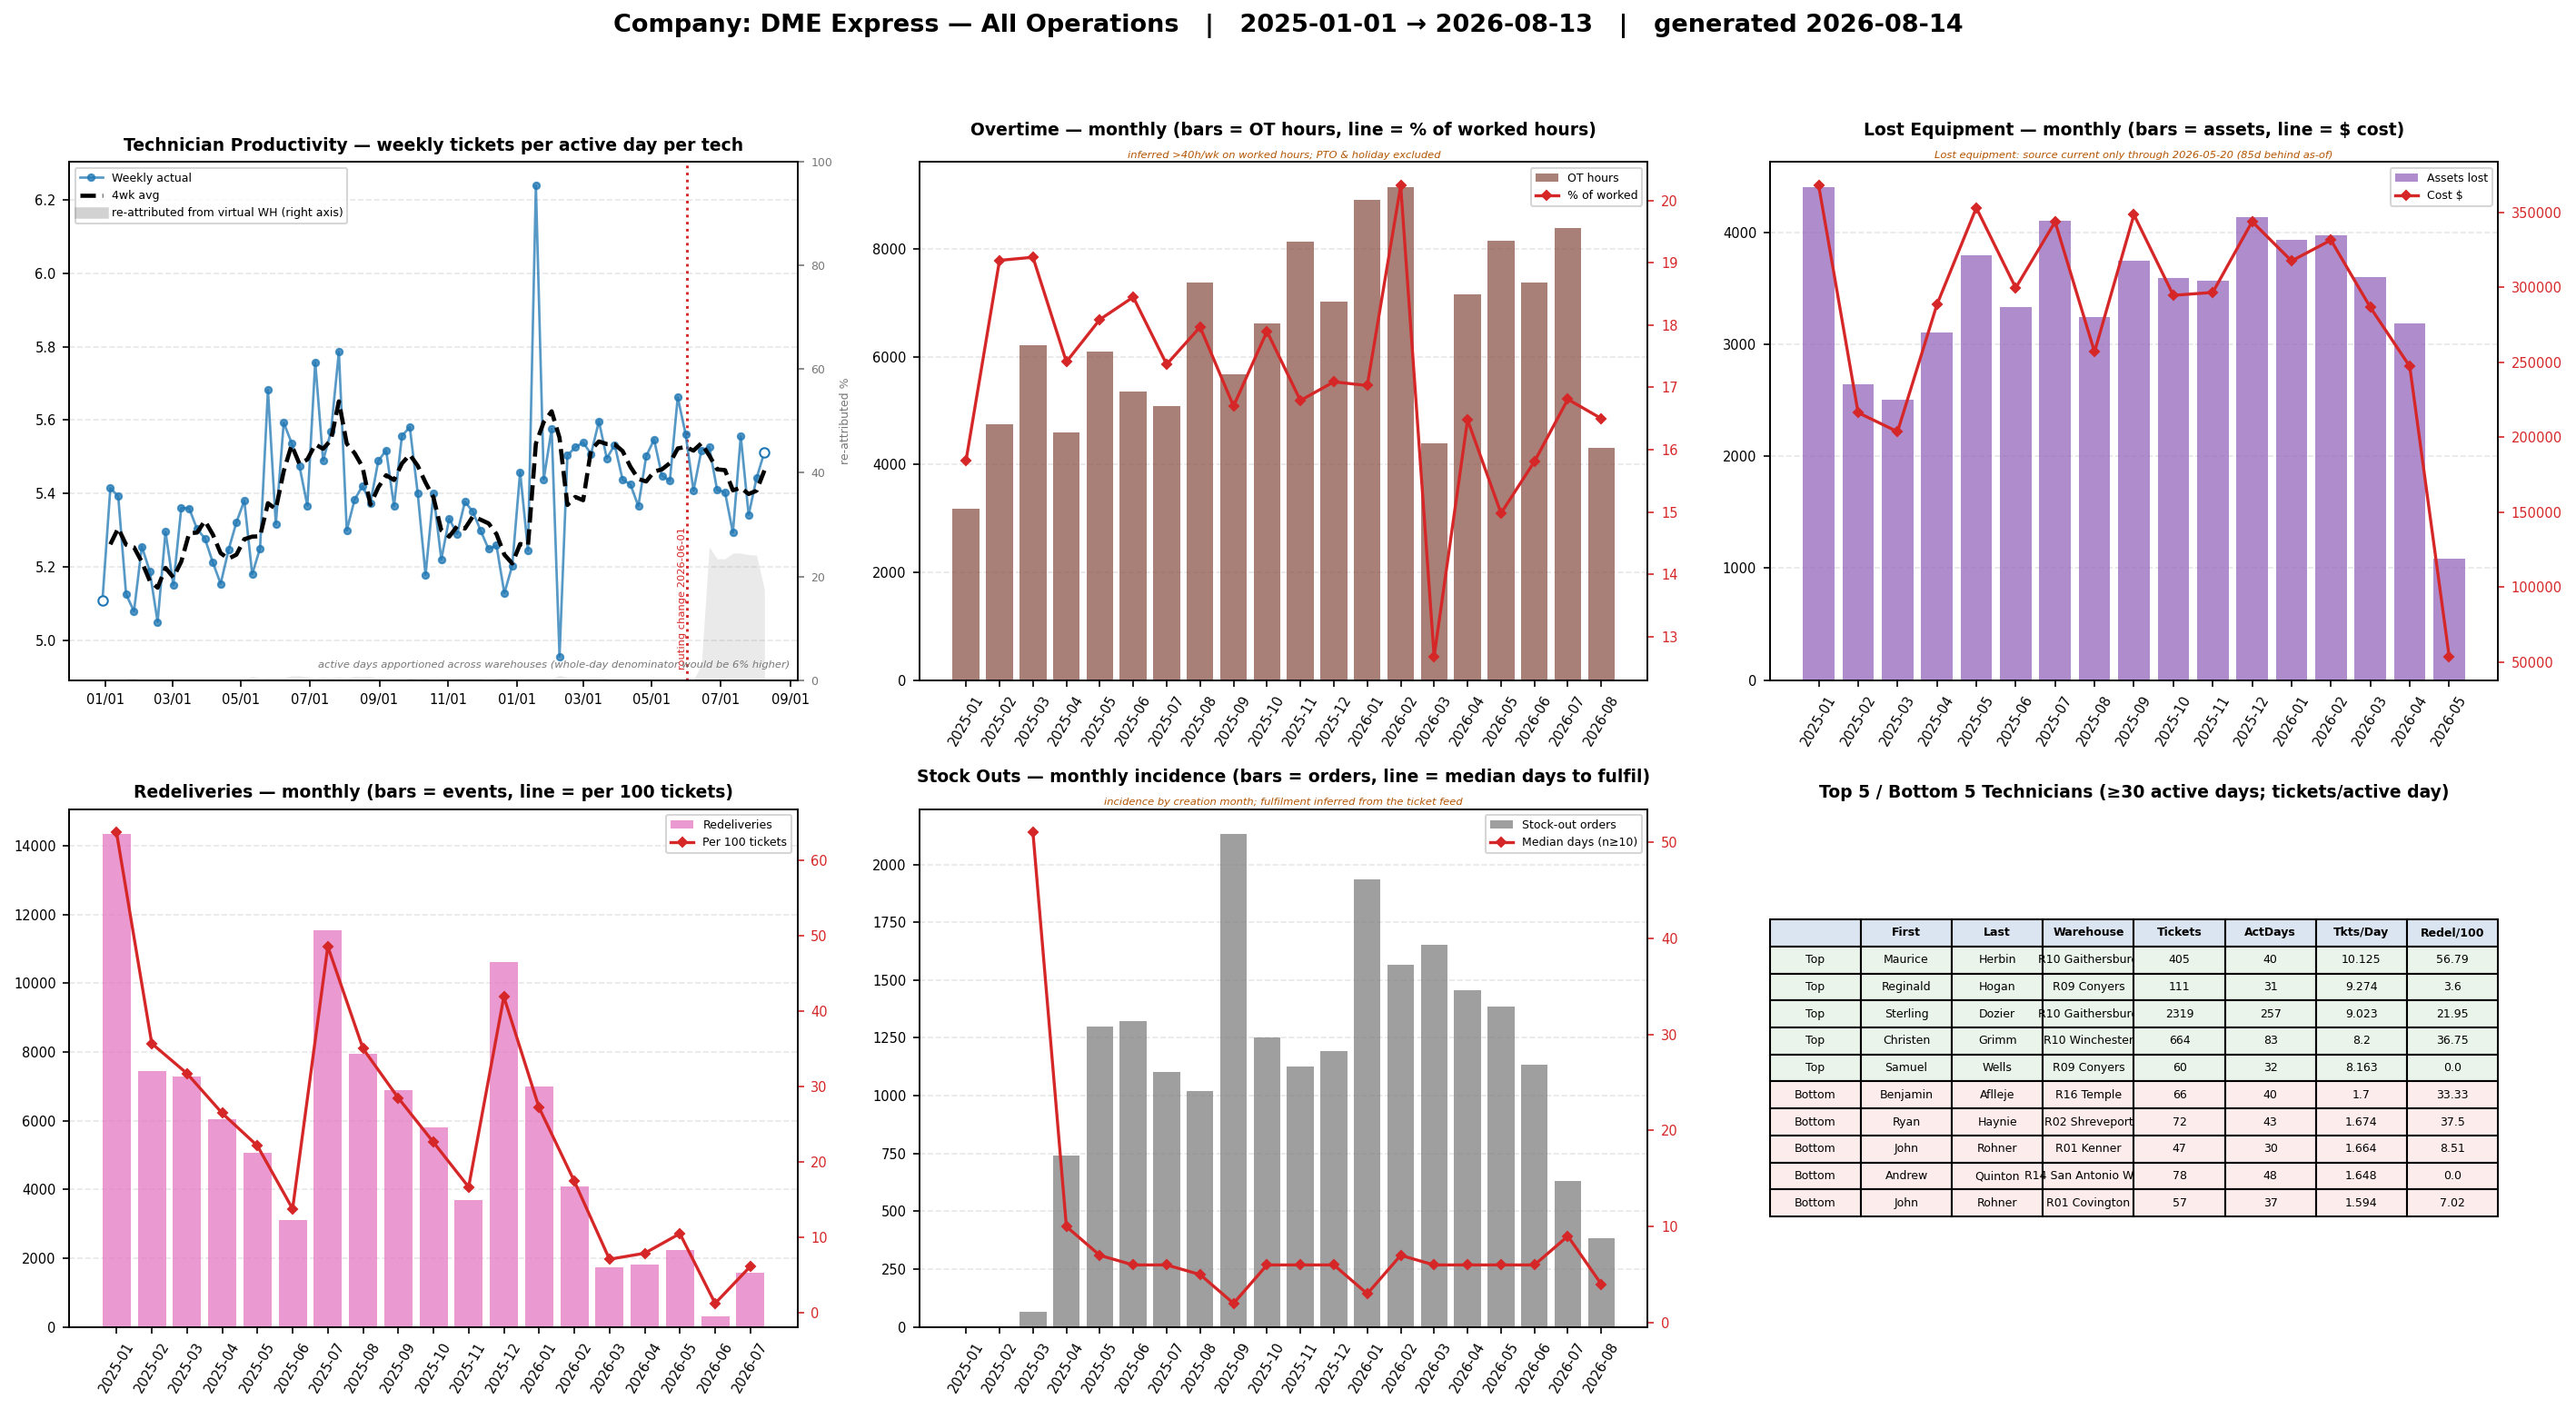

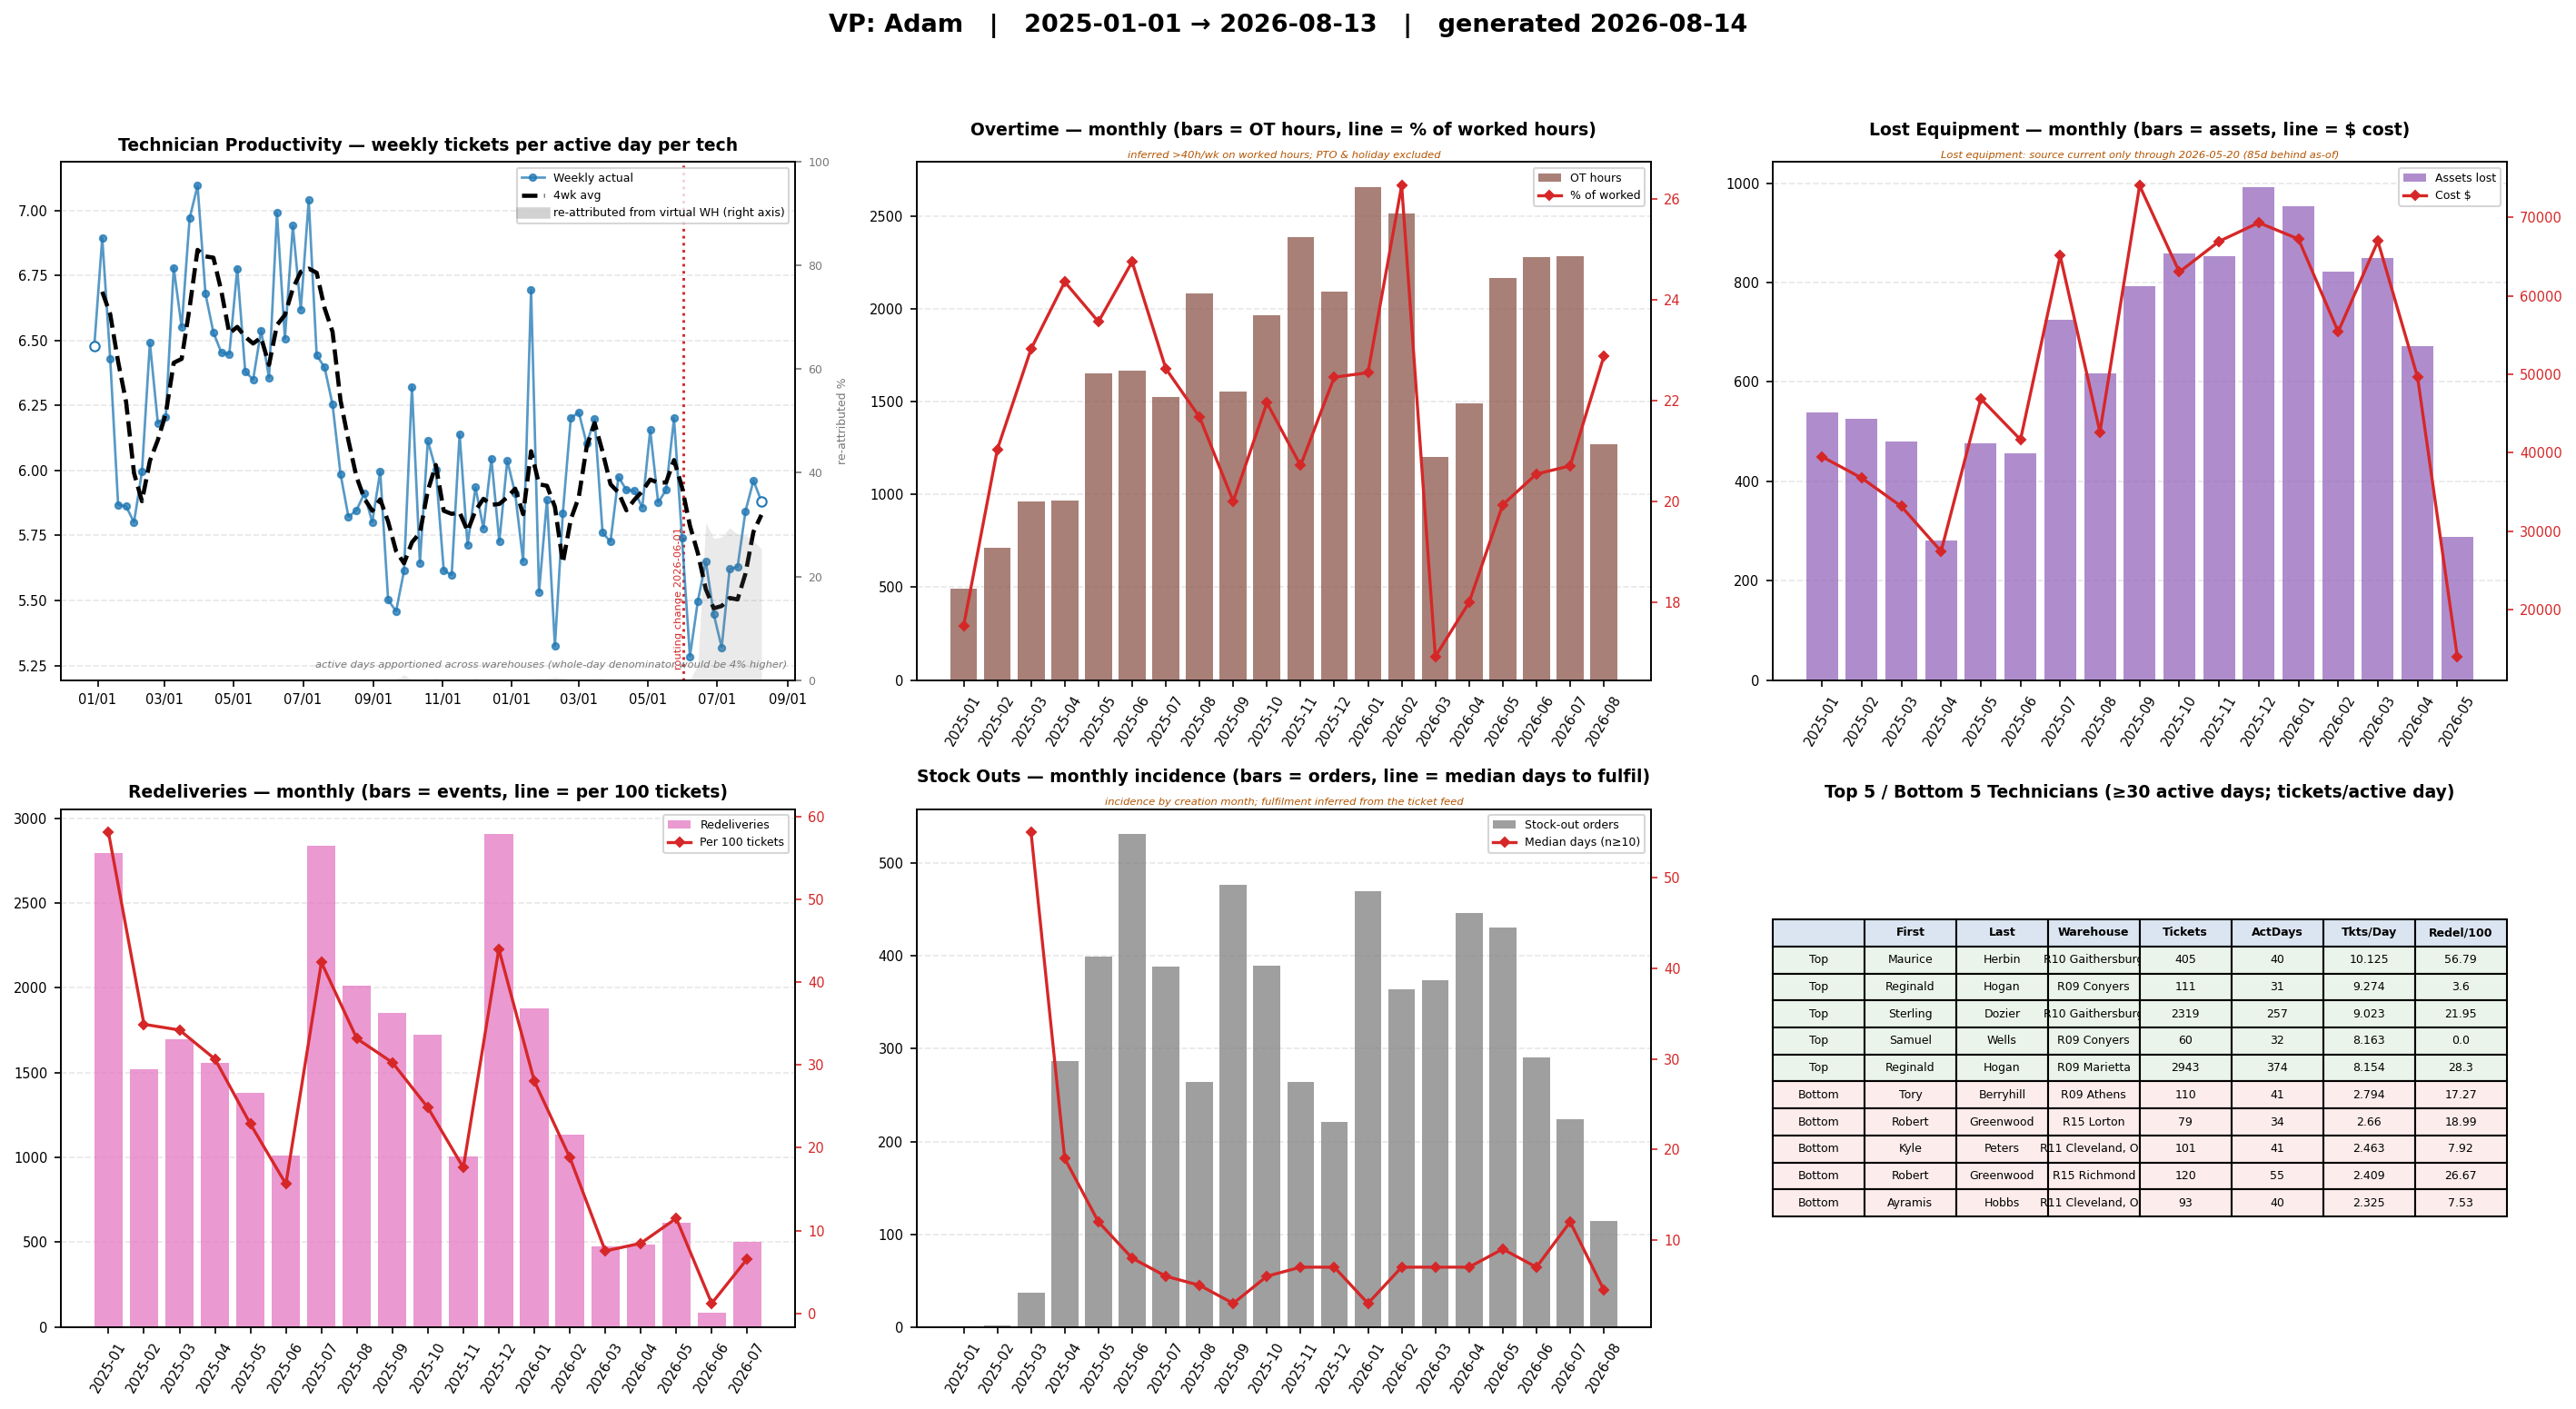

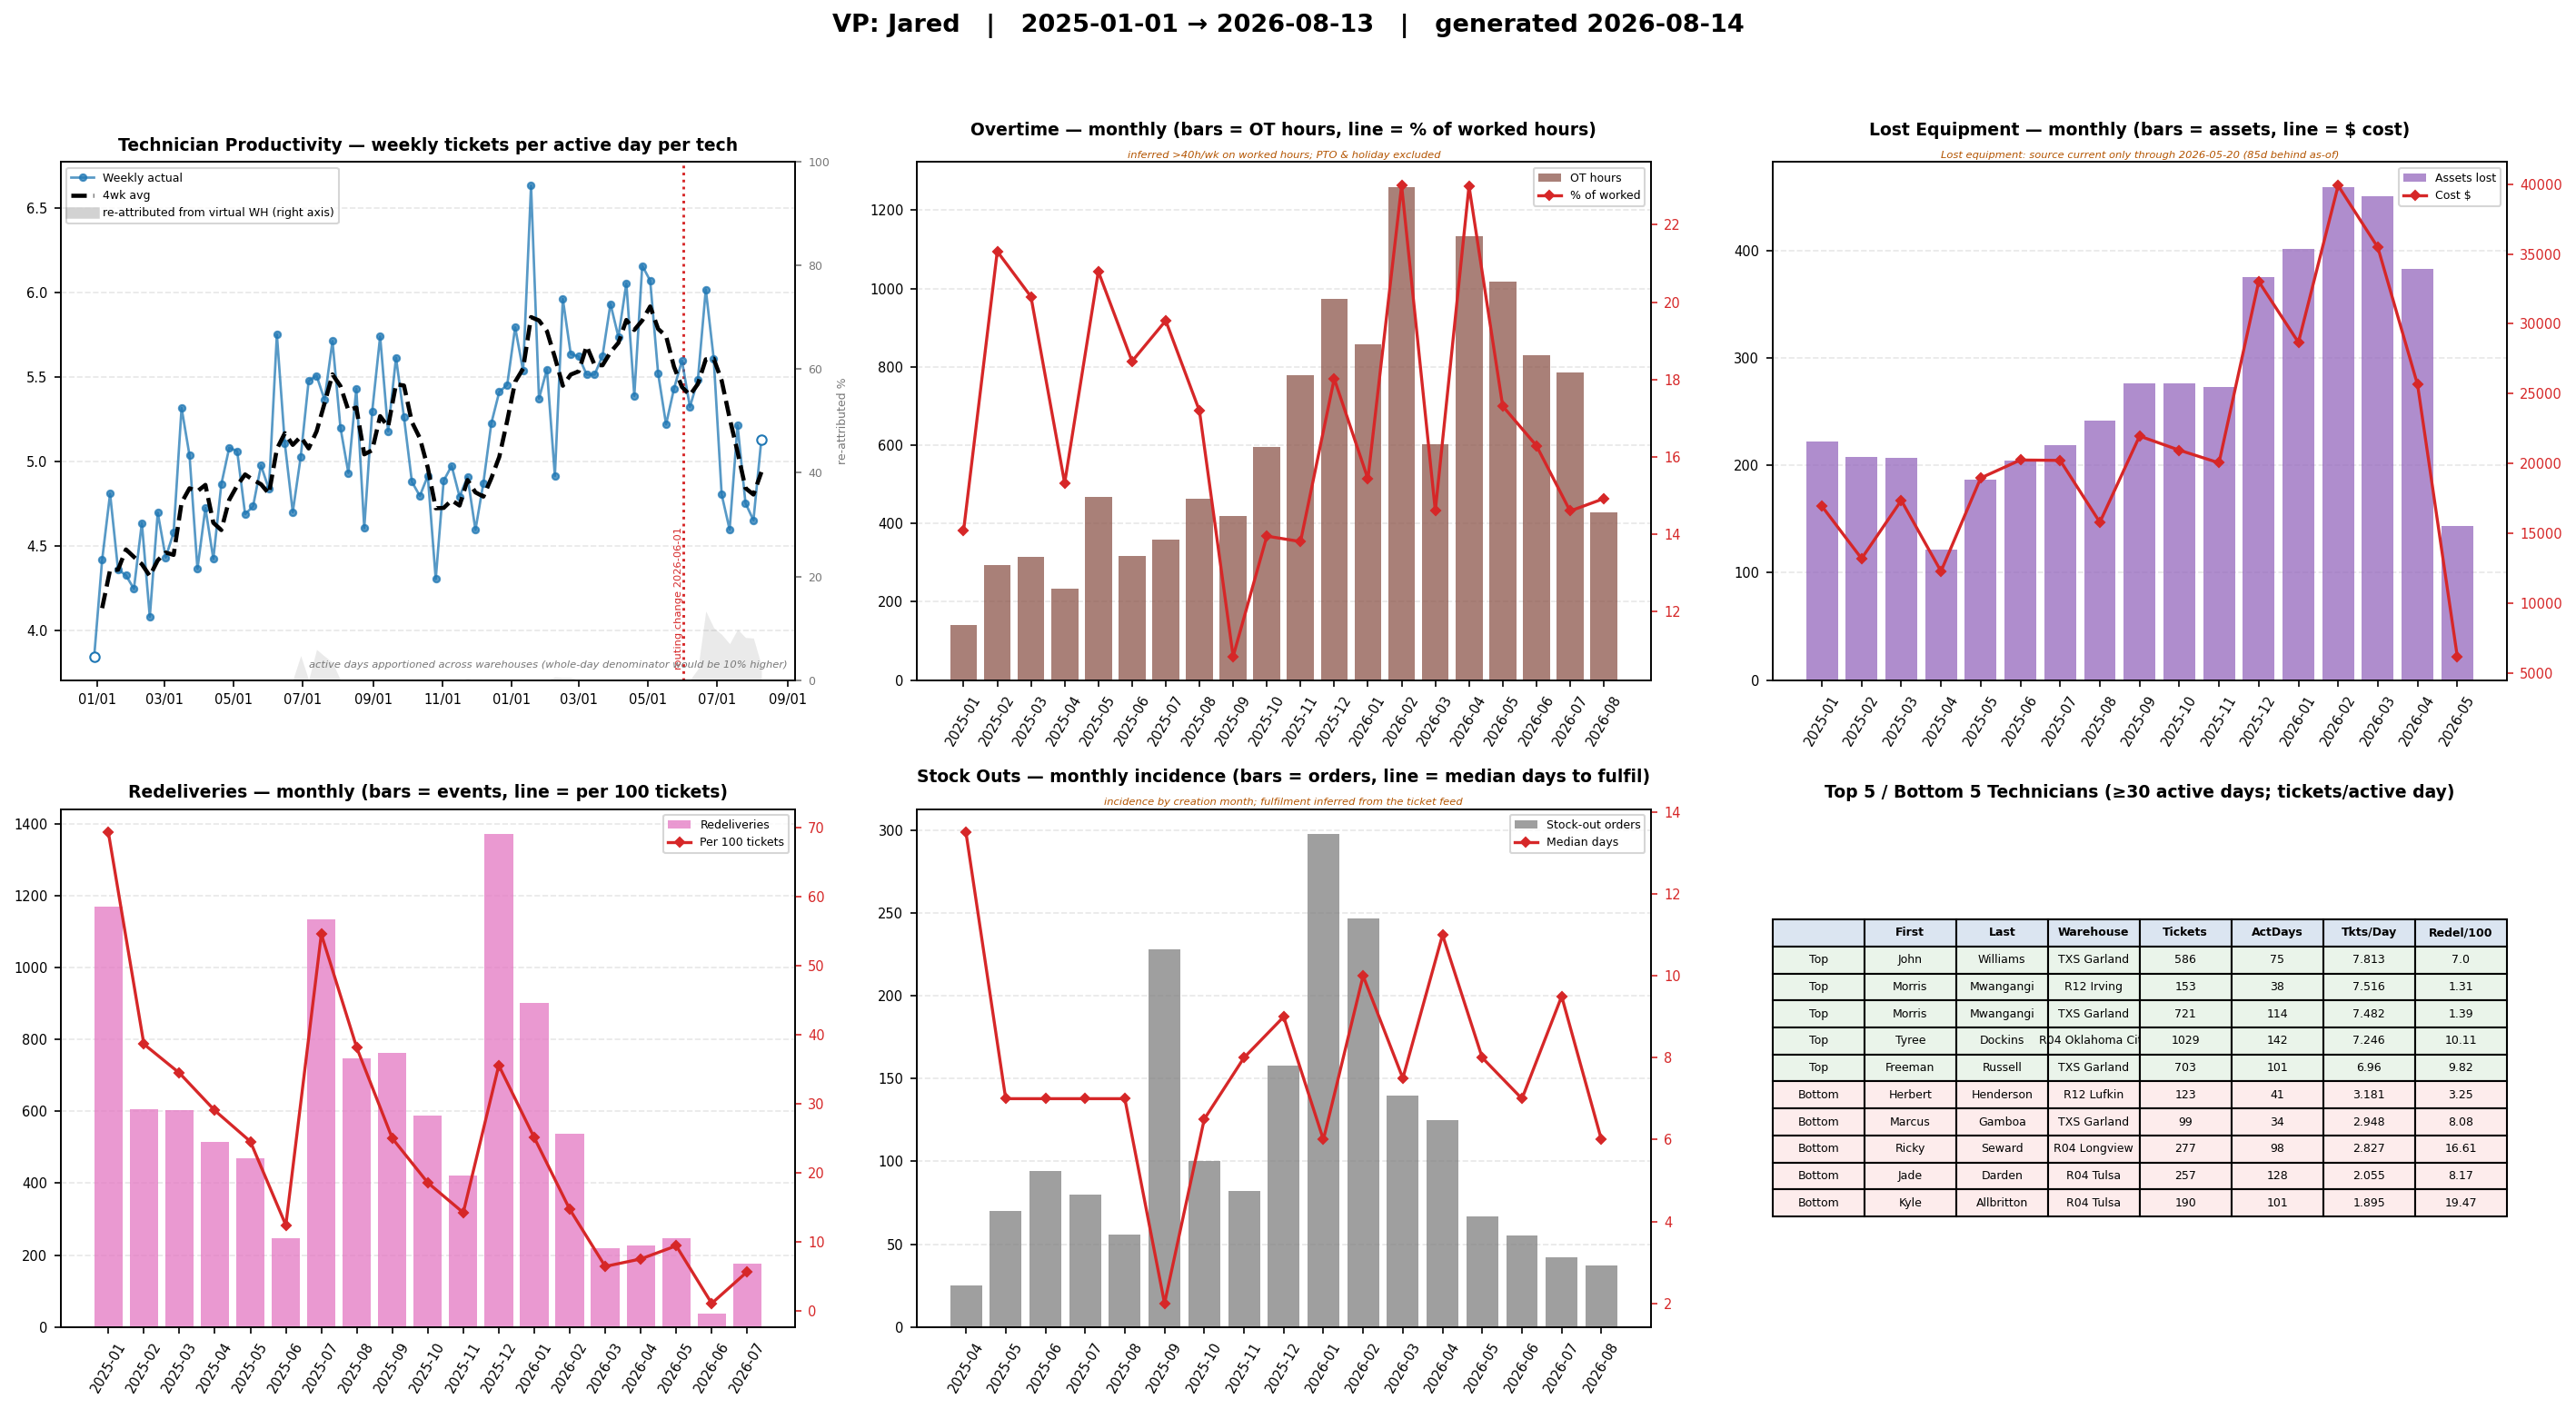

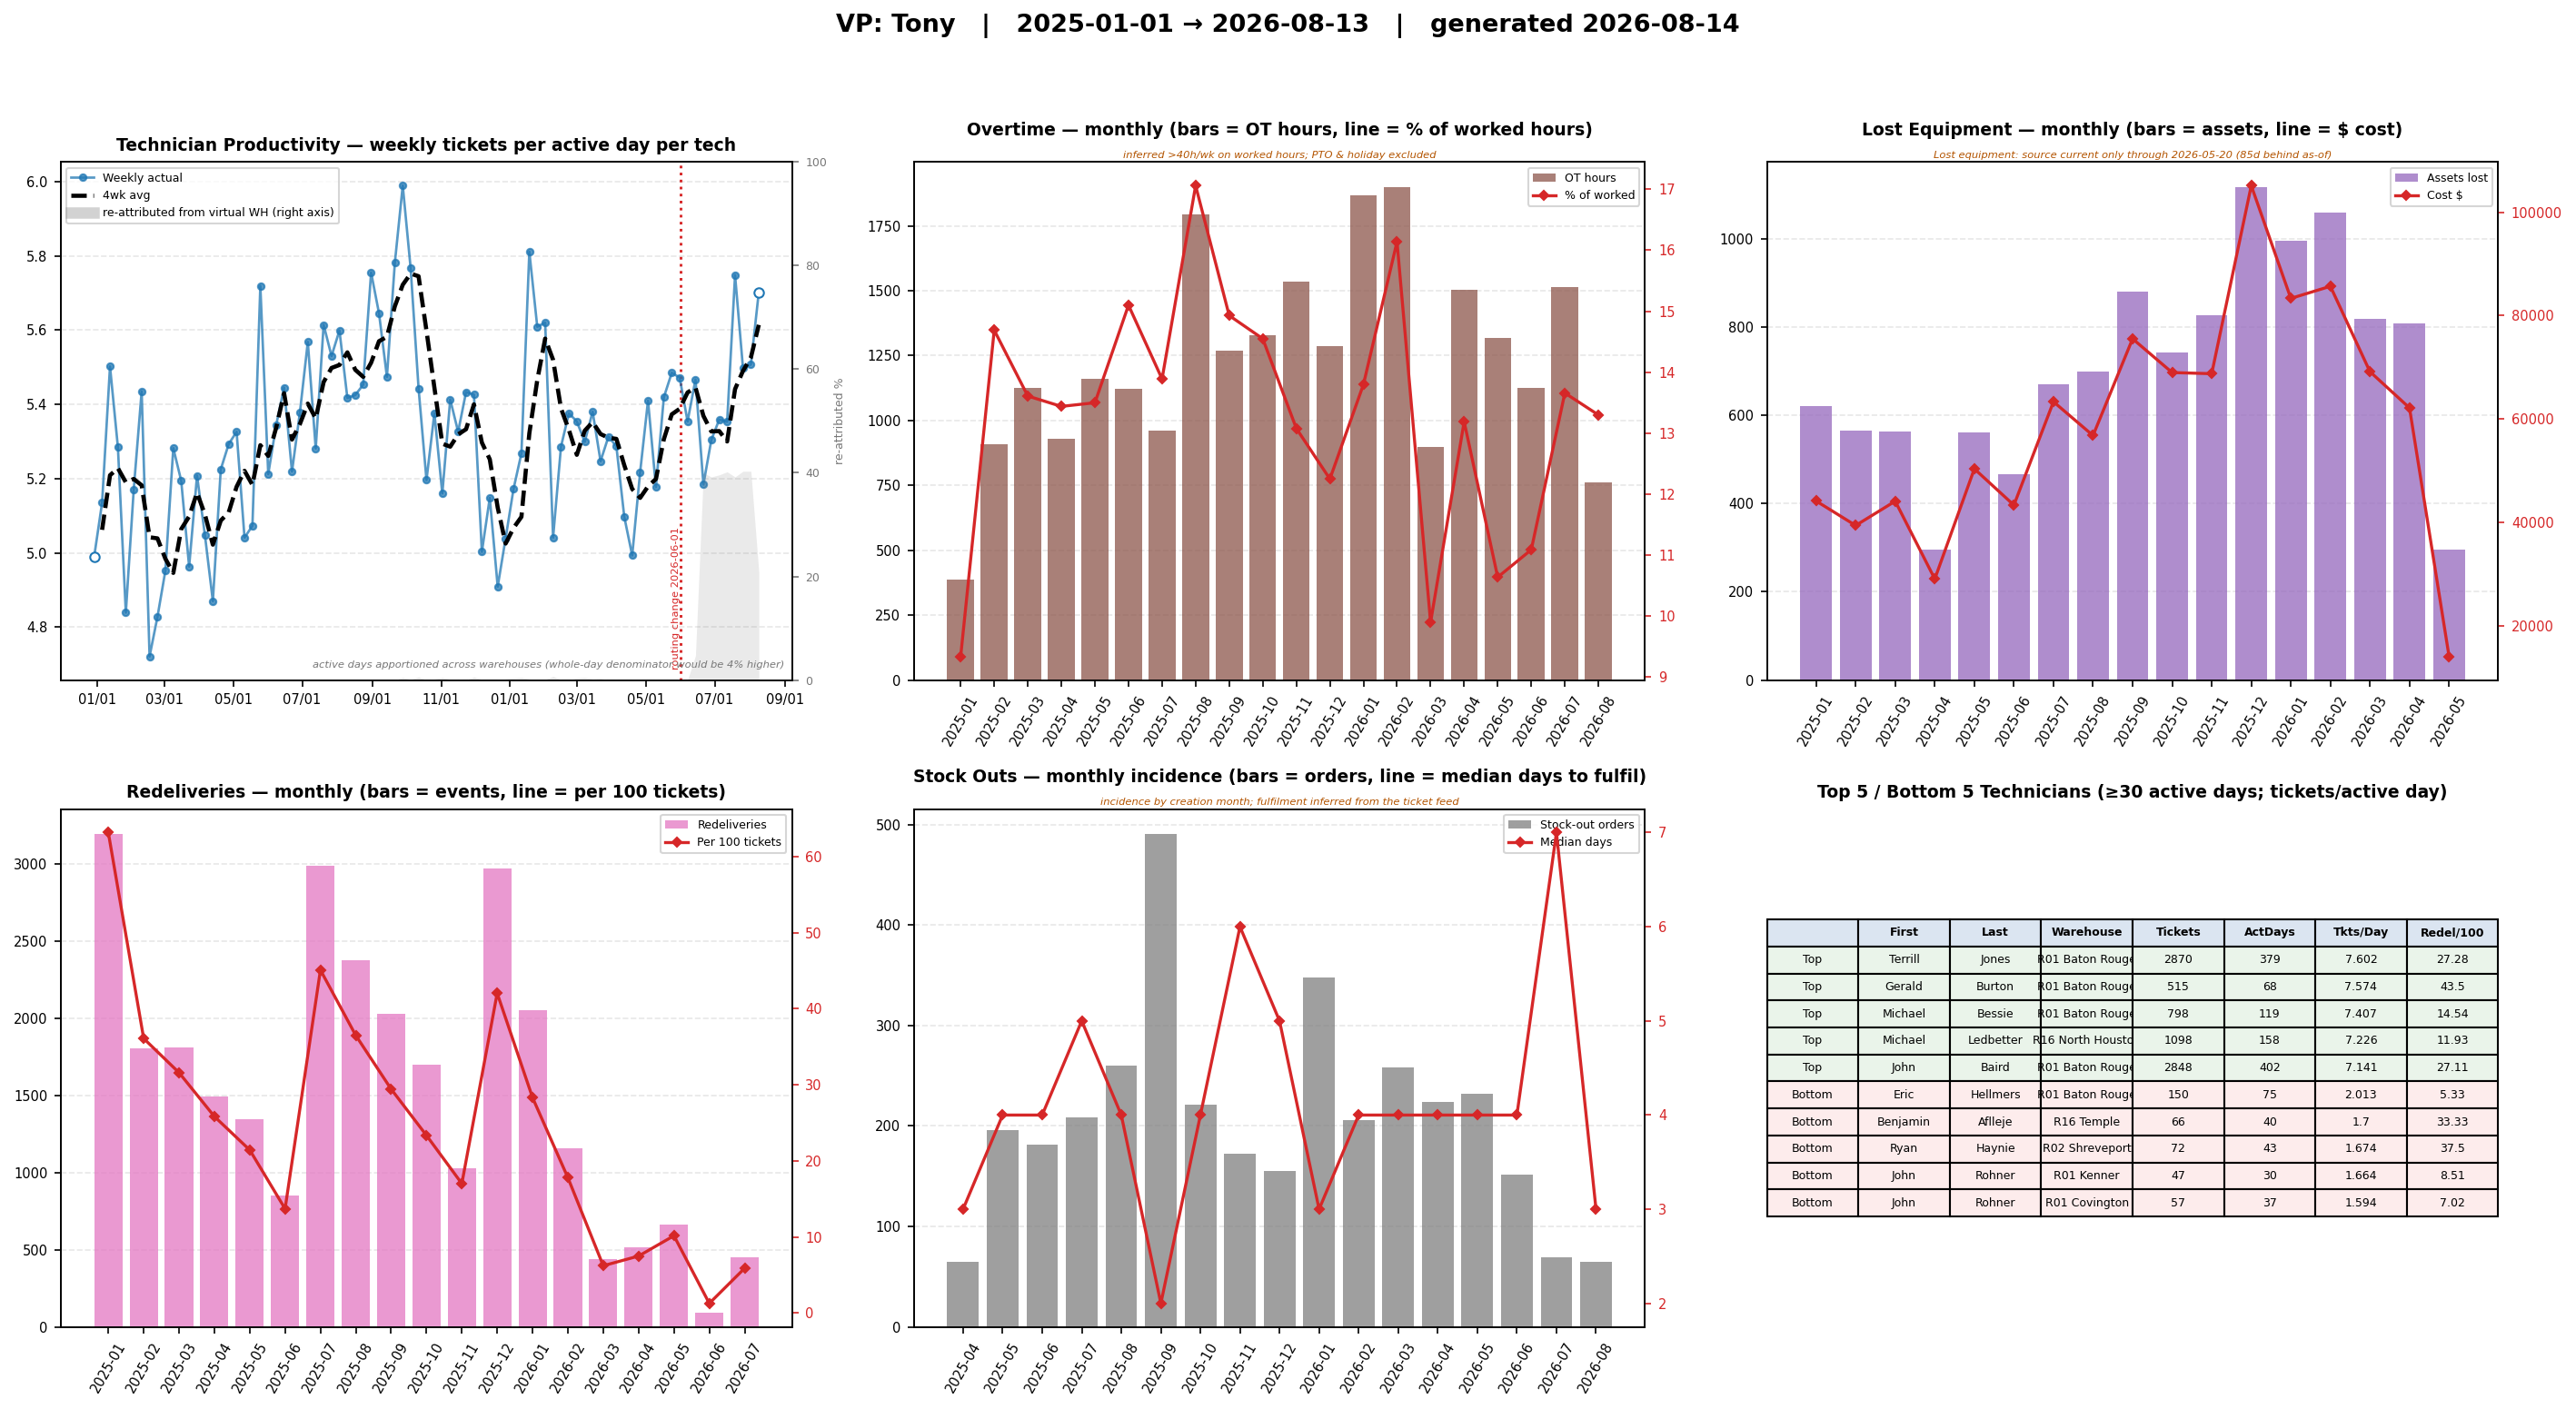

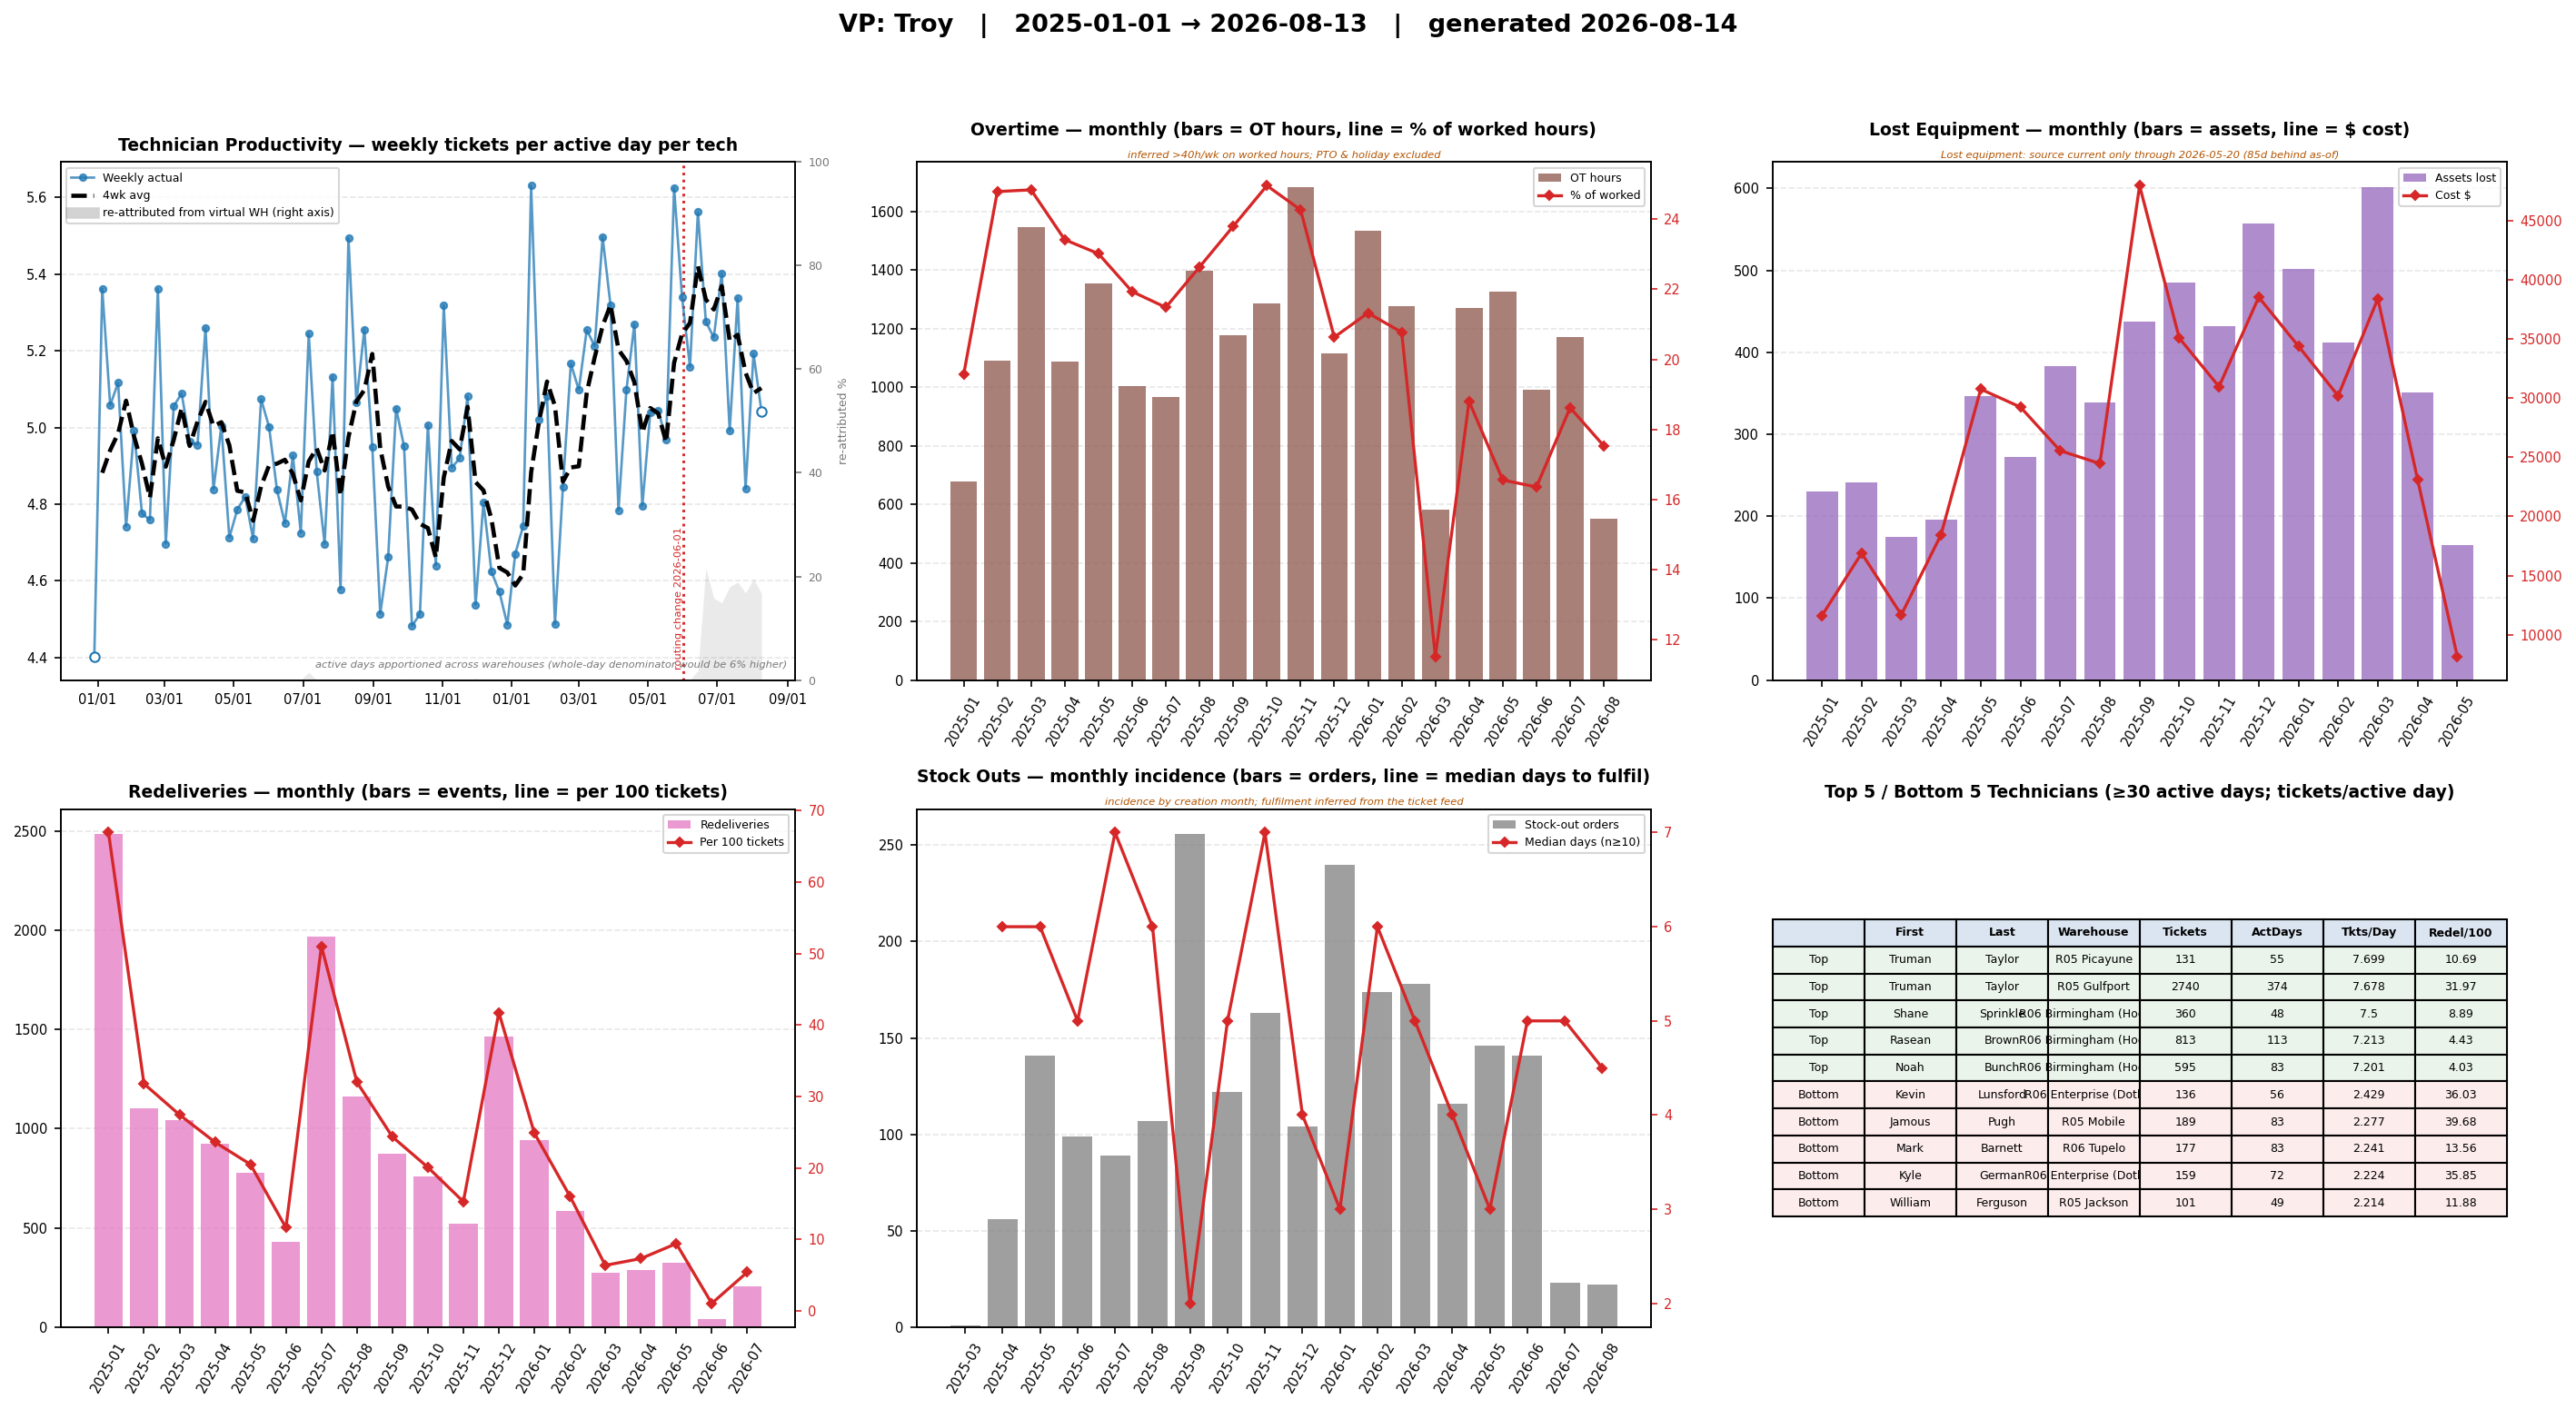

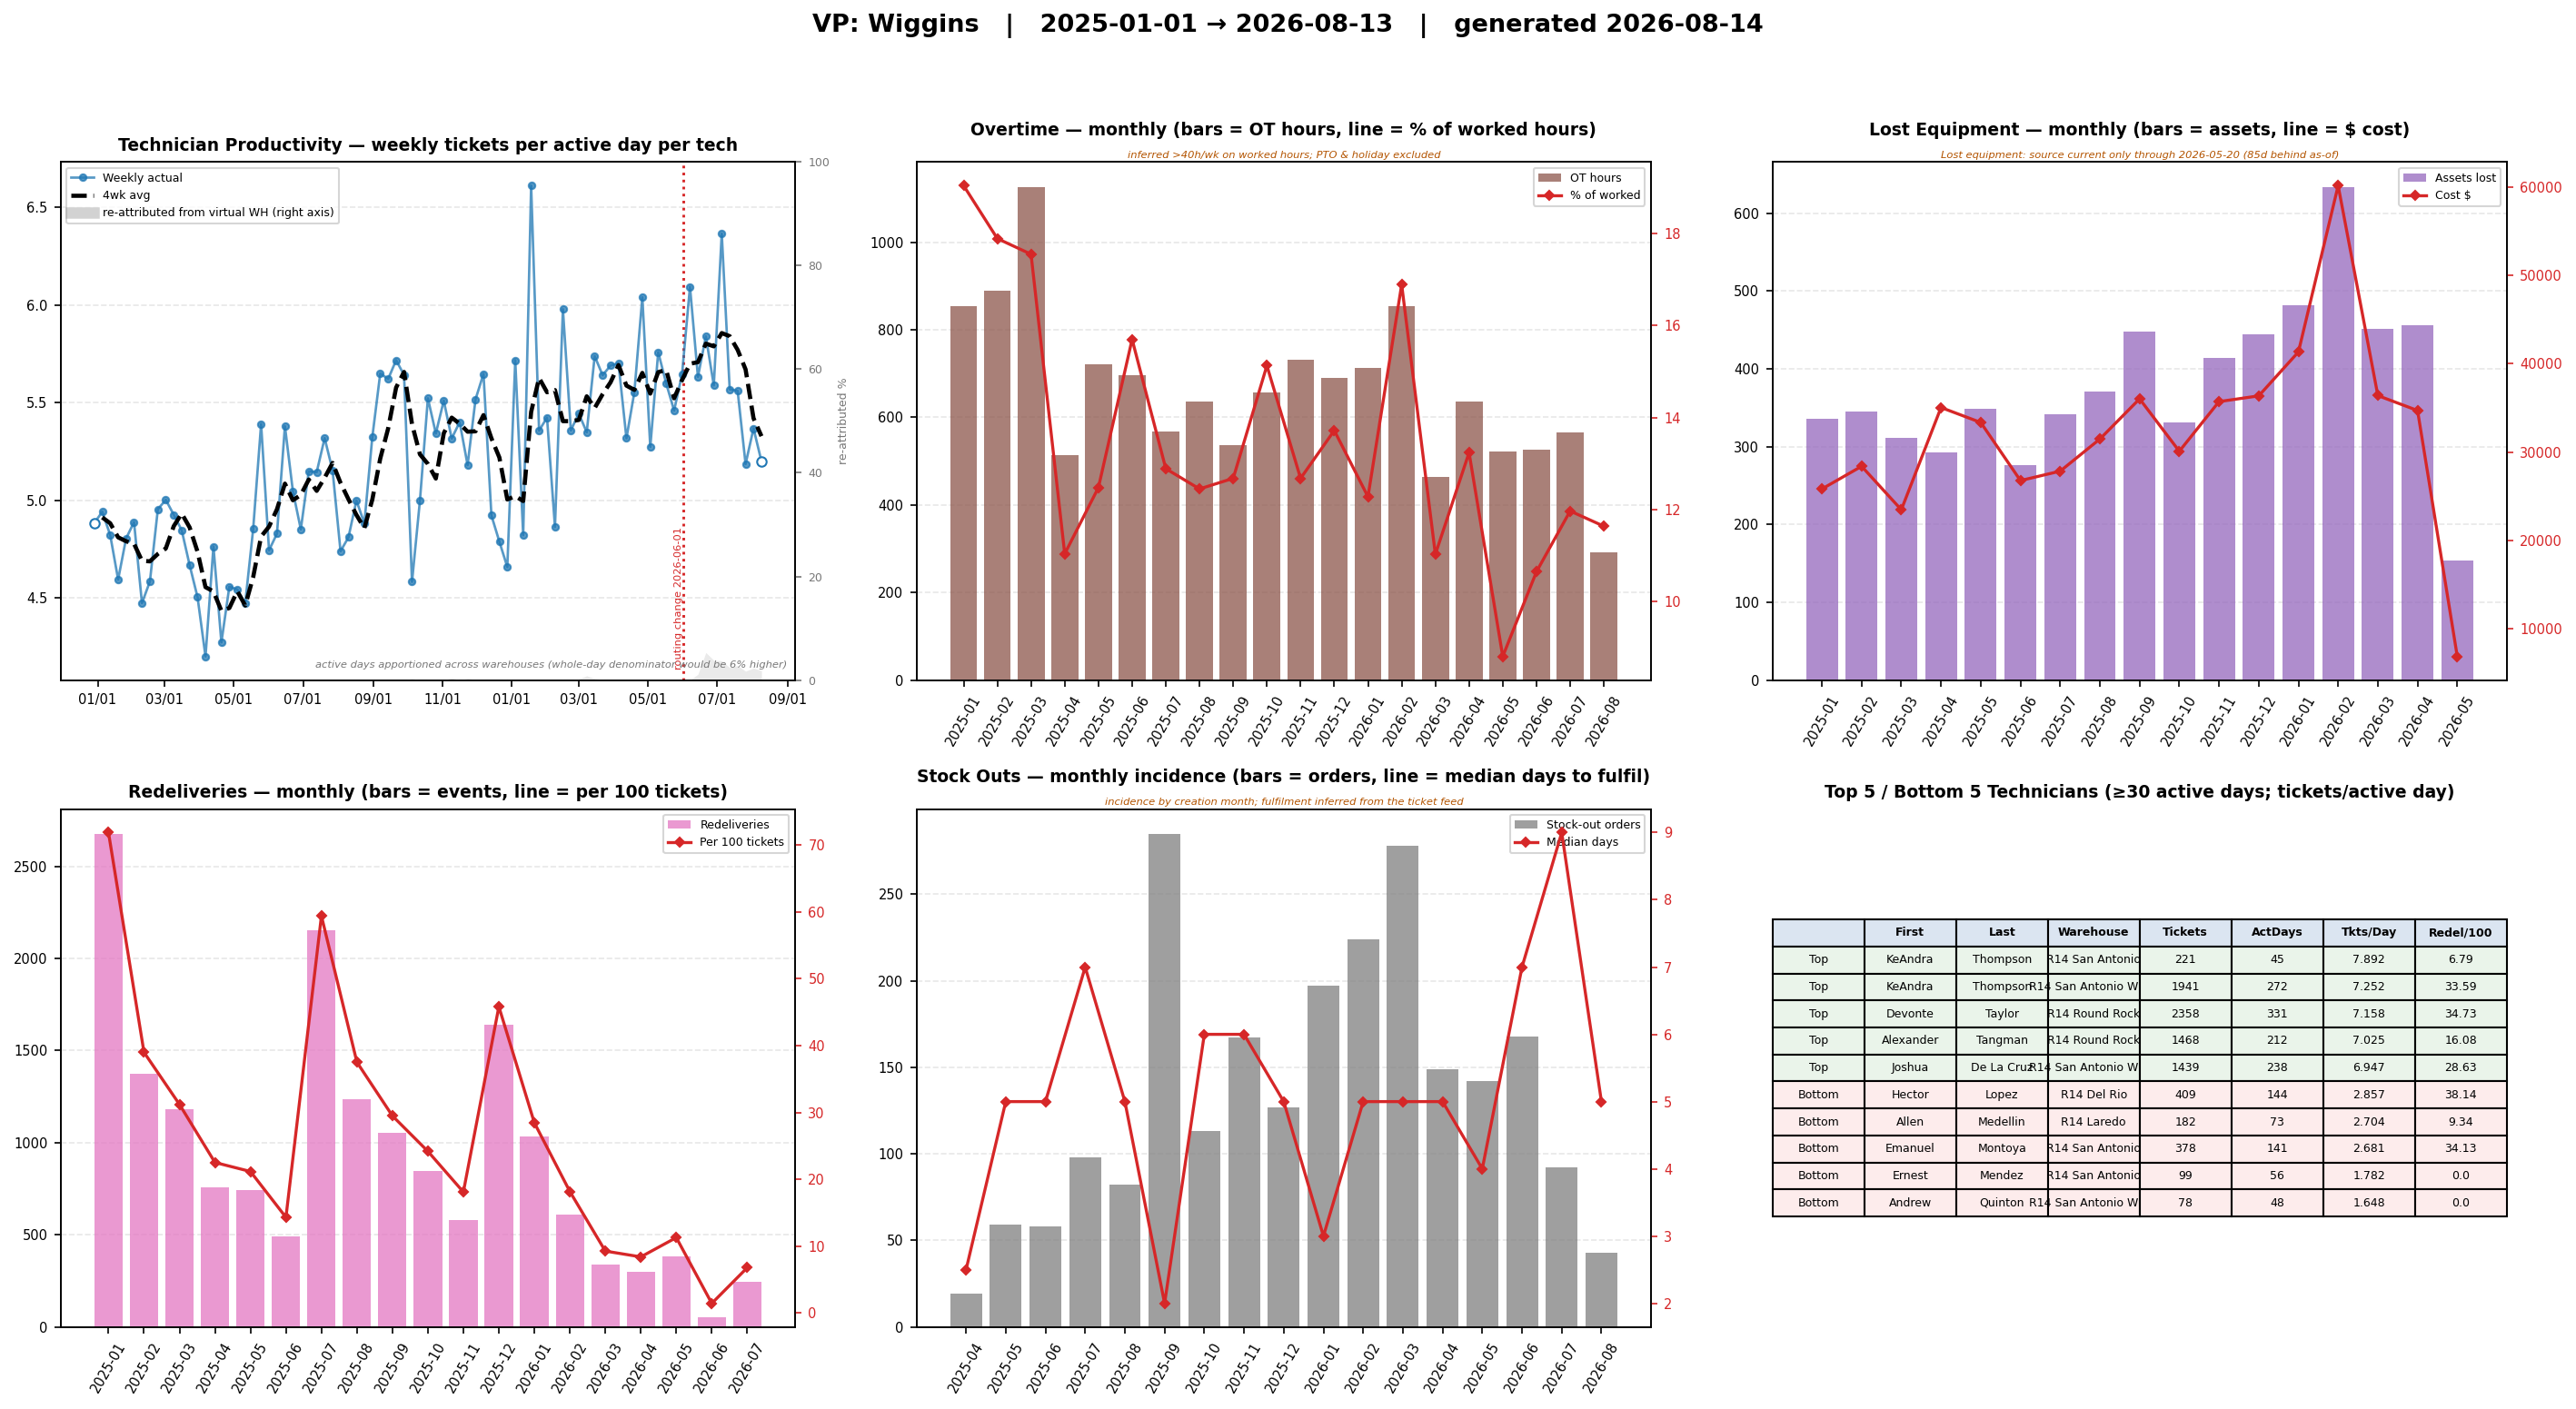

Dashboard PDF written: /./Users/aenew/OneDrive - DME Express/Reports/TechWorkload\2026-08-14\OpsDashboard_Pages_2026-08-14.pdf


In [37]:
# ─────────────────────────────────────────────────────────────────────────────
# DASHBOARD PAGE RENDERER                                       rewritten v1.3.0
# One landscape page per entity — company, each VP, each metro, each warehouse.
# Layout went 2x2 -> 2x3 to fit the three newly populated sections:
#   (0,0) technician productivity, weekly + rolling 4wk + re-attribution overlay
#   (0,1) OVERTIME, monthly (bars = OT hours, line = OT % of worked hours)
#   (0,2) LOST EQUIPMENT, monthly (bars = assets, line = $ cost) + staleness banner
#   (1,0) redeliveries, monthly (bars = events, line = per 100 tickets)
#   (1,1) STOCK OUTS, monthly incidence (bars = orders, line = median days to fulfil)
#   (1,2) top/bottom technician table
#
# v1.3.0 also fixes the inline-output problem: plt.show() used to run for every one of
# ~85 pages, embedding 110 figures and inflating the saved notebook to 33 MB against a
# standing rule that outputs are never committed. Only the pages leadership circulates
# (company and each VP) are shown inline now; the rest go straight to the PDF.
# ─────────────────────────────────────────────────────────────────────────────
from matplotlib.backends.backend_pdf import PdfPages

def _panel_weekly(ax, wk, title):
    if wk is None or wk.empty:
        ax.text(0.5, 0.5, 'No weekly data', ha='center', va='center'); ax.set_title(title); return
    wk = wk.sort_values('week_start')
    _pf = wk['is_partial_week'].fillna(False).values
    ax.plot(wk['week_start'], wk['tickets_per_active_day_per_tech'],
            color=PALETTE['attributed'], lw=1.3, marker='o', ms=3.5, alpha=0.75, label='Weekly actual')
    # partial weeks re-marked hollow so a truncated week isn't read as a dip
    _p = wk[_pf]
    if len(_p): ax.plot(_p['week_start'], _p['tickets_per_active_day_per_tech'], ls='none',
                        marker='o', ms=5, mfc='white', mec=PALETTE['attributed'])
    ax.plot(wk['week_start'], wk['rolling_4wk_avg'], color='black', lw=2.2, ls='--',
            label=f'{DASH_ROLL_WEEKS}wk avg')
    # v1.2.0 — DATA-INTEGRITY OVERLAY. The July-2026 "drop" was virtual-warehouse
    # tickets being deleted from the numerator, invisible on a page that plotted only
    # the ratio. The grey band is the share of this entity's tickets that had to be
    # re-attributed from a virtual warehouse; the vertical line marks the known
    # routing change. A rising band means read the trend with suspicion.
    if 'virtual_ticket_share_pct' in wk.columns and wk['virtual_ticket_share_pct'].fillna(0).max() > 0:
        _axv = ax.twinx()
        _axv.fill_between(wk['week_start'], wk['virtual_ticket_share_pct'].fillna(0),
                          color='#7f7f7f', alpha=0.16, lw=0, zorder=0)
        _axv.set_ylim(0, max(100, float(wk['virtual_ticket_share_pct'].fillna(0).max()) * 1.2))
        _axv.set_ylabel('re-attributed %', fontsize=6, color='#777')
        _axv.tick_params(labelsize=6, colors='#777')
        _axv.plot([], [], color='#7f7f7f', alpha=0.35, lw=6,
                  label='re-attributed from virtual WH (right axis)')
        _h, _l = _axv.get_legend_handles_labels()
    else:
        _h, _l = [], []
    try:
        _brk = pd.Timestamp(ROUTING_CHANGE_DATE)
        if wk['week_start'].min() <= _brk <= wk['week_start'].max():
            ax.axvline(_brk, color='#d62728', ls=':', lw=1.4, zorder=1)
            ax.annotate(f'routing change {ROUTING_CHANGE_DATE}', xy=(_brk, 0.02),
                        xycoords=('data', 'axes fraction'), rotation=90, fontsize=5.5,
                        color='#d62728', ha='right', va='bottom')
    except Exception:
        pass
    ax.set_title(title, fontsize=9, fontweight='bold')
    ax.tick_params(labelsize=7); ax.grid(axis='y', ls='--', alpha=0.3); ax.set_axisbelow(True)
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%m/%d'))
    _h0, _l0 = ax.get_legend_handles_labels()
    ax.legend(_h0 + _h, _l0 + _l, fontsize=6, loc='best')
    # Denominator provenance, stated on the page rather than buried in a sheet.
    if 'denominator_inflation_pct' in wk.columns:
        _inf = pd.to_numeric(wk['denominator_inflation_pct'], errors='coerce').mean()
        if pd.notna(_inf) and _inf > 1:
            ax.annotate(f'active days apportioned across warehouses '
                        f'(whole-day denominator would be {_inf:.0f}% higher)',
                        xy=(0.99, 0.02), xycoords='axes fraction', ha='right', va='bottom',
                        fontsize=5.5, style='italic', color='#777')

def _panel_monthly_dual(ax, df, bar_col, line_col, title, bar_lbl, line_lbl,
                        note=None, bar_color=None, line_color='#d62728',
                        line_min_denom_col=None, line_min_denom=10):
    """Bars on the left axis, a rate/duration line on the right. Used by the overtime,
    lost-equipment, redelivery and stock-out panels so all four read the same way.

    line_min_denom_col/line_min_denom suppress the rate line for months whose
    denominator is too thin to carry one — a median over three orders is not a median,
    and left in it rescales the whole axis and hides the informative range. The values
    stay in the Excel sheet; only the plotted point is withheld."""
    if df is None or df.empty or bar_col not in df.columns:
        ax.text(0.5, 0.5, 'No data in window', ha='center', va='center', fontsize=8)
        ax.set_title(title, fontsize=9, fontweight='bold'); ax.axis('off'); return
    df = df.sort_values('period')
    x = np.arange(len(df))
    ax.bar(x, pd.to_numeric(df[bar_col], errors='coerce').values,
           color=bar_color or PALETTE['attributed'], alpha=0.75, label=bar_lbl)
    ax.set_xticks(x); ax.set_xticklabels(df['period'].values, rotation=60, fontsize=6)
    ax.tick_params(labelsize=7); ax.grid(axis='y', ls='--', alpha=0.3); ax.set_axisbelow(True)
    _h2, _l2 = [], []
    if line_col in df.columns:
        _yv = pd.to_numeric(df[line_col], errors='coerce')
        _thin = 0
        if line_min_denom_col and line_min_denom_col in df.columns:
            _dn = pd.to_numeric(df[line_min_denom_col], errors='coerce').fillna(0)
            _mask = _dn < line_min_denom
            _thin = int(_mask.sum())
            _yv = _yv.mask(_mask)
        ax2 = ax.twinx()
        ax2.plot(x, _yv.values, color=line_color, marker='D', ms=3.5, lw=1.6,
                 label=line_lbl + (f' (n≥{line_min_denom})' if _thin else ''))
        ax2.tick_params(labelsize=7, colors=line_color)
        _h2, _l2 = ax2.get_legend_handles_labels()
    # pad the title when a note is present, or the note is drawn on top of it
    ax.set_title(title, fontsize=9, fontweight='bold', pad=14 if note else 6)
    _h1, _l1 = ax.get_legend_handles_labels()
    ax.legend(_h1 + _h2, _l1 + _l2, fontsize=6, loc='best')
    if note:
        ax.annotate(note, xy=(0.5, 1.005), xycoords='axes fraction', ha='center', va='bottom',
                    fontsize=5.5, style='italic', color='#b35400')

def _panel_topbottom(ax, tb, title):
    ax.axis('off'); ax.set_title(title, fontsize=9, fontweight='bold')
    if tb is None or tb.empty:
        ax.text(0.5, 0.5, f'No technicians clear the {DASH_MIN_ACTIVE_DAYS}-active-day floor',
                ha='center', va='center', fontsize=8); return
    cols = ['rank_group','techfirstname','techlastname','tech_warehouse',
            'total_tickets','active_weekdays','tickets_per_active_day','redel_per_100_tickets']
    d = tb[cols].copy()
    d.columns = ['','First','Last','Warehouse','Tickets','ActDays','Tkts/Day','Redel/100']
    t = ax.table(cellText=d.values, colLabels=d.columns, loc='center', cellLoc='center')
    t.auto_set_font_size(False); t.set_fontsize(6); t.scale(1, 1.15)
    for (r, c), cell in t.get_celld().items():
        if r == 0: cell.set_text_props(fontweight='bold'); cell.set_facecolor('#dbe5f1')
        elif d.iloc[r-1, 0] == 'Top': cell.set_facecolor('#eaf4ea')
        else: cell.set_facecolor('#fdecec')

def _entity_page(pdf, name, level, wk, ot, lost, redel, so, tb, save_png=False):
    fig, axs = plt.subplots(2, 3, figsize=(19, 10.5))
    fig.suptitle(f'{level}: {name}   |   {FILTER_START} → {FILTER_END}   |   generated {RUN_DATE}',
                 fontsize=13, fontweight='bold')
    _panel_weekly(axs[0,0], wk, 'Technician Productivity — weekly tickets per active day per tech')
    # Overtime: OT hours are inferred FLSA-style from de-duplicated daily payroll hours,
    # excluding PTO/holiday. Stated on the panel because the basis changed in v1.3.0.
    _panel_monthly_dual(axs[0,1], ot, 'ot_hours', 'ot_pct_of_worked',
                        'Overtime — monthly (bars = OT hours, line = % of worked hours)',
                        'OT hours', '% of worked',
                        note='inferred >40h/wk on worked hours; PTO & holiday excluded',
                        bar_color='#8c564b')
    _panel_monthly_dual(axs[0,2], lost, 'lost_asset_count', 'lost_asset_cost',
                        'Lost Equipment — monthly (bars = assets, line = $ cost)',
                        'Assets lost', 'Cost $',
                        note=(LOST_STALE_NOTE if LOST_IS_STALE else None) or
                             ('bulk events excluded' if LOST_BULK_EVENT_DATES else None),
                        bar_color='#9467bd')
    _panel_monthly_dual(axs[1,0], redel, 'redelivery_count', 'redel_per_100_tickets',
                        'Redeliveries — monthly (bars = events, line = per 100 tickets)',
                        'Redeliveries', 'Per 100 tickets',
                        bar_color=PALETTE['redelivery'])
    # Stock outs: incidence by creation month, with time-to-fulfil as the rate line.
    # v1.3.0 reframing — see Cell 16. Warehouse pages now carry real numbers instead of
    # the old "n/a at this grain" notice, for the ~74% of orders the order join resolves.
    _panel_monthly_dual(axs[1,1], so, 'stockout_orders', 'median_days_to_fulfil',
                        'Stock Outs — monthly incidence (bars = orders, line = median days to fulfil)',
                        'Stock-out orders', 'Median days',
                        note='incidence by creation month; fulfilment inferred from the ticket feed',
                        bar_color='#7f7f7f',
                        line_min_denom_col='stockout_orders', line_min_denom=10)
    _panel_topbottom(axs[1,2], tb, f'Top {DASH_TOP_N} / Bottom {DASH_TOP_N} Technicians '
                                    f'(≥{DASH_MIN_ACTIVE_DAYS} active days; tickets/active day)')
    fig.tight_layout(rect=[0, 0, 1, 0.95])
    pdf.savefig(fig)
    if save_png:
        save_fig(fig, f'Dash_{level}_{re.sub(r"[^A-Za-z0-9]+","_",str(name))}')
        plt.show()          # v1.3.0: inline only for the pages leadership circulates
    plt.close(fig)

def _sub(df, col, val): return df[df[col] == val] if (df is not None and not df.empty and col in df.columns) else pd.DataFrame()

_pdf_path = os.path.join(OUT_DIR, DASH_PDF_NAME)
with PdfPages(_pdf_path) as _pdf:
    # Company page first, then VPs, metros, warehouses (board reading order)
    _entity_page(_pdf, 'DME Express — All Operations', 'Company',
                 dash_wk_prod_co, dash_mo_ot_co, dash_mo_lost_co, dash_mo_redel_co,
                 dash_mo_stockout_co, dash_tb_co, save_png=True)
    for _v in sorted(dash_wk_prod_vp['vp'].dropna().unique()):
        _entity_page(_pdf, _v, 'VP', _sub(dash_wk_prod_vp,'vp',_v), _sub(dash_mo_ot_vp,'vp',_v),
                     _sub(dash_mo_lost_vp,'vp',_v), _sub(dash_mo_redel_vp,'vp',_v),
                     _sub(dash_mo_stockout_vp,'vp',_v), _sub(dash_tb_vp,'vp',_v), save_png=True)
    for _m in sorted(dash_wk_prod_metro['metro'].dropna().unique()):
        _entity_page(_pdf, _m, 'Metro', _sub(dash_wk_prod_metro,'metro',_m), _sub(dash_mo_ot_metro,'metro',_m),
                     _sub(dash_mo_lost_metro,'metro',_m), _sub(dash_mo_redel_metro,'metro',_m),
                     _sub(dash_mo_stockout_metro,'metro',_m), _sub(dash_tb_metro,'metro',_m))
    for _w in sorted(dash_wk_prod_wh['tech_warehouse'].dropna().unique()):
        _entity_page(_pdf, _w, 'Warehouse', _sub(dash_wk_prod_wh,'tech_warehouse',_w),
                     _sub(dash_mo_ot_wh,'tech_warehouse',_w), _sub(dash_mo_lost_wh,'tech_warehouse',_w),
                     _sub(dash_mo_redel_wh,'tech_warehouse',_w),
                     _sub(dash_mo_stockout_wh,'tech_warehouse',_w), _sub(dash_tb_wh,'tech_warehouse',_w))
print(f'Dashboard PDF written: {_pdf_path}')


## Cell 19 — EXCEL EXPORT & CONNECTION CLOSE *(extended v1.3.0)*

In [38]:
# ─────────────────────────────────────────────────────────────────────────────
# EXCEL EXPORT                                                  extended v1.3.0
# One sheet per grouping x metric family, plus README, diagnostics and the new
# overtime / lost-equipment / stock-out families. No patient identifiers exported.
# ─────────────────────────────────────────────────────────────────────────────
from openpyxl import Workbook
from openpyxl.styles import Font, PatternFill, Alignment
from openpyxl.utils import get_column_letter

_D_PCT = {'tickets_per_active_day_per_tech','weekday_daily_tickets_per_tech','rolling_4wk_avg',
          'tickets_per_active_day','redel_per_100_tickets','lost_asset_cost',
          'tickets_per_active_day_wholeday','active_day_equiv','denominator_inflation_pct',
          'virtual_ticket_share_pct',
          # v1.3.0
          'ot_hours','ot_pct_of_worked','ot_hours_per_tech','ot_hours_per_employee',
          'worked_hours','leave_hours','total_hours','ot_hours_all_paytypes',
          'leave_pct_of_total','ot_overstatement_pct',
          'lost_pct_of_inventory','lost_cost_per_1k_pt_days','recovery_rate_pct',
          'median_days_to_resolve','lost_cost','cost',
          'median_days_to_fulfil','p75_days_to_fulfil','median_open_age','fulfilled_pct',
          'stockouts_per_100_tickets','p25_days','median_days','p75_days','p90_days',
          'canceled_pct','open_pct','pct_employees_with_ot'}
_HDR_FILL = PatternFill('solid', fgColor='1F4E79'); _HDR_FONT = Font(color='FFFFFF', bold=True)

def _dws(wb, name, df, fcol=1):
    ws = wb.create_sheet(name[:31])
    if df is None or df.empty:
        ws.cell(1, 1, 'No data in window'); return
    d = df.copy()
    for _dc in ('week_start', 'creation_date', 'lost_date', 'min_created', 'max_created'):
        if _dc in d.columns:
            d[_dc] = pd.to_datetime(d[_dc], errors='coerce').dt.strftime('%Y-%m-%d')
    for j, col in enumerate(d.columns, 1):
        c = ws.cell(1, j, col); c.fill = _HDR_FILL; c.font = _HDR_FONT
        c.alignment = Alignment(horizontal='center')
    for i, row in enumerate(d.itertuples(index=False), 2):
        for j, (col, val) in enumerate(zip(d.columns, row), 1):
            if isinstance(val, (pd.Timestamp,)): val = val.strftime('%Y-%m-%d')
            elif pd.isna(val): val = None
            elif isinstance(val, (np.integer,)): val = int(val)
            elif isinstance(val, (np.floating,)): val = float(val)
            elif isinstance(val, (np.bool_,)): val = bool(val)
            cell = ws.cell(i, j, val)
            if col in _D_PCT: cell.number_format = '0.00'
            elif isinstance(val, int) and not isinstance(val, bool): cell.number_format = '#,##0'
    ws.freeze_panes = ws.cell(2, fcol + 1)
    for j, col in enumerate(d.columns, 1):
        _w = max(len(str(col)), int(d[col].astype(str).str.len().quantile(0.9)) if len(d) else 8)
        ws.column_dimensions[get_column_letter(j)].width = min(38, max(10, _w + 2))

wb = Workbook(); wb.remove(wb.active)
_readme = pd.DataFrame({'OpsDashboard README': [
    f'Generated {RUN_DATE} | window {FILTER_START} to {FILTER_END} | source notebook v1.3.0',
    'Productivity: weekly Sun-Sat, weekday tickets, tickets-per-active-day (pooled), rolling 4wk avg.',
    'v1.2.0 — the Jul-2026 "productivity drop" was a MEASUREMENT ARTIFACT, not an operations change:',
    '  (a) virtual warehouse Z CS began carrying real field tickets in Jun-2026 (24.3% of eligible',
    '      weekday tickets by Jul); v1.1.0 deleted them from the numerator but kept the technician',
    '      active day in the denominator. They are now re-attributed to the warehouse the technician',
    '      actually worked that day/week/month — see the Diag_* sheets.',
    '  (b) warehouse-grain active days were double-counted (whole day credited to every warehouse a',
    '      technician touched, +34.9% vs the honest company total in Jul-2026). Days are now',
    '      apportioned by that day\'s ticket share; tickets_per_active_day_wholeday reproduces v1.1.0.',
    'Company Jun->Jul tickets/active-day: -13.2% as reported vs -2.1% corrected. Raw volume ROSE 6.4%.',
    '',
    'v1.3.0 — three sections populated. Read these caveats before quoting any of them:',
    'OVERTIME: INFERRED, not read from the feed. PLC Reg_Hrs/OT1_Hrs/OT2_Hrs/Paid_Hrs/Est_* are',
    '  pay-period values repeated on every daily row (~14x daily Hours) and OT1_Hrs is 0 from',
    '  2026-02 on, so OT is inferred FLSA-style (>40 h in a Sun-Sat week) from daily Hours.',
    '  PTO and Holiday are EXCLUDED from the threshold (paid leave does not count toward 40h);',
    '  ot_hours_all_paytypes reconciles to the older, ~18%-overstated basis.',
    '  The payroll feed re-loads overlapping windows, so rows are de-duplicated first — without',
    '  that, Jun-2026 reads 66% OT. A week is attributed wholly to the month of its Saturday, so',
    '  do not expect a day-by-day tie to payroll. Warehouse/metro/VP panels cover Patient Care',
    '  Technicians only (same population as productivity); Co_OT_AllDept covers all departments.',
    '  Hours reach a site via the technician name match, then apportioned by ticket share, so',
    '  site rows sum to LESS than the company row by the unattributable share.',
    'LOST EQUIPMENT: source changed to SERP_LOST_EQUIPMENT. The previous source',
    '  (SERP_ACTIVE_TAGGED_INV.Lost) is NULL on all 583,530 rows and the panel had been',
    '  structurally empty. The feed is CURRENT ONLY THROUGH THE DATE IN source_through —',
    '  a final-month decline is missing data, not recovery. Known bulk events are excluded from',
    '  every metric and trend and reported in Lost_Bulk_Events. recovery_rate_pct is computed only',
    '  over cohorts >= 90 days old; recent months are censored and would understate recovery.',
    'STOCK OUTS: REFRAMED. Status=EnRoute is not an open backlog — rows are retained after',
    '  fulfilment, and every other status value is frozen at a 2026-01-20 load, so EnRoute by',
    '  creation month is INCIDENCE. Orders resolve THREE ways, not two: fulfilled 64.7%',
    '  (completion on a live ticket), canceled/abandoned 28.2% (completion only on a CANCELED',
    '  ticket - counting those as delivered overstates fulfilment by ~28 points), and genuinely',
    '  open 7.1% = StockOut_Backlog, median 115 days old. The abandoned set is in',
    '  StockOut_Canceled: chasing an open order and explaining a dropped one are different jobs.',
    '  Time-to-fulfil: P25 3 / median 6 / P75 9 / P90 17 days. Fulfilment is inferred from the',
    '  ticket feed, not from the stock-out record itself. Warehouse/metro attribution comes from',
    '  joining [Order] to the ticket feed (76.0% of orders); unresolved orders still count at',
    '  company level, so company is the reconciliation truth. Events are bounded by the dashboard',
    '  window like every other panel (27 pre-2025 orders excluded and reported).',
    '',
    f'Top/Bottom: {DASH_TOP_N} per side, >={DASH_MIN_ACTIVE_DAYS} active weekdays, ranked on tickets/active day; lists disjoint.',
    'Matching/attribution logic lifted from tech_workload v1.35.0 — keep in sync (it still carries',
    '  the v1.1.0 Z-warehouse exclusion and whole-day denominator, so its July figures differ).']})
_dws(wb, 'README', _readme)
for _nm, _df, _fc in [
    ('Co_Prod_Weekly', dash_wk_prod_co, 1), ('VP_Prod_Weekly', dash_wk_prod_vp, 1),
    ('Metro_Prod_Weekly', dash_wk_prod_metro, 1), ('WH_Prod_Weekly', dash_wk_prod_wh, 1),
    ('Co_Lost_Monthly', dash_mo_lost_co, 1), ('VP_Lost_Monthly', dash_mo_lost_vp, 1),
    ('Metro_Lost_Monthly', dash_mo_lost_metro, 1), ('WH_Lost_Monthly', dash_mo_lost_wh, 1),
    ('Co_Redel_Monthly', dash_mo_redel_co, 1), ('VP_Redel_Monthly', dash_mo_redel_vp, 1),
    ('Metro_Redel_Monthly', dash_mo_redel_metro, 1), ('WH_Redel_Monthly', dash_mo_redel_wh, 1),
    ('TopBottom_Co', dash_tb_co, 2), ('TopBottom_VP', dash_tb_vp, 2),
    ('TopBottom_Metro', dash_tb_metro, 2), ('TopBottom_WH', dash_tb_wh, 2)]:
    _dws(wb, _nm, _df, _fc)
# v1.3.0 — OVERTIME
for _nm, _df in [('Co_OT_Monthly', dash_mo_ot_co),
                 ('Co_OT_AllDept', dash_mo_ot_alldept),
                 ('OT_By_Department', tbl_ot_by_dept),
                 ('VP_OT_Monthly', dash_mo_ot_vp),
                 ('Metro_OT_Monthly', dash_mo_ot_metro),
                 ('WH_OT_Monthly', dash_mo_ot_wh),
                 ('OT_Weekly_Detail', df_ot_weekly),
                 ('OT_Feed_Diagnostic', tbl_ot_feed_diagnostic)]:
    _dws(wb, _nm, _df)
# v1.3.0 — LOST EQUIPMENT
for _nm, _df in [('Lost_Products', tbl_lost_products),
                 ('Lost_Reasons_Monthly', tbl_lost_reasons),
                 ('Lost_Resolution_Monthly', tbl_lost_resolution),
                 ('Lost_Bulk_Events', tbl_lost_bulk_events)]:
    _dws(wb, _nm, _df)
# v1.3.0 — STOCK OUTS (company / state / VP / metro / warehouse now all attributable)
for _nm, _df in [('Co_Stockout_Monthly', dash_mo_stockout_co),
                 ('State_Stockout_Monthly', dash_mo_stockout_state),
                 ('VP_Stockout_Monthly', dash_mo_stockout_vp),
                 ('Metro_Stockout_Monthly', dash_mo_stockout_metro),
                 ('WH_Stockout_Monthly', dash_mo_stockout_wh),
                 ('StockOut_Fulfilment', tbl_stockout_fulfil),
                 ('StockOut_Products', dash_stockout_products),
                 ('StockOut_Backlog', dash_stockout_backlog),
                 ('StockOut_Canceled', dash_stockout_canceled),
                 ('StockOut_Status_Recon', tbl_stockout_status_recon)]:
    _dws(wb, _nm, _df)
# v1.2.0 diagnostics — keep these with the report so a reader can audit the correction
# instead of taking the headline on trust.
for _nm, _df in [('Diag_Funnel_Monthly', diag_funnel),
                 ('Diag_VirtualWH_Monthly', diag_virtual_wh),
                 ('Diag_Mechanism_Monthly', diag_resolution),
                 ('Diag_WH_Denominator', diag_wh_denominator),
                 # v1.3.0 fix: this sheet was named in a Cell 11.2 print but never written,
                 # so the 10,476 excluded redelivery events were undocumented.
                 ('Redel_Unlinked_Monthly', tbl_redel_unlinked_monthly)]:
    _dws(wb, _nm, _df)
_xlsx_path = os.path.join(OUT_DIR, DASH_XLSX_NAME)
wb.save(_xlsx_path)
print(f'Excel written: {_xlsx_path} ({len(wb.sheetnames)} sheets)')
try:
    sql_conn.close(); print('DB connection closed.')
except Exception:
    pass


Excel written: /./Users/aenew/OneDrive - DME Express/Reports/TechWorkload\2026-08-14\OpsDashboard_Report_2026-08-14.xlsx (44 sheets)
DB connection closed.
